# TRAIN LẦN 1

In [ ]:
!pip install -q torch-geometric

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.1 MB/s eta 0:00:00
PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os, sys

DRIVE_DATA_PATH = '/content/drive/MyDrive/network-attack'

TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

print('Verifying data files...')
for f, label in [(TRAIN_CSV, 'TRAIN'), (TEST_CSV, 'TEST')]:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / 1e6
        print(f'  [{label}] {os.path.basename(f):30s}  {size_mb:.1f} MB  OK')

Mounted at /content/drive
Verifying data files...
  [TRAIN] df_class_8_train.csv            1027.7 MB  OK
  [TEST] df_class_8_test.csv             175.1 MB  OK


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/network-attack/df_class_8_test.csv')
df2 = pd.read_csv('/content/drive/MyDrive/network-attack/df_class_8_train.csv')

print(len(df2.columns))
print(df2.describe())

97
       src2dst_duration_ms  src2dst_packets  src2dst_bytes  \
count        160000.000000    160000.000000  160000.000000   
mean           1076.748038         8.103844    2517.179194   
std            3946.894538         8.012215    5446.269012   
min               0.000000         1.000000      16.000000   
25%               0.000000         1.000000      66.000000   
50%               1.000000         4.000000     386.000000   
75%             154.000000        20.000000    1040.000000   
max           69976.000000        20.000000  123888.000000   

       dst2src_duration_ms  dst2src_packets  dst2src_bytes  \
count        160000.000000    160000.000000  160000.000000   
mean            813.014906         1.932456     654.184787   
std            3566.052127         3.118656    3166.636846   
min               0.000000         0.000000       0.000000   
25%               0.000000         0.000000       0.000000   
50%               0.000000         1.000000      40.000000   
75% 

In [ ]:
import os, sys
if not os.path.exists('/content/GNN4ID'):
    !git clone https://github.com/Yasir-ali-farrukh/GNN4ID.git /content/GNN4ID
sys.path.insert(0, '/content/GNN4ID')

from Utility.Functions import NIDSDataset
print('NIDSDataset loaded OK')

import torch
if not getattr(torch.load, '_is_patched', False):
    _torch_load_orig = torch.load
    def _patched_load(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return _torch_load_orig(*args, **kwargs)
    _patched_load._is_patched = True
    torch.load = _patched_load
    print('torch.load patched OK (weights_only=False by default)')
else:
    print('torch.load already patched, skipping')

Cloning into '/content/GNN4ID'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 138 (delta 37), reused 27 (delta 27), pack-reused 94 (from 1)
Receiving objects: 100% (138/138), 91.40 KiB | 1.14 MiB/s, done.
Resolving deltas: 100% (64/64), done.


/content/GNN4ID/Utility/Functions.py:369: SyntaxWarning: invalid escape sequence '\*'
  directory = directory+"\**\*pcap"


NIDSDataset loaded OK
torch.load patched OK (weights_only=False by default)


In [ ]:
LABEL_DICT = {
    'Benign': 0, 'WebBased': 1, 'Spoofing': 2, 'Recon': 3,
    'Mirai': 4,  'Dos': 5,      'DDos': 6,     'BruteForce': 7,
}
CLASS_NAMES = list(LABEL_DICT.keys())

ARGS = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.01,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}

GRAPH_STORE = '/content/graph_data'
os.makedirs(GRAPH_STORE + '/raw',       exist_ok=True)
os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)

print(f"Device : {ARGS['device']}")
print(f"Epochs : {ARGS['epochs']}, LR: {ARGS['lr']}, Batch: {ARGS['batch_size']}")
print(f"Classes: {CLASS_NAMES}")

Device : cuda
Epochs : 30, LR: 0.01, Batch: 64
Classes: ['Benign', 'WebBased', 'Spoofing', 'Recon', 'Mirai', 'Dos', 'DDos', 'BruteForce']


In [ ]:
# Model Definition (Model.py trong repo)
from torch_geometric.nn import HeteroConv, GATConv, global_mean_pool
import torch_geometric.nn as pyg_nn
import torch.nn.functional as F
import torch.nn as nn
import torch

class HeteroGNN_Edge(torch.nn.Module):
    def __init__(self, hetero_graph, args, aggr="mean"):
        super(HeteroGNN_Edge, self).__init__()

        self.aggr = aggr
        self.hidden_size = args['hidden_size']

        self.bns1 = nn.ModuleDict()
        self.bns2 = nn.ModuleDict()
        self.relus1 = nn.ModuleDict()
        self.relus2 = nn.ModuleDict()
        self.post_mps = nn.ModuleDict()

        self.convs1 = HeteroConv({edge_type: GATConv((-1, -1), 64, edge_dim=-1, add_self_loops=False) for edge_type in hetero_graph.metadata()[1]})
        self.convs2 = HeteroConv({edge_type: GATConv((-1, -1), 64, edge_dim=-1, add_self_loops=False) for edge_type in hetero_graph.metadata()[1]})

        for node_type in hetero_graph.node_types:
            self.bns1[node_type] = torch.nn.BatchNorm1d(self.hidden_size, eps=args['eps'])
            self.bns2[node_type] = torch.nn.BatchNorm1d(self.hidden_size, eps=args['eps'])
            self.relus1[node_type] = nn.LeakyReLU()
            self.relus2[node_type] = nn.LeakyReLU()

        self.graph_prediction   = nn.Linear(128, 64)
        self.graph_prediction_1 = nn.Linear(64, 16)
        self.graph_prediction_2 = nn.Linear(16, 8)  # Number of Classes

    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = node_feature

        x = self.convs1(x, edge_index, edge_attr)
        x = {key: self.bns1[key](value) for key, value in x.items()}
        x = {key: self.relus1[key](value) for key, value in x.items()}

        x = self.convs2(x, edge_index, edge_attr)
        x = {key: self.bns2[key](value) for key, value in x.items()}
        x = {key: self.relus2[key](value) for key, value in x.items()}

        graph_emb = {key: pyg_nn.global_mean_pool(x[key], batch.batch_dict[key]) for key in batch.node_types}
        graph_emb = torch.cat([graph_emb[t] for t in graph_emb.keys()], dim=1)

        graph_pred = self.graph_prediction(graph_emb)
        graph_pred = self.graph_prediction_1(graph_pred)
        graph_pred = self.graph_prediction_2(graph_pred)
        graph_pred = F.log_softmax(graph_pred, dim=1)

        return graph_pred

    def loss(self, preds, label):
        return F.nll_loss(preds, label)


print('HeteroGNN_Edge defined OK')

HeteroGNN_Edge defined OK


In [ ]:
# Build graph datasets
import glob, subprocess, os

GRAPH_ZIP_PATH = os.path.join(DRIVE_DATA_PATH, 'graph_objects.zip')

# Bước 1: Kiểm tra đã có file .pt chưa
already_built_train = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt')) > 1000
already_built_test  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt')) > 100

# Bước 2: Nếu chưa có local nhưng có zip trên Drive thì giải nén
if not (already_built_train and already_built_test):
    if os.path.exists(GRAPH_ZIP_PATH):
        print('Tìm thấy zip trên Drive, đang giải nén...')
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH, '-d', '/'], check=True)
        print('Giải nén xong.')
        already_built_train = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt')) > 1000
        already_built_test  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt')) > 100

skip = already_built_train and already_built_test
print(f'Graph objects sẵn sàng: train={already_built_train}, test={already_built_test}')
print(f'→ {"Load từ file .pt có sẵn" if skip else "Xây dựng mới từ CSV (mất ~1-2 giờ)"}')

print('\nTrain dataset...')
train_dataset = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[TRAIN_CSV],
    skip_processing=skip,
    test=False,
    single_file=True,
)

print('Test dataset...')
test_dataset = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[TEST_CSV],
    skip_processing=skip,
    test=True,
    single_file=True,
)

print(f'\nTrain: {len(train_dataset):,} graphs')
print(f'Test : {len(test_dataset):,} graphs')
print(f'Sample:\n{train_dataset[0]}')

Tìm thấy zip trên Drive, đang giải nén...
Giải nén xong.
Graph objects sẵn sàng: train=True, test=True
→ Load từ file .pt có sẵn

Train dataset...
Test dataset...

Train: 160,000 graphs
Test : 25,557 graphs
Sample:
HeteroData(
  y=0,
  flow={ x=[1, 82] },
  packet={ x=[1, 1500] },
  (flow, contain, packet)={
    edge_index=[2, 1],
    edge_attr=[1, 4],
  },
  (packet, link, packet)={
    edge_index=[2, 0],
    edge_attr=[0],
  },
  (packet, rev_contain, flow)={
    edge_index=[2, 1],
    edge_attr=[1, 4],
  }
)


In [ ]:
# DataLoaders
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    train_dataset, batch_size=ARGS['batch_size'],
    shuffle=True, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=ARGS['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches: {len(train_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 2500
Test  batches: 400


In [ ]:
# Initialize model
device = ARGS['device']

model = HeteroGNN_Edge(train_dataset[0].to(device), ARGS, aggr='mean').to(device)

# Lazy params (GATConv) sẽ tự khởi tạo trong batch đầu tiên của training
print(f'Model : HeteroGNN_Edge')
print(f'Device: {device}')

Model : HeteroGNN_Edge
Device: cuda


In [ ]:
# Định nghĩa run_epoch
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train' if train else 'Test'
    with ctx:
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)
            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            loss = model.loss(out, batch.y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
            n += batch.num_graphs
            all_preds.append(out.max(1)[1].cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1, preds, labels

print('run_epoch defined OK')

run_epoch defined OK


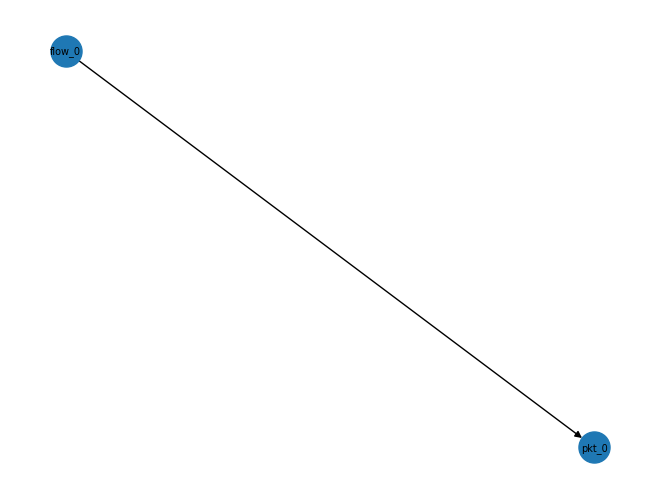

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

sample = train_dataset[0]

G = nx.DiGraph()
G.add_node('flow_0')
for i in range(sample['packet'].x.shape[0]):
    G.add_node(f'pkt_{i}')

ei = sample[('flow','contain','packet')].edge_index
for s, d in zip(ei[0].tolist(), ei[1].tolist()):
    G.add_edge(f'flow_{s}', f'pkt_{d}')

ei = sample[('packet','link','packet')].edge_index
for s, d in zip(ei[0].tolist(), ei[1].tolist()):
    G.add_edge(f'pkt_{s}', f'pkt_{d}')

nx.draw(G, with_labels=True, node_size=500, font_size=7)
plt.show()

In [ ]:
# Training lần 1
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS['lr'])

best_f1 = 0.0
history = []

for epoch in range(1, ARGS['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader, train=True)
    history.append({'epoch': epoch, 'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1})
    print(f'Epoch {epoch:3d}/{ARGS["epochs"]} | Loss: {tr_loss:.4f} | '
          f'Acc: {tr_acc:.4f} | Macro-F1: {tr_f1:.4f}')
    if tr_f1 > best_f1:
        best_f1 = tr_f1
        torch.save(model.state_dict(), '/content/xgnid_best_v1.pth')

print(f'\nBest Train Macro-F1: {best_f1:.4f}')

Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch   1/30 | Loss: 0.2170 | Acc: 0.9187 | Macro-F1: 0.9192


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch   2/30 | Loss: 0.1770 | Acc: 0.9330 | Macro-F1: 0.9333


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

...

Epoch  28/30 | Loss: 0.1068 | Acc: 0.9596 | Macro-F1: 0.9597


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch  29/30 | Loss: 0.1079 | Acc: 0.9596 | Macro-F1: 0.9597


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch  30/30 | Loss: 0.1044 | Acc: 0.9613 | Macro-F1: 0.9614

Best Train Macro-F1: 0.9614


In [ ]:
# Test evaluation Lần train 1
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/content/xgnid_best_v1.pth', map_location=device))
_, test_acc, test_f1, preds, labels = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS')
print('=' * 60)
print(f'Accuracy  : {test_acc:.4f}')
print(f'Macro-F1  : {test_f1:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

Test:   0%|          | 0/400 [00:00<?, ?it/s]

TEST RESULTS
Accuracy  : 0.9589
Macro-F1  : 0.9434  (paper target: 0.97)

              precision    recall  f1-score   support

      Benign     0.9522    0.9507    0.9515      4000
    WebBased     0.6350    0.9431    0.7590      1090
    Spoofing     0.9542    0.9383    0.9462      4000
       Recon     0.9796    0.8765    0.9252      4000
       Mirai     1.0000    0.9990    0.9995      4000
         Dos     0.9997    0.9940    0.9969      4000
        DDos     1.0000    0.9980    0.9990      4000
  BruteForce     0.9700    0.9700    0.9700       467

    accuracy                         0.9589     25557
   macro avg     0.9363    0.9587    0.9434     25557
weighted avg     0.9660    0.9589    0.9607     25557



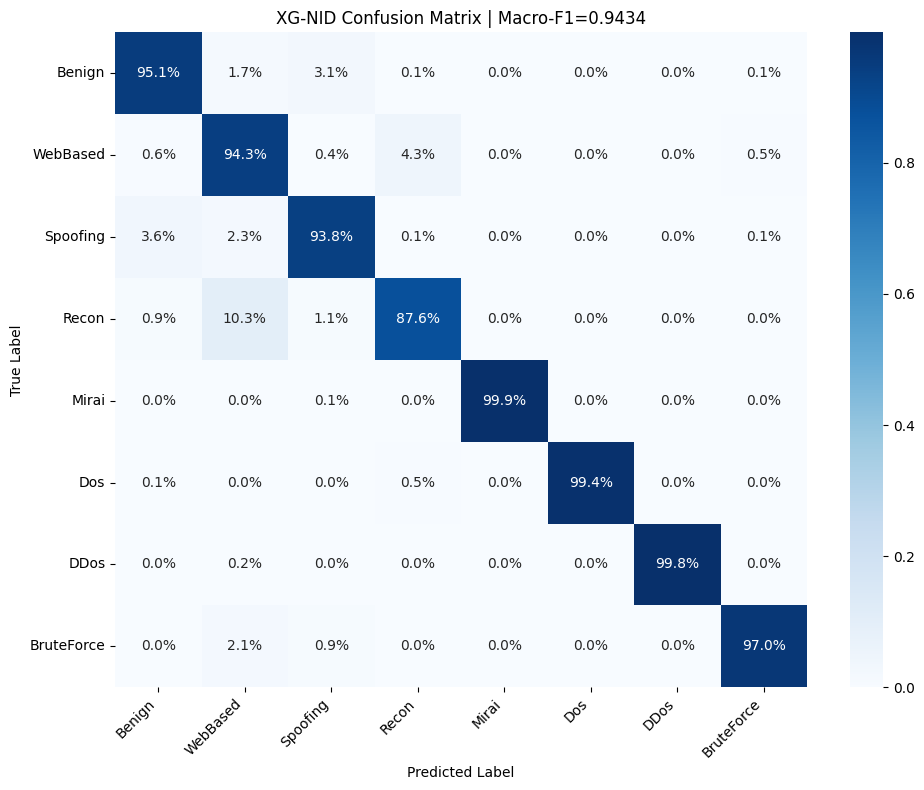

Saved: /content/confusion_matrix.png


In [ ]:
# Confusion matrix Lần train 1
cm = confusion_matrix(labels, preds, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix | Macro-F1={test_f1:.4f}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix.png')

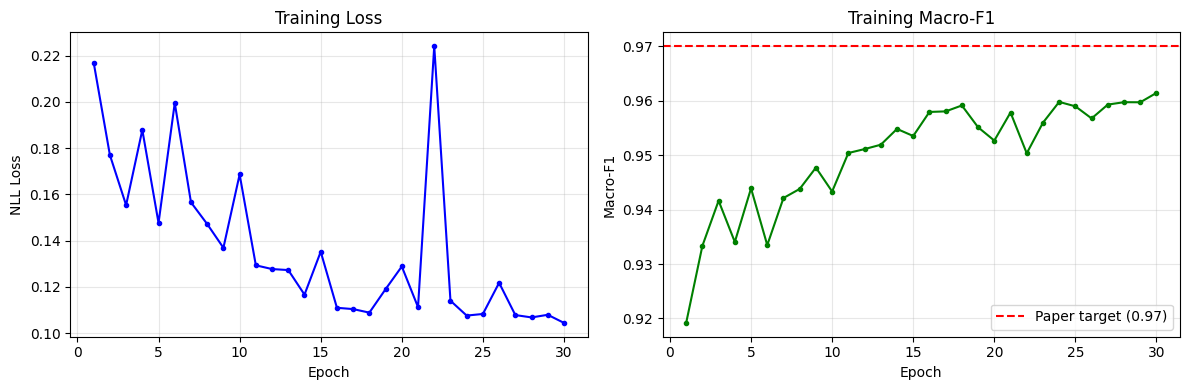

In [ ]:
# Training curve Lần train 1
epochs_range = [h['epoch'] for h in history]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, [h['loss'] for h in history], 'b-o', markersize=3)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [h['f1'] for h in history], 'g-o', markersize=3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Training Macro-F1')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curve.png', dpi=150)
plt.show()

In [ ]:
# Lưu KQ về drive
import shutil, subprocess
SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/content/xgnid_best_v1.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v1.pth'))
shutil.copy('/content/confusion_matrix.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix.png'))
shutil.copy('/content/training_curve.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve.png'))

print(f'Model + figures saved to: {SAVE_TO_DRIVE}')
print(f'Final Test Macro-F1: {test_f1:.4f}  (paper target: 0.97)')


# Lưu zip graph objects
SAVE_ZIP = True
if SAVE_ZIP:
    print('\nĐang zip graph objects...')
    subprocess.run(['zip', '-r', GRAPH_ZIP_PATH, GRAPH_STORE + '/processed'], check=True)
    size = os.path.getsize(GRAPH_ZIP_PATH) / 1e9
    print(f'Zip saved: {GRAPH_ZIP_PATH} ({size:.2f} GB)')
else:
    print('\nZip skipped. Đổi SAVE_ZIP=True để lưu graph objects lên Drive.')

Model + figures saved to: /content/drive/MyDrive/network-attack/saved_models
Final Test Macro-F1: 0.9434  (paper target: 0.97)

Đang zip graph objects...
Zip saved: /content/drive/MyDrive/network-attack/graph_objects.zip (1.10 GB)


# TRAIN LẦN 2
Chạy các cell từ 1-9 ở trên cùng trước nếu đã đổi runtime mới

In [ ]:
ARGS_V2 = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.001,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}

print(f"[Train lần 2]")
print(f"Device : {ARGS_V2['device']}")
print(f"Epochs : {ARGS_V2['epochs']}, LR: {ARGS_V2['lr']}, Batch: {ARGS_V2['batch_size']}")
print(f"Model  : tiếp tục fine-tune từ checkpoint lần 1 (xgnid_best_v1.pth)")

[Train lần 2]
Device : cpu
Epochs : 30, LR: 0.001, Batch: 64
Model  : tiếp tục fine-tune từ checkpoint lần 1 (xgnid_best.pth)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm

# Load checkpoint lần 1 để fine-tune
model.load_state_dict(torch.load('/content/drive/MyDrive/network-attack/saved_models/xgnid_best_v1.pth', map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V2['lr'])

best_f1_v2 = 0.0
history_v2 = []

for epoch in range(1, ARGS_V2['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader, train=True)
    history_v2.append({'epoch': epoch, 'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1})
    print(f'Epoch {epoch:3d}/{ARGS_V2["epochs"]} | Loss: {tr_loss:.4f} | '
          f'Acc: {tr_acc:.4f} | Macro-F1: {tr_f1:.4f}')
    if tr_f1 > best_f1_v2:
        best_f1_v2 = tr_f1
        torch.save(model.state_dict(), '/content/xgnid_best_v2.pth')

print(f'\nBest Train Macro-F1 (v2): {best_f1_v2:.4f}')

Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch   1/30 | Loss: 0.0843 | Acc: 0.9711 | Macro-F1: 0.9712


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/30 | Loss: 0.0772 | Acc: 0.9723 | Macro-F1: 0.9724


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  29/30 | Loss: 0.0637 | Acc: 0.9774 | Macro-F1: 0.9774


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  30/30 | Loss: 0.0638 | Acc: 0.9774 | Macro-F1: 0.9774

Best Train Macro-F1 (v2): 0.9774


In [ ]:
# Test evaluation Lần train 2
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/content/xgnid_best_v2.pth', map_location=device))
_, test_acc_v2, test_f1_v2, preds_v2, labels_v2 = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS (Train lần 2)')
print('=' * 60)
print(f'Accuracy  : {test_acc_v2:.4f}')
print(f'Macro-F1  : {test_f1_v2:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels_v2, preds_v2, target_names=CLASS_NAMES, digits=4))

Test:   0%|          | 0/400 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TEST RESULTS (Train lần 2)
Accuracy  : 0.9727
Macro-F1  : 0.9631  (paper target: 0.97)

              precision    recall  f1-score   support

      Benign     0.9519    0.9690    0.9604      4000
    WebBased     0.7753    0.9752    0.8639      1090
    Spoofing     0.9644    0.9473    0.9557      4000
       Recon     0.9909    0.9255    0.9571      4000
       Mirai     1.0000    0.9992    0.9996      4000
         Dos     0.9997    0.9958    0.9977      4000
        DDos     1.0000    0.9980    0.9990      4000
  BruteForce     0.9622    0.9807    0.9714       467

    accuracy                         0.9727     25557
   macro avg     0.9556    0.9738    0.9631     25557
weighted avg     0.9752    0.9727    0.9733     25557



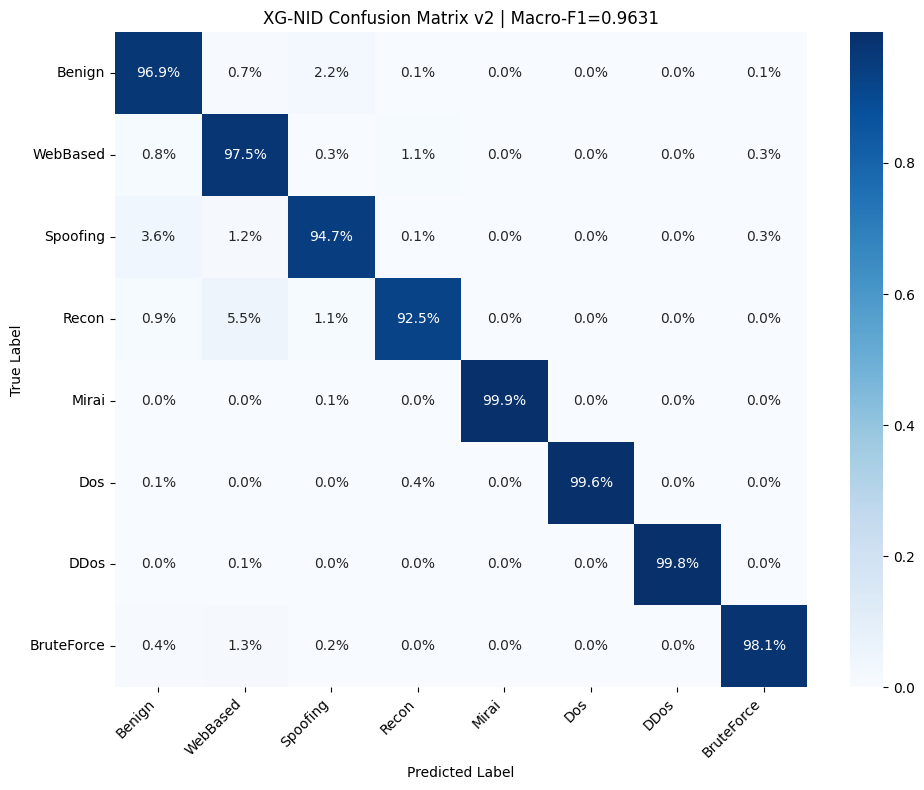

Saved: /content/confusion_matrix_v2.png


In [ ]:
cm_v2 = confusion_matrix(labels_v2, preds_v2, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v2, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix v2 | Macro-F1={test_f1_v2:.4f}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_v2.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix_v2.png')

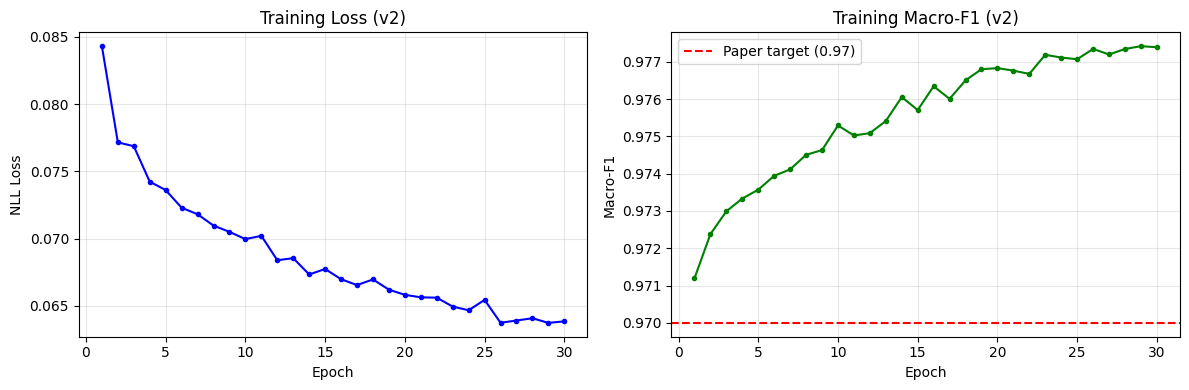

In [ ]:
epochs_range_v2 = [h['epoch'] for h in history_v2]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range_v2, [h['loss'] for h in history_v2], 'b-o', markersize=3)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Training Loss (v2)')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_v2, [h['f1'] for h in history_v2], 'g-o', markersize=3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Training Macro-F1 (v2)')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curve_v2.png', dpi=150)
plt.show()

In [ ]:
import shutil

SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/content/xgnid_best_v2.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v2.pth'))
shutil.copy('/content/confusion_matrix_v2.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix_v2.png'))
shutil.copy('/content/training_curve_v2.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve_v2.png'))

print(f'Saved to: {SAVE_TO_DRIVE}')
print(f'  xgnid_best_v2.pth')
print(f'  confusion_matrix_v2.png')
print(f'  training_curve_v2.png')
print(f'Final Test Macro-F1 (v2): {test_f1_v2:.4f}  (paper target: 0.97)')

Saved to: /content/drive/MyDrive/network-attack/saved_models
  xgnid_best_v2.pth
  confusion_matrix_v2.png
  training_curve_v2.png
Final Test Macro-F1 (v2): 0.9631  (paper target: 0.97)


# TRAIN LẦN 3
Fine-tune từ checkpoint lần 1 với validation set tách riêng (10% của train_dataset)

Chạy các cell từ 1-9 trước nếu đã đổi runtime mới

In [ ]:
# Val split + DataLoaders
import pandas as pd
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader

df_labels = pd.read_csv(TRAIN_CSV, usecols=['Label'])
all_labels = df_labels['Label'].tolist()

n_total = len(train_dataset)
n_val   = int(0.1 * n_total)
n_train = n_total - n_val
train_sub_v3, val_sub_v3 = random_split(
    train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

_pin = torch.cuda.is_available()
train_loader_v3 = DataLoader(train_sub_v3, batch_size=ARGS['batch_size'], shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader_v3   = DataLoader(val_sub_v3,   batch_size=ARGS['batch_size'], shuffle=False, num_workers=2, pin_memory=_pin)

print(f'Train v3 : {len(train_sub_v3):,} graphs  ({len(train_loader_v3)} batches)')
print(f'Val   v3 : {len(val_sub_v3):,} graphs  ({len(val_loader_v3)} batches)')
print(f'Test     : {len(test_dataset):,} graphs  ({len(test_loader)} batches)')

Train v3 : 144,000 graphs  (2250 batches)
Val   v3 : 16,000 graphs  (250 batches)
Test     : 25,557 graphs  (400 batches)


In [ ]:
# Kiểm tra phân phối class trong train/val split
train_labels = [all_labels[i] for i in train_sub_v3.indices]
val_labels   = [all_labels[i] for i in val_sub_v3.indices]

print(f"{'Class':<12} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8}")
print('-' * 48)
for name, idx in sorted(LABEL_DICT.items(), key=lambda x: x[1]):
    tr_count  = train_labels.count(idx)   # CSV dùng integer label
    val_count = val_labels.count(idx)
    tr_pct    = tr_count  / len(train_labels) * 100
    val_pct   = val_count / len(val_labels)   * 100
    print(f"{name:<12} {tr_count:>8,} {tr_pct:>7.2f}% {val_count:>8,} {val_pct:>7.2f}%")
print('-' * 48)
print(f"{'Total':<12} {len(train_labels):>8,} {'100%':>8} {len(val_labels):>8,} {'100%':>8}")

Class           Train   Train%      Val     Val%
------------------------------------------------
Benign         17,928   12.45%    2,072   12.95%
WebBased       17,970   12.48%    2,030   12.69%
Spoofing       18,011   12.51%    1,989   12.43%
Recon          18,040   12.53%    1,960   12.25%
Mirai          18,095   12.57%    1,905   11.91%
Dos            17,955   12.47%    2,045   12.78%
DDos           17,991   12.49%    2,009   12.56%
BruteForce     18,010   12.51%    1,990   12.44%
------------------------------------------------
Total         144,000     100%   16,000     100%


In [ ]:
# Config
ARGS_V3 = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      50,
    'lr':          0.001,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}
PATIENCE_V3 = 5

print(f"[Train lần 3]")
print(f"Device  : {ARGS_V3['device']}")
print(f"Epochs  : {ARGS_V3['epochs']}, LR: {ARGS_V3['lr']}, Patience: {PATIENCE_V3}")
print(f"Checkpoint: fine-tune từ xgnid_best_v1.pth")

[Train lần 3]
Device  : cuda
Epochs  : 50, LR: 0.001, Patience: 5
Checkpoint: fine-tune từ xgnid_best.pth


In [ ]:
# Train lần 3
model.load_state_dict(torch.load('/content/drive/MyDrive/network-attack/saved_models/xgnid_best_v1.pth', map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V3['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, threshold=0.01, min_lr=1e-5
)

best_f1_v3 = 0.0
patience_counter_v3 = 0
history_v3 = []

for epoch in range(1, ARGS_V3['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v3, train=True)
    va_loss, va_acc, va_f1, _, _ = run_epoch(val_loader_v3,   train=False)
    scheduler.step(va_f1)
    current_lr = optimizer.param_groups[0]['lr']

    history_v3.append({'epoch': epoch,
                        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
                        'va_loss': va_loss, 'va_acc': va_acc, 'va_f1': va_f1,
                        'lr': current_lr})
    print(f'Epoch {epoch:3d}/{ARGS_V3["epochs"]} | '
          f'Train Loss: {tr_loss:.4f}  F1: {tr_f1:.4f} | '
          f'Val   Loss: {va_loss:.4f}  F1: {va_f1:.4f} | '
          f'LR: {current_lr:.6f}'
          + (' ← best' if va_f1 > best_f1_v3 else ''))

    if va_f1 > best_f1_v3:
        best_f1_v3 = va_f1
        patience_counter_v3 = 0
        torch.save(model.state_dict(), '/content/xgnid_best_v3.pth')
    else:
        patience_counter_v3 += 1
        if patience_counter_v3 >= PATIENCE_V3:
            print(f'\nEarly stopping: val F1 không cải thiện sau {PATIENCE_V3} epoch liên tiếp.')
            break

print(f'\nBest Val Macro-F1 (v3): {best_f1_v3:.4f}  (dừng ở epoch {epoch})')

Train:   0%|          | 0/2250 [00:00<?, ?it/s]

Test:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch   1/50 | Train Loss: 0.0829  F1: 0.9703 | Val   Loss: 0.0711  F1: 0.9735 | LR: 0.001000 ← best


Train:   0%|          | 0/2250 [00:00<?, ?it/s]

Test:   0%|          | 0/250 [00:00<?, ?it/s]

...

Test:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch  17/50 | Train Loss: 0.0673  F1: 0.9763 | Val   Loss: 0.0633  F1: 0.9757 | LR: 0.000063


Train:   0%|          | 0/2250 [00:00<?, ?it/s]

Test:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch  18/50 | Train Loss: 0.0670  F1: 0.9762 | Val   Loss: 0.0636  F1: 0.9768 | LR: 0.000063

Early stopping: val F1 không cải thiện sau 5 epoch liên tiếp.

Best Val Macro-F1 (v3): 0.9784  (dừng ở epoch 18)


In [ ]:
# Test evaluation Lần train 3
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/content/xgnid_best_v3.pth', map_location=device))
_, test_acc_v3, test_f1_v3, preds_v3, labels_v3 = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS (Train lần 3)')
print('=' * 60)
print(f'Accuracy  : {test_acc_v3:.4f}')
print(f'Macro-F1  : {test_f1_v3:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels_v3, preds_v3, target_names=CLASS_NAMES, digits=4))

Test:   0%|          | 0/400 [00:00<?, ?it/s]

TEST RESULTS (Train lần 3)
Accuracy  : 0.9721
Macro-F1  : 0.9610  (paper target: 0.97)

              precision    recall  f1-score   support

      Benign     0.9547    0.9643    0.9595      4000
    WebBased     0.7609    0.9807    0.8569      1090
    Spoofing     0.9707    0.9433    0.9568      4000
       Recon     0.9854    0.9300    0.9569      4000
       Mirai     1.0000    0.9992    0.9996      4000
         Dos     1.0000    0.9955    0.9977      4000
        DDos     1.0000    0.9980    0.9990      4000
  BruteForce     0.9499    0.9743    0.9619       467

    accuracy                         0.9721     25557
   macro avg     0.9527    0.9732    0.9610     25557
weighted avg     0.9749    0.9721    0.9728     25557



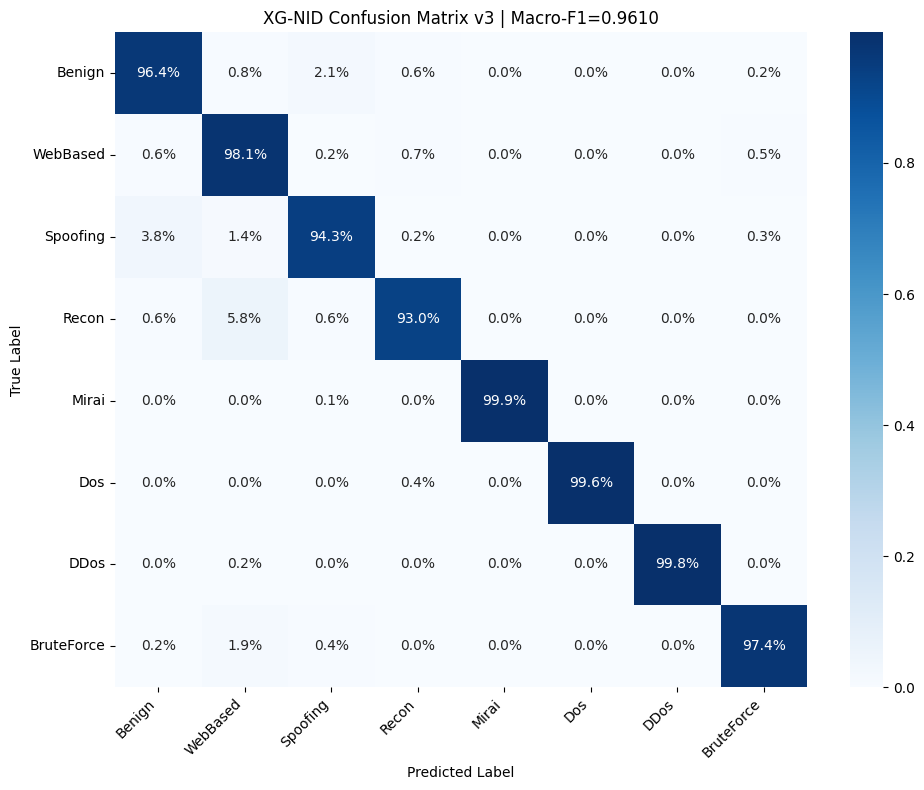

Saved: /content/confusion_matrix_v3.png


In [ ]:
cm_v3 = confusion_matrix(labels_v3, preds_v3, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v3, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix v3 | Macro-F1={test_f1_v3:.4f}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_v3.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix_v3.png')

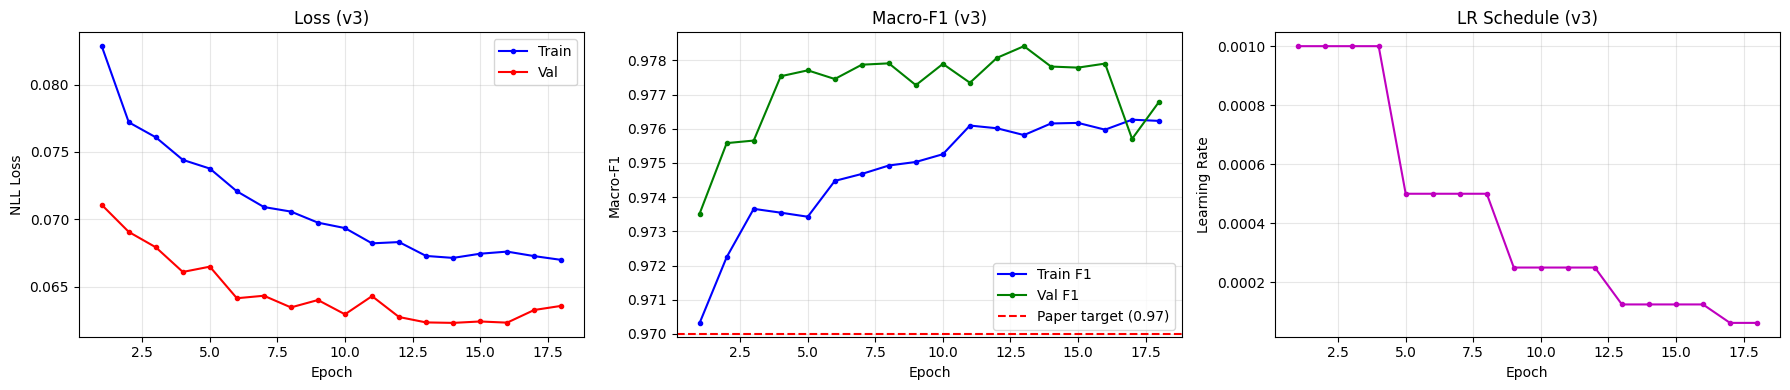

In [ ]:
# Training curve
epochs_range_v3 = [h['epoch'] for h in history_v3]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(epochs_range_v3, [h['loss']    for h in history_v3], 'b-o', markersize=3, label='Train')
ax1.plot(epochs_range_v3, [h['va_loss'] for h in history_v3], 'r-o', markersize=3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Loss (v3)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_v3, [h['f1']    for h in history_v3], 'b-o', markersize=3, label='Train F1')
ax2.plot(epochs_range_v3, [h['va_f1'] for h in history_v3], 'g-o', markersize=3, label='Val F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Macro-F1 (v3)')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3.plot(epochs_range_v3, [h['lr'] for h in history_v3], 'm-o', markersize=3)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Learning Rate'); ax3.set_title('LR Schedule (v3)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curve_v3.png', dpi=150)
plt.show()

In [ ]:
# Lưu KQ về drive
import shutil

SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/content/xgnid_best_v3.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v3.pth'))
shutil.copy('/content/confusion_matrix_v3.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix_v3.png'))
shutil.copy('/content/training_curve_v3.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve_v3.png'))

print(f'Saved to: {SAVE_TO_DRIVE}')
print(f'  xgnid_best_v3.pth')
print(f'  confusion_matrix_v3.png')
print(f'  training_curve_v3.png')
print(f'Final Test Macro-F1 (v3): {test_f1_v3:.4f}  (paper target: 0.97)')

Saved to: /content/drive/MyDrive/network-attack/saved_models
  xgnid_best_v3.pth
  confusion_matrix_v3.png
  training_curve_v3.png
Final Test Macro-F1 (v3): 0.9610  (paper target: 0.97)


# TRAIN LẦN 4
(bỏ scheduler, cố định lr=0.001, finetune trên checkpoint từ lần train 2)

In [ ]:
# Val split + DataLoaders (stratified)
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader

all_labels = [train_dataset[i].y.item() for i in range(len(train_dataset))]
train_idx, val_idx = train_test_split(
    range(len(train_dataset)),
    test_size=0.1,
    stratify=all_labels,
    random_state=42
)
train_sub_v4 = Subset(train_dataset, list(train_idx))
val_sub_v4   = Subset(train_dataset, list(val_idx))

_pin = torch.cuda.is_available()
train_loader_v4 = DataLoader(train_sub_v4, batch_size=ARGS['batch_size'], shuffle=True,  num_workers=2, pin_memory=_pin)
val_loader_v4   = DataLoader(val_sub_v4,   batch_size=ARGS['batch_size'], shuffle=False, num_workers=2, pin_memory=_pin)

print(f'Train v4 : {len(train_sub_v4):,} graphs  ({len(train_loader_v4)} batches)')
print(f'Val   v4 : {len(val_sub_v4):,} graphs  ({len(val_loader_v4)} batches)')
print(f'Test     : {len(test_dataset):,} graphs  ({len(test_loader)} batches)')

Train v4 : 144,000 graphs  (2250 batches)
Val   v4 : 16,000 graphs  (250 batches)
Test     : 25,557 graphs  (400 batches)


In [ ]:
# Kiểm tra phân phối class trong train/val split
import numpy as np

train_labels = [all_labels[i] for i in train_idx]
val_labels   = [all_labels[i] for i in val_idx]

print(f"{'Class':<12} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8}")
print('-' * 48)
for name, idx in sorted(LABEL_DICT.items(), key=lambda x: x[1]):
    tr_count  = train_labels.count(idx)
    val_count = val_labels.count(idx)
    tr_pct    = tr_count  / len(train_labels) * 100
    val_pct   = val_count / len(val_labels)   * 100
    print(f"{name:<12} {tr_count:>8,} {tr_pct:>7.2f}% {val_count:>8,} {val_pct:>7.2f}%")
print('-' * 48)
print(f"{'Total':<12} {len(train_labels):>8,} {'100%':>8} {len(val_labels):>8,} {'100%':>8}")

Class           Train   Train%      Val     Val%
------------------------------------------------
Benign         18,000   12.50%    2,000   12.50%
WebBased       18,000   12.50%    2,000   12.50%
Spoofing       18,000   12.50%    2,000   12.50%
Recon          18,000   12.50%    2,000   12.50%
Mirai          18,000   12.50%    2,000   12.50%
Dos            18,000   12.50%    2,000   12.50%
DDos           18,000   12.50%    2,000   12.50%
BruteForce     18,000   12.50%    2,000   12.50%
------------------------------------------------
Total         144,000     100%   16,000     100%


In [ ]:
# Config
ARGS_V4 = {
    'device':      torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'hidden_size': 64,
    'epochs':      50,
    'lr':          0.001,
    'attn_size':   32,
    'eps':         1.0,
    'batch_size':  64,
}
PATIENCE_V4 = 8

print(f"[Train lần 4]")
print(f"Device  : {ARGS_V4['device']}")
print(f"Epochs  : {ARGS_V4['epochs']}, LR: {ARGS_V4['lr']}, Patience: {PATIENCE_V4}")
print(f"Checkpoint: fine-tune từ xgnid_best_v1.pth")

[Train lần 4]
Device  : cuda
Epochs  : 50, LR: 0.001, Patience: 8
Checkpoint: fine-tune từ xgnid_best.pth


In [ ]:
# Train lần 4
model.load_state_dict(torch.load('/content/drive/MyDrive/network-attack/saved_models/xgnid_best_v2.pth', map_location=device))
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V4['lr'])

best_f1_v4 = 0.0
patience_counter_v4 = 0
history_v4 = []

for epoch in range(1, ARGS_V4['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v4, train=True)
    va_loss, va_acc, va_f1, _, _ = run_epoch(val_loader_v4,   train=False)
    current_lr = optimizer.param_groups[0]['lr']

    history_v4.append({'epoch': epoch,
                        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
                        'va_loss': va_loss, 'va_acc': va_acc, 'va_f1': va_f1,
                        'lr': current_lr})
    print(f'Epoch {epoch:3d}/{ARGS_V4["epochs"]} | '
          f'Train Loss: {tr_loss:.4f}  F1: {tr_f1:.4f} | '
          f'Val   Loss: {va_loss:.4f}  F1: {va_f1:.4f}'
          + (' ← best' if va_f1 > best_f1_v4 else ''))

    if va_f1 > best_f1_v4:
        best_f1_v4 = va_f1
        patience_counter_v4 = 0
        torch.save(model.state_dict(), '/content/xgnid_best_v4.pth')
    else:
        patience_counter_v4 += 1
        if patience_counter_v4 >= PATIENCE_V4:
            print(f'\nEarly stopping: val F1 không cải thiện sau {PATIENCE_V4} epoch liên tiếp.')
            break

print(f'\nBest Val Macro-F1 (v4): {best_f1_v4:.4f}  (dừng ở epoch {epoch})')

Train:   0%|          | 0/2250 [00:00<?, ?it/s]

Test:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch   1/50 | Train Loss: 0.0641  F1: 0.9775 | Val   Loss: 0.0538  F1: 0.9801 ← best


Train:   0%|          | 0/2250 [00:00<?, ?it/s]

Test:   0%|          | 0/250 [00:00<?, ?it/s]

...

Test:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch  36/50 | Train Loss: 0.0553  F1: 0.9804 | Val   Loss: 0.0507  F1: 0.9809


Train:   0%|          | 0/2250 [00:00<?, ?it/s]

Test:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch  37/50 | Train Loss: 0.0561  F1: 0.9799 | Val   Loss: 0.0504  F1: 0.9827

Early stopping: val F1 không cải thiện sau 8 epoch liên tiếp.

Best Val Macro-F1 (v4): 0.9838  (dừng ở epoch 37)


In [ ]:
# Test evaluation Lần train 4
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load('/content/xgnid_best_v4.pth', map_location=device))
_, test_acc_v4, test_f1_v4, preds_v4, labels_v4 = run_epoch(test_loader, train=False)

print('=' * 60)
print('TEST RESULTS (Train lần 4)')
print('=' * 60)
print(f'Accuracy  : {test_acc_v4:.4f}')
print(f'Macro-F1  : {test_f1_v4:.4f}  (paper target: 0.97)')
print()
print(classification_report(labels_v4, preds_v4, target_names=CLASS_NAMES, digits=4))

Test:   0%|          | 0/400 [00:00<?, ?it/s]

TEST RESULTS (Train lần 4)
Accuracy  : 0.9734
Macro-F1  : 0.9635  (paper target: 0.97)

              precision    recall  f1-score   support

      Benign     0.9513    0.9712    0.9612      4000
    WebBased     0.7680    0.9780    0.8604      1090
    Spoofing     0.9729    0.9420    0.9572      4000
       Recon     0.9896    0.9317    0.9598      4000
       Mirai     1.0000    0.9992    0.9996      4000
         Dos     1.0000    0.9958    0.9979      4000
        DDos     1.0000    0.9988    0.9994      4000
  BruteForce     0.9682    0.9764    0.9723       467

    accuracy                         0.9734     25557
   macro avg     0.9562    0.9741    0.9635     25557
weighted avg     0.9760    0.9734    0.9740     25557



In [ ]:
cm_v4 = confusion_matrix(labels_v4, preds_v4, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v4, annot=True, cmap='Blues', fmt='.1%', ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.xaxis.set_ticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.yaxis.set_ticklabels(CLASS_NAMES, rotation=0)
ax.set_title(f'XG-NID Confusion Matrix v4 | Macro-F1={test_f1_v4:.4f}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_v4.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix_v4.png')

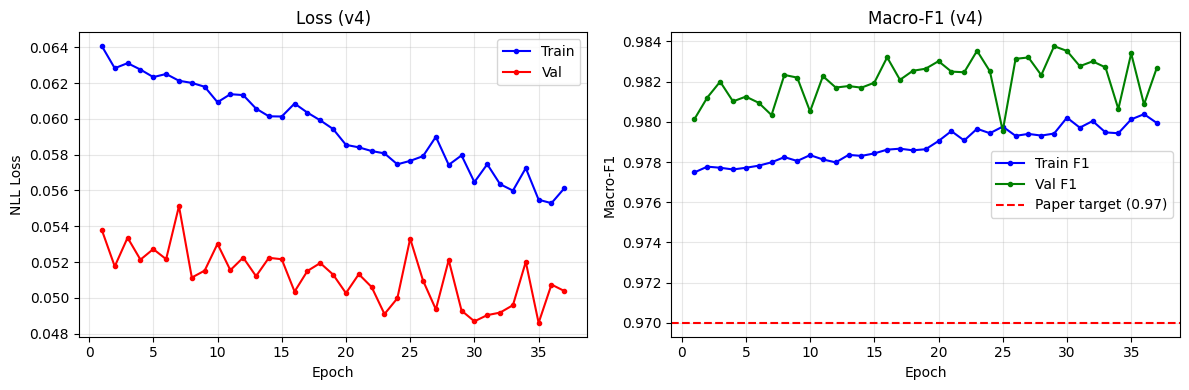

In [ ]:
# Training curve
epochs_range_v4 = [h['epoch'] for h in history_v4]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range_v4, [h['loss']    for h in history_v4], 'b-o', markersize=3, label='Train')
ax1.plot(epochs_range_v4, [h['va_loss'] for h in history_v4], 'r-o', markersize=3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NLL Loss'); ax1.set_title('Loss (v4)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range_v4, [h['f1']    for h in history_v4], 'b-o', markersize=3, label='Train F1')
ax2.plot(epochs_range_v4, [h['va_f1'] for h in history_v4], 'g-o', markersize=3, label='Val F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro-F1'); ax2.set_title('Macro-F1 (v4)')
ax2.axhline(y=0.97, color='r', linestyle='--', label='Paper target (0.97)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curve_v4.png', dpi=150)
plt.show()

In [ ]:
# Lưu KQ về drive
import shutil

SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/content/xgnid_best_v4.pth',       os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v4.pth'))
shutil.copy('/content/confusion_matrix_v4.png', os.path.join(SAVE_TO_DRIVE, 'confusion_matrix_v4.png'))
shutil.copy('/content/training_curve_v4.png',   os.path.join(SAVE_TO_DRIVE, 'training_curve_v4.png'))

print(f'Saved to: {SAVE_TO_DRIVE}')
print(f'  xgnid_best_v4.pth')
print(f'  confusion_matrix_v4.png')
print(f'  training_curve_v4.png')
print(f'Final Test Macro-F1 (v4): {test_f1_v4:.4f}  (paper target: 0.97)')

Saved to: /content/drive/MyDrive/network-attack/saved_models
  xgnid_best_v4.pth
  confusion_matrix_v4.png
  training_curve_v4.png
Final Test Macro-F1 (v4): 0.9635  (paper target: 0.97)


# TRAIN LẦN 5 - DATA RAW

In [ ]:
# 1. XỬ LÝ DỮ LIỆU GỐC VÀ TẠO DATALOADER
import os, glob
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import HeteroData, Dataset
from torch_geometric.loader import DataLoader

# Định nghĩa nhãn
LABEL_MAPPING = {
    'BENIGN': 'Benign',
    'SQLINJECTION': 'WebBased', 'COMMANDINJECTION': 'WebBased', 'BACKDOOR_MALWARE': 'WebBased', 'UPLOADING_ATTACK': 'WebBased', 'XSS': 'WebBased', 'BROWSERHIJACKING': 'WebBased',
    'MITM-ARPSPOOFING': 'Spoofing', 'DNS_SPOOFING': 'Spoofing',
    'RECON-PINGSWEEP': 'Recon', 'RECON-OSSCAN': 'Recon', 'VULNERABILITYSCAN': 'Recon', 'RECON-PORTSCAN': 'Recon', 'RECON-HOSTDISCOVERY': 'Recon',
    'MIRAI-GREIP_FLOOD': 'Mirai', 'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai',
    'DOS-TCP_FLOOD': 'Dos', 'DOS-HTTP_FLOOD': 'Dos', 'DOS-SYN_FLOOD': 'Dos', 'DOS-UDP_FLOOD': 'Dos',
    'DDOS-ACK_FRAGMENTATION': 'DDos', 'DDOS-UDP_FLOOD': 'DDos', 'DDOS-SLOWLORIS': 'DDos', 'DDOS-ICMP_FLOOD': 'DDos', 'DDOS-RSTFINFLOOD': 'DDos', 'DDOS-PSHACK_FLOOD': 'DDos', 'DDOS-HTTP_FLOOD': 'DDos', 'DDOS-UDP_FRAGMENTATION': 'DDos', 'DDOS-ICMP_FRAGMENTATION': 'DDos', 'DDOS-TCP_FLOOD': 'DDos', 'DDOS-SYN_FLOOD': 'DDos', 'DDOS-SYNONYMOUSIP_FLOOD': 'DDos',
    'DICTIONARYBRUTEFORCE': 'BruteForce'
}
CLASS_NAMES = ['Benign', 'WebBased', 'Spoofing', 'Recon', 'Mirai', 'Dos', 'DDos', 'BruteForce']
CLASS_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}

MERGED_CSV_DIR = "/content/drive/MyDrive/network-attack/dataset/MERGED_CSV"

def sample_balanced_dataset(merged_csv_dir, samples_per_class=10000):
    files = glob.glob(os.path.join(merged_csv_dir, "*.csv"))
    collected_data = {i: [] for i in range(8)}

    for f in files:
        counts = {c: sum(len(x) for x in lst) for c, lst in collected_data.items()}
        active_classes = [c for c, count in counts.items() if count < samples_per_class]
        if not active_classes: break

        df = pd.read_csv(f)
        df['Mapped_Label'] = df['Label'].astype(str).str.upper().map(LABEL_MAPPING).map(CLASS_MAP)

        for c in active_classes:
            c_rows = df[df['Mapped_Label'] == c]
            if not c_rows.empty:
                needed = samples_per_class - counts[c]
                collected_data[c].append(c_rows.head(needed).drop(columns=['Label', 'Mapped_Label']))

    for c in collected_data:
        df_c = pd.concat(collected_data[c], ignore_index=True) if collected_data[c] else pd.DataFrame()
        if 0 < len(df_c) < samples_per_class:
            multiplier = (samples_per_class // len(df_c)) + 1
            df_c = pd.concat([df_c] * multiplier, ignore_index=True).head(samples_per_class)
        collected_data[c] = df_c
    return collected_data

print("Đang lấy mẫu dữ liệu gốc...")
sampled_data = sample_balanced_dataset(MERGED_CSV_DIR, samples_per_class=10000)

train_dfs, test_dfs, train_labels, test_labels = [], [], [], []
n_train = 8000
n_test = 2000

for c in range(8):
    df_c = sampled_data[c].sample(frac=1.0, random_state=42).reset_index(drop=True)
    train_dfs.append(df_c.head(n_train))
    train_labels.extend([c] * n_train)
    test_dfs.append(df_c.tail(n_test))
    test_labels.extend([c] * n_test)

train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

# Xử lý NaN và Infinity trước khi chuẩn hóa
train_df = train_df.replace([np.inf, -np.inf], np.nan).fillna(0)
test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Chuẩn hóa
scaler = StandardScaler()
train_feats = pd.DataFrame(scaler.fit_transform(train_df.values))
test_feats = pd.DataFrame(scaler.transform(test_df.values))

class OriginalFlowDataset(Dataset):
    def __init__(self, flows_df, labels):
        super().__init__()
        self.labels = labels
        self.features = torch.tensor(flows_df.values, dtype=torch.float32)
    def len(self): return len(self.labels)
    def get(self, idx):
        data = HeteroData()
        data['flow'].x = self.features[idx].unsqueeze(0)
        data['packet'].x = torch.zeros((1, 1500), dtype=torch.float32)
        data['flow', 'contain', 'packet'].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        data['flow', 'contain', 'packet'].edge_attr  = torch.zeros((1, 4), dtype=torch.float32)
        data['packet', 'link', 'packet'].edge_index = torch.zeros((2, 0), dtype=torch.long)
        data['packet', 'link', 'packet'].edge_attr  = torch.zeros((0,), dtype=torch.float32)
        data['packet', 'rev_contain', 'flow'].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        data['packet', 'rev_contain', 'flow'].edge_attr  = torch.zeros((1, 4), dtype=torch.float32)
        data.y = torch.tensor([self.labels[idx]], dtype=torch.long)
        return data

train_dataset_v5 = OriginalFlowDataset(train_feats, train_labels)
test_dataset_v5 = OriginalFlowDataset(test_feats, test_labels)

train_loader_v5 = DataLoader(train_dataset_v5, batch_size=128, shuffle=True)
test_loader_v5 = DataLoader(test_dataset_v5, batch_size=128, shuffle=False)
print(f"DataLoaders sẵn sàng. Train: {len(train_dataset_v5)} mẫu, Test: {len(test_dataset_v5)} mẫu.")

Đang lấy mẫu dữ liệu gốc...
DataLoaders sẵn sàng. Train: 64000 mẫu, Test: 16000 mẫu.


In [ ]:
# 2. KHỞI TẠO MÔ HÌNH VÀ THAM SỐ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ARGS_V5 = {
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.001,
    'eps':         1.0
}

# Khởi tạo mô hình mới hoàn toàn (Train từ đầu)
model = HeteroGNN_Edge(train_dataset_v5[0].to(device), ARGS_V5, aggr='mean').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V5['lr'])

In [ ]:
# 3. TRAINING LOOP LẦN 5 (Tái sử dụng hàm run_epoch)
best_f1_v5 = 0.0
history_v5 = []

print("Bắt đầu TRAIN LẦN 5...")
for epoch in range(1, ARGS_V5['epochs'] + 1):
    # Train
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v5, train=True)

    # Validation/Test
    val_loss, val_acc, val_f1, preds_v5, labels_v5 = run_epoch(test_loader_v5, train=False)

    history_v5.append({
        'epoch': epoch,
        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1
    })

    print(f'Epoch {epoch:3d}/{ARGS_V5["epochs"]} | Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f} || Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_f1_v5:
        best_f1_v5 = val_f1
        torch.save(model.state_dict(), '/content/xgnid_best_v5.pth')

print(f'\nBest Val Macro-F1: {best_f1_v5:.4f}')

# Load lại mô hình tốt nhất để xuất báo cáo
model.load_state_dict(torch.load('/content/xgnid_best_v5.pth', map_location=device))
_, _, _, preds_v5, labels_v5 = run_epoch(test_loader_v5, train=False)

Bắt đầu TRAIN LẦN 5...


Train:   0%|          | 0/500 [00:00<?, ?it/s]

Test:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch   1/30 | Train Loss: 1.0119 | Train F1: 0.5738 || Val Loss: 0.8761 | Val F1: 0.6427


Train:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch  29/30 | Train Loss: 0.7125 | Train F1: 0.7060 || Val Loss: 0.8423 | Val F1: 0.6785


Train:   0%|          | 0/500 [00:00<?, ?it/s]

Test:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  30/30 | Train Loss: 0.7118 | Train F1: 0.7076 || Val Loss: 0.7444 | Val F1: 0.6970

Best Val Macro-F1: 0.7018


Test:   0%|          | 0/125 [00:00<?, ?it/s]

In [ ]:
# 4. ĐÁNH GIÁ VÀ BÁO CÁO (LẦN 5)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 5:")
print(classification_report(labels_v5, preds_v5, target_names=CLASS_NAMES, digits=4))


BÁO CÁO PHÂN LOẠI TRAIN LẦN 5:
              precision    recall  f1-score   support

      Benign     0.5598    0.7045    0.6239      2000
    WebBased     0.5177    0.5490    0.5329      2000
    Spoofing     0.7694    0.6205    0.6870      2000
       Recon     0.6003    0.5925    0.5964      2000
       Mirai     0.9995    0.9965    0.9980      2000
         Dos     0.7269    0.9105    0.8084      2000
        DDos     0.8799    0.6595    0.7539      2000
  BruteForce     0.6528    0.5800    0.6142      2000

    accuracy                         0.7016     16000
   macro avg     0.7133    0.7016    0.7018     16000
weighted avg     0.7133    0.7016    0.7018     16000



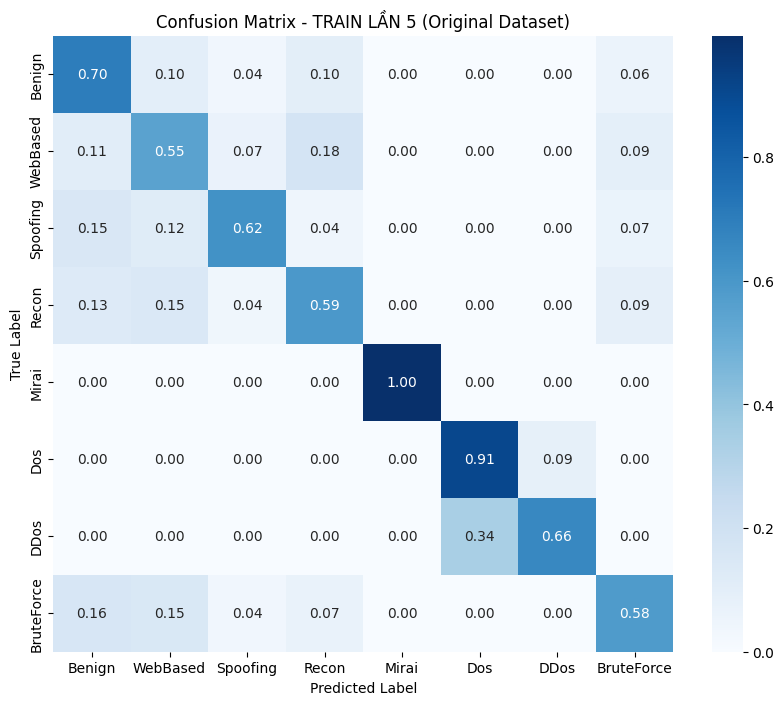

In [ ]:
# 5. CONFUSION MATRIX (LẦN 5)
cm_v5 = confusion_matrix(labels_v5, preds_v5, normalize='true')
plt.figure(figsize=(10, 8))
ax = plt.axes()
sns.heatmap(cm_v5, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
plt.title('Confusion Matrix - TRAIN LẦN 5 (Original Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

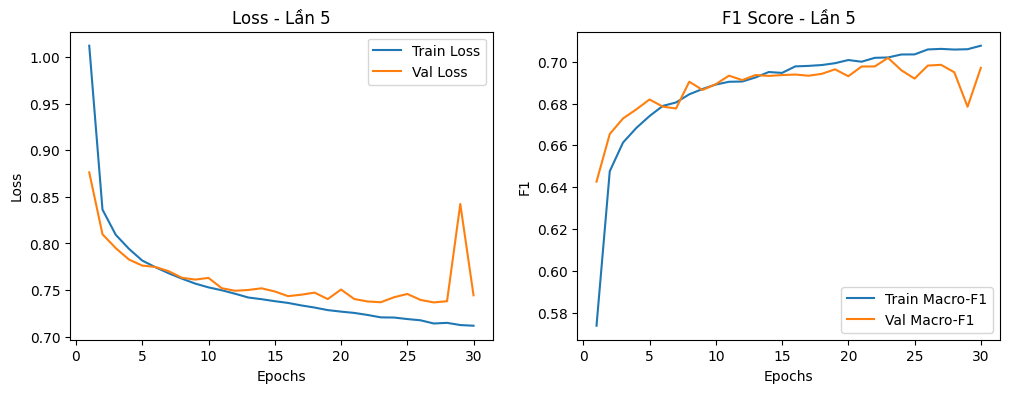

In [ ]:
# 6. TRAINING CURVE (LẦN 5)
epochs_range_v5 = [h['epoch'] for h in history_v5]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range_v5, [h['loss'] for h in history_v5], label='Train Loss')
ax1.plot(epochs_range_v5, [h['val_loss'] for h in history_v5], label='Val Loss')
ax1.set_title('Loss - Lần 5')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range_v5, [h['f1'] for h in history_v5], label='Train Macro-F1')
ax2.plot(epochs_range_v5, [h['val_f1'] for h in history_v5], label='Val Macro-F1')
ax2.set_title('F1 Score - Lần 5')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1')
ax2.legend()

plt.show()

In [ ]:
# 7. LƯU KẾT QUẢ VỀ DRIVE
import shutil, os
SAVE_TO_DRIVE = os.path.join(MERGED_CSV_DIR.split('/dataset')[0], 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)

shutil.copy('/content/xgnid_best_v5.pth', os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v5.pth'))
print('Đã lưu model xgnid_best_v5.pth về Google Drive thành công.')

Đã lưu model xgnid_best_v5.pth về Google Drive thành công.


# TRAIN LẦN 6 - DATA TÁC GIẢ, TIỀN XỬ LÝ LẠI

Tái sử dụng file dữ liệu của tác giả XG-NID để tận dụng được packet payload

Áp dụng thêm quy trình Làm Sạch Dữ Liệu:
1. **Gán bằng 0** toàn bộ các cột nhạy cảm như IP, MAC, Port để chống mô hình học vẹt. Việc zero-out thay vì `.drop()` giúp cấu trúc file CSV không bị xô lệch, đảm bảo tương thích với class NIDSDataset của tác giả.
2. **Drop Duplicates** để khử oversampling quá mức
3. **Lấy mẫu cân bằng** để ép tất cả các lớp về mức đồng đều (tối đa 5000 mẫu/lớp), chống overfitting lớp đa số.

In [ ]:
# 0. SO SÁNH FEATURES: Tác giả vs CICFlowMeter thô
import pandas as pd
import os

# 39 features thô từ CICFlowMeter
RAW_CICFLOWMETER_FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
    'ack_flag_number', 'ece_flag_number', 'cwr_flag_number',
    'ack_count', 'syn_count', 'fin_count', 'rst_count',
    'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance'
]

DRIVE_DATA_PATH = '/content/drive/MyDrive/network-attack'
AUTHOR_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')

if os.path.exists(AUTHOR_CSV):
    # Đọc 10 dòng đầu để Pandas tự suy luận kiểu dữ liệu
    df_sample = pd.read_csv(AUTHOR_CSV, nrows=10)
    author_cols = list(df_sample.columns)

    numeric_cols = df_sample.select_dtypes(include='number').columns.tolist()
    string_cols = df_sample.select_dtypes(exclude='number').columns.tolist()

    raw_set = set(RAW_CICFLOWMETER_FEATURES)
    author_set = set(author_cols)

    added_features = sorted(author_set - raw_set - {'Label', 'label'})
    removed_features = sorted(raw_set - author_set)

    print('=' * 70)
    print(f'TỔNG SỐ CỘT trong file tác giả: {len(author_cols)}')
    print(f'   + Số cột kiểu SỐ (Numeric) : {len(numeric_cols)} (Dùng làm Flow Node)')
    print(f'   + Số cột kiểu CHUỖI (Text) : {len(string_cols)} (Chứa Label, Payload, Metadata)')
    print('=' * 70)

    print(f'\n[A] CHI TIẾT {len(string_cols)} CỘT CHUỖI (TEXT):')
    for i, c in enumerate(string_cols, 1):
        print(f'  {i:2d}. {c:<40}')

    print(f'\n[B] {len(added_features)} CỘT TÁC GIẢ TỰ THÊM (Feature Engineering từ NFStream):')
    for i, f in enumerate(added_features, 1):
        dtype_str = str(df_sample[f].dtype)
        print(f'  {i:2d}. {f:<45} (Kiểu DL: {dtype_str})')

    if removed_features:
        print(f'\n[C] {len(removed_features)} CỘT THÔ CICFlowMeter BỊ XÓA/ĐỔI TÊN:')
        for i, f in enumerate(removed_features, 1):
            print(f'  {i:2d}. {f}')

    print(f'\n' + '=' * 70)
    print(f'KẾT LUẬN: Tác giả đã Feature Engineering thêm {len(added_features)} cột mới.')
    print(f'Đồng thời giữ {len(string_cols)} cột chuỗi, trong đó udps.payload_data chứa Payload Hex.')
    print('=' * 70)
else:
    print('Không tìm thấy file tác giả. Hãy mount Google Drive trước.')


TỔNG SỐ CỘT trong file tác giả: 97
   + Số cột kiểu SỐ (Numeric) : 83 (Dùng làm Flow Node)
   + Số cột kiểu CHUỖI (Text) : 14 (Chứa Label, Payload, Metadata)

[A] CHI TIẾT 14 CỘT CHUỖI (TEXT):
   1. udps.payload_data                       
   2. udps.delta_time                         
   3. udps.packet_direction                   
   4. udps.ip_size                            
   5. udps.transport_size                     
   6. udps.payload_size                       
   7. udps.syn                                
   8. udps.cwr                                
   9. udps.ece                                
  10. udps.urg                                
  11. udps.ack                                
  12. udps.psh                                
  13. udps.rst                                
  14. udps.fin                                

[B] 96 CỘT TÁC GIẢ TỰ THÊM (Feature Engineering từ NFStream):
   1. Exp_-1                                        (Kiểu DL: int64)
   2. Exp_0      

In [ ]:
# 1. TIỀN XỬ LÝ (CLEANING) DATASET CỦA TÁC GIẢ
import pandas as pd
import numpy as np
import os

DRIVE_DATA_PATH = '/content/drive/MyDrive/network-attack'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

def clean_author_dataset(input_csv, output_csv, samples_per_class=5000):
    print(f"Đang xử lý: {input_csv}")
    df = pd.read_csv(input_csv)
    orig_len = len(df)
    print(f"  - Số dòng ban đầu của tác giả: {orig_len}")

    if 'Label' in df.columns:
        label_col = 'Label'
    elif 'label' in df.columns:
        label_col = 'label'
    else:
        label_col = df.columns[-1]

    # 1. Khử Oversampling (Xóa các dòng trùng lặp hoàn toàn)
    df = df.drop_duplicates()
    dedup_len = len(df)
    dup_count = orig_len - dedup_len
    dup_pct = (dup_count / orig_len) * 100 if orig_len > 0 else 0
    print(f"  - Số dòng sau khi xóa trùng lặp: {dedup_len}")
    print(f"  --> PHÁT HIỆN: Tác giả đã copy-paste nhân bản {dup_count} dòng (chiếm {dup_pct:.1f}% dataset) gây Overfitting!")
    print(f"  --> Phân phối THỰC TẾ các lớp (sau khi xóa ảo):")
    for k, v in df[label_col].value_counts().items():
        print(f"        + Class {k}: {v} dòng")

    # 2. Khử Bias (Zero-out IP, MAC, Port, Timestamp, Flow ID)
    bias_keywords = ['ip', 'mac', 'port', 'timestamp', 'flow id']
    bias_cols = [c for c in df.columns if any(k in c.lower() for k in bias_keywords) and 'udps' not in c.lower()]

    for c in bias_cols:
        df[c] = 0.0
    print(f"\n  - Đã zero-out {len(bias_cols)} cột chứa rủi ro học vẹt: {bias_cols}")

    # 3. Balanced Undersampling
    dfs = []
    for label, group in df.groupby(label_col):
        n_samples = min(samples_per_class, len(group))
        dfs.append(group.sample(n=n_samples, random_state=42))

    df_balanced = pd.concat(dfs, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)
    bal_len = len(df_balanced)

    print(f"  - Số dòng sau khi lấy mẫu cân bằng (tối đa {samples_per_class}/class): {bal_len}")
    print(f"  --> KẾT LUẬN: Tác giả train trên {orig_len} dòng, nhưng thực chất chỉ có {bal_len} dòng dữ liệu sạch và cân bằng!\n")
    df_balanced.to_csv(output_csv, index=False)
    return df_balanced

# Chạy tiền xử lý
CLEANED_TRAIN = '/content/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/content/df_class_8_test_cleaned.csv'

if os.path.exists(TRAIN_CSV):
    clean_author_dataset(TRAIN_CSV, CLEANED_TRAIN, samples_per_class=5000)
    clean_author_dataset(TEST_CSV, CLEANED_TEST, samples_per_class=2000)
else:
    print("Không tìm thấy file gốc trên Drive. Hãy mount Google Drive trước.")

Đang xử lý: /content/drive/MyDrive/network-attack/df_class_8_train.csv
  - Số dòng ban đầu của tác giả: 160000
  - Số dòng sau khi xóa trùng lặp: 112343
  --> PHÁT HIỆN: Tác giả đã copy-paste nhân bản 47657 dòng (chiếm 29.8% dataset) gây Overfitting!
  --> Phân phối THỰC TẾ các lớp (sau khi xóa ảo):
        + Class 4: 20000 dòng
        + Class 6: 19941 dòng
        + Class 0: 19916 dòng
        + Class 3: 19036 dòng
        + Class 2: 14591 dòng
        + Class 5: 12632 dòng
        + Class 1: 4358 dòng
        + Class 7: 1869 dòng

  - Đã zero-out 5 cột chứa rủi ro học vẹt: ['Unique_Ports_In_SourceDestinationIP', 'Rolling_http_port_SourceDestination', 'Rolling_http_port_Destination', 'Rolling_vulnerable_port', 'Rolling_bipackets_destination']
  - Số dòng sau khi lấy mẫu cân bằng (tối đa 5000/class): 36227
  --> KẾT LUẬN: Tác giả train trên 160000 dòng, nhưng thực chất chỉ có 36227 dòng dữ liệu sạch và cân bằng!

Đang xử lý: /content/drive/MyDrive/network-attack/df_class_8_test.csv
  

In [ ]:
# 2. KHỞI TẠO DATALOADER VỚI PAYLOAD THỰC TẾ (CÓ CACHE LÊN DRIVE)
import glob, subprocess, os, sys
from torch_geometric.loader import DataLoader

if not os.path.exists('/content/GNN4ID'):
    subprocess.run(["git", "clone", "https://github.com/Yasir-ali-farrukh/GNN4ID.git", "/content/GNN4ID"])
if '/content/GNN4ID' not in sys.path:
    sys.path.insert(0, '/content/GNN4ID')

from Utility.Functions import NIDSDataset

GRAPH_STORE_V6 = '/content/graph_data_v6'
GRAPH_ZIP_PATH_V6 = os.path.join(DRIVE_DATA_PATH, 'dataset/graph_objects_v6.zip')

already_built_train = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_[0-9]*.pt')) > 500
already_built_test  = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_test_*.pt')) > 100

if not (already_built_train and already_built_test):
    if os.path.exists(GRAPH_ZIP_PATH_V6):
        print('Tìm thấy file zip chứa Đồ thị trên Drive, đang giải nén...')
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH_V6, '-d', '/'], check=True)
        print('Giải nén xong.')
        already_built_train = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_[0-9]*.pt')) > 500
        already_built_test  = len(glob.glob(GRAPH_STORE_V6 + '/processed/data_test_*.pt')) > 100

skip = already_built_train and already_built_test
print(f'Graph objects sẵn sàng: train={already_built_train}, test={already_built_test}')
print(f'→ {"Load nhanh từ file .pt có sẵn" if skip else "Parse đồ thị mới từ CSV (Sẽ mất thời gian do parse hàng ngàn Packet payload)"}')

print('\nĐang nạp tập Train dataset...')
train_dataset_v6 = NIDSDataset(
    root=GRAPH_STORE_V6,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TRAIN],
    skip_processing=skip,
    test=False,
    single_file=True,
)

print('Đang nạp tập Test dataset...')
test_dataset_v6 = NIDSDataset(
    root=GRAPH_STORE_V6,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TEST],
    skip_processing=skip,
    test=True,
    single_file=True,
)

# Nén và lưu lên Drive nếu vừa parse mới
if not skip:
    print('\nĐang nén toàn bộ Đồ thị (.pt) thành file ZIP để lưu lên Google Drive...')
    os.makedirs(os.path.dirname(GRAPH_ZIP_PATH_V6), exist_ok=True)
    # zip root directory into the zip file. GRAPH_STORE_V6[1:] avoids absolute path warning in zip
    subprocess.run(['zip', '-r', '-q', GRAPH_ZIP_PATH_V6, GRAPH_STORE_V6[1:]], cwd='/', check=True)
    print(f'Đã lưu thành công: {GRAPH_ZIP_PATH_V6}')

train_loader_v6 = DataLoader(train_dataset_v6, batch_size=128, shuffle=True)
test_loader_v6 = DataLoader(test_dataset_v6, batch_size=128, shuffle=False)
print(f"\nDataLoaders sẵn sàng! Train: {len(train_dataset_v6):,} graphs, Test: {len(test_dataset_v6):,} graphs")

Graph objects sẵn sàng: train=False, test=False
→ Parse đồ thị mới từ CSV (Sẽ mất thời gian do parse hàng ngàn Packet payload)

Đang nạp tập Train dataset...


Processing...
Reading File ---> df_class_8_train_cleaned.csv
100%|██████████| 36227/36227 [02:22<00:00, 254.39it/s]
Done!
Processing...


Đang nạp tập Test dataset...


Reading File ---> df_class_8_test_cleaned.csv
100%|██████████| 13557/13557 [00:50<00:00, 271.00it/s]
Done!



Đang nén toàn bộ Đồ thị (.pt) thành file ZIP để lưu lên Google Drive...
Đã lưu thành công: /content/drive/MyDrive/network-attack/dataset/graph_objects_v6.zip

DataLoaders sẵn sàng! Train: 36,227 graphs, Test: 13,557 graphs


In [ ]:
# 3. KHỞI TẠO MÔ HÌNH HETEROGNN_EDGE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ARGS_V6 = {
    'hidden_size': 64,
    'epochs':      30,
    'lr':          0.001,
    'eps':         1.0
}
model = HeteroGNN_Edge(train_dataset_v6[0].to(device), ARGS_V6, aggr='mean').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ARGS_V6['lr'])

In [ ]:
# 4. TRAINING LOOP LẦN 6
best_f1_v6 = 0.0
history_v6 = []

print("Bắt đầu TRAIN LẦN 6 (với Packet Payload gốc đã khử bias)...")
for epoch in range(1, ARGS_V6['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(train_loader_v6, train=True)
    val_loss, val_acc, val_f1, preds_v6, labels_v6 = run_epoch(test_loader_v6, train=False)

    history_v6.append({
        'epoch': epoch,
        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1
    })
    print(f'Epoch {epoch:3d}/{ARGS_V6["epochs"]} | Train Loss: {tr_loss:.4f} | Train F1: {tr_f1:.4f} || Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_f1_v6:
        best_f1_v6 = val_f1
        torch.save(model.state_dict(), '/content/xgnid_best_v6.pth')

print(f'\nBest Val Macro-F1: {best_f1_v6:.4f}')
model.load_state_dict(torch.load('/content/xgnid_best_v6.pth', map_location=device))
_, _, _, preds_v6, labels_v6 = run_epoch(test_loader_v6, train=False)

Bắt đầu TRAIN LẦN 6 (với Packet Payload gốc đã khử bias)...


Train:   0%|          | 0/284 [00:00<?, ?it/s]

Test:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch   1/30 | Train Loss: 0.6438 | Train F1: 0.7575 || Val Loss: 0.3103 | Val F1: 0.8703


Train:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch  29/30 | Train Loss: 0.1484 | Train F1: 0.9448 || Val Loss: 0.1827 | Val F1: 0.9297


Train:   0%|          | 0/284 [00:00<?, ?it/s]

Test:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch  30/30 | Train Loss: 0.1331 | Train F1: 0.9505 || Val Loss: 0.1700 | Val F1: 0.9405

Best Val Macro-F1: 0.9420


Test:   0%|          | 0/106 [00:00<?, ?it/s]

In [ ]:
# 5. ĐÁNH GIÁ VÀ BÁO CÁO LẦN 6
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 6:")
print(classification_report(labels_v6, preds_v6, target_names=CLASS_NAMES, digits=4))


BÁO CÁO PHÂN LOẠI TRAIN LẦN 6:
              precision    recall  f1-score   support

      Benign     0.9385    0.9315    0.9350      2000
    WebBased     0.7798    0.9615    0.8611      1090
    Spoofing     0.9120    0.9070    0.9095      2000
       Recon     0.9331    0.8505    0.8899      2000
       Mirai     1.0000    0.9990    0.9995      2000
         Dos     0.9918    0.9655    0.9785      2000
        DDos     1.0000    0.9995    0.9997      2000
  BruteForce     0.9576    0.9679    0.9627       467

    accuracy                         0.9446     13557
   macro avg     0.9391    0.9478    0.9420     13557
weighted avg     0.9477    0.9446    0.9451     13557



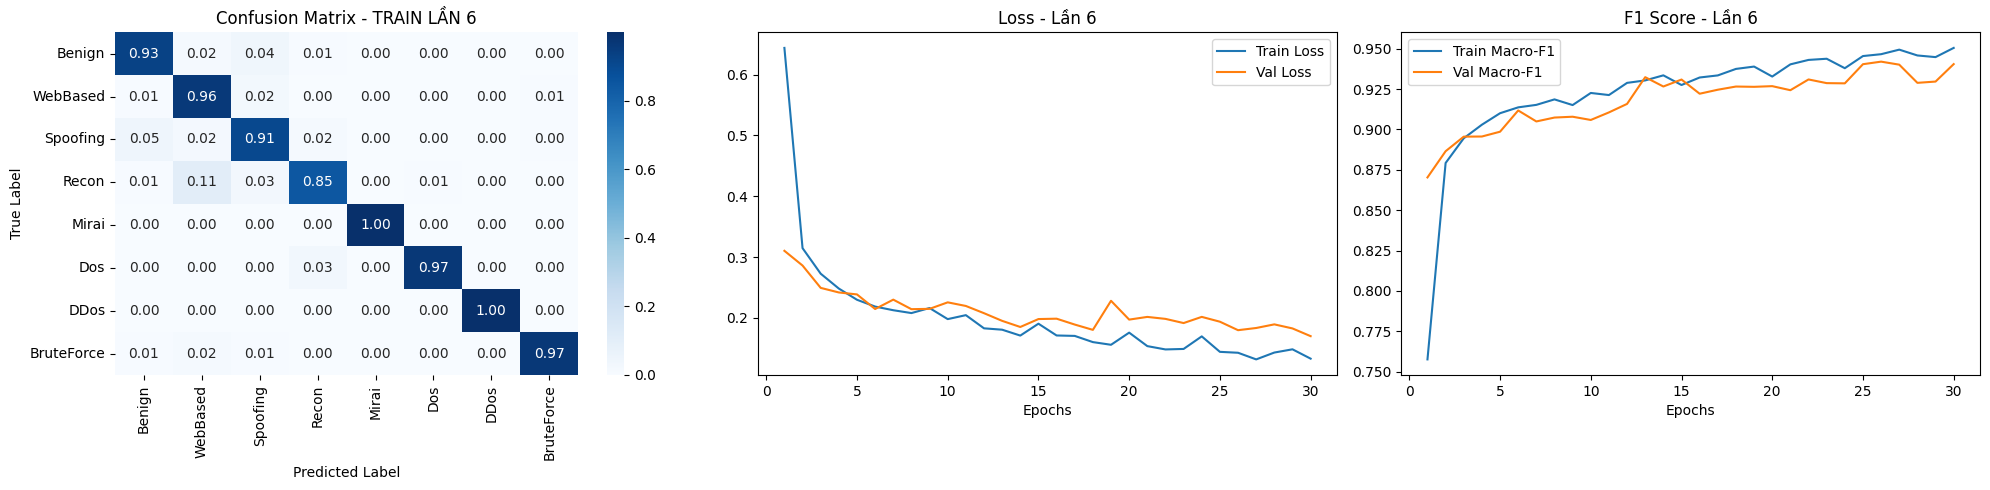

Đã lưu model xgnid_best_v6.pth về Google Drive thành công.


In [ ]:
# 6. BIỂU ĐỒ VÀ LƯU TRỮ LẦN 6
cm_v6 = confusion_matrix(labels_v6, preds_v6, normalize='true')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(cm_v6, annot=True, cmap='Blues', fmt='.2f', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix - TRAIN LẦN 6')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

epochs_range_v6 = [h['epoch'] for h in history_v6]
axes[1].plot(epochs_range_v6, [h['loss'] for h in history_v6], label='Train Loss')
axes[1].plot(epochs_range_v6, [h['val_loss'] for h in history_v6], label='Val Loss')
axes[1].set_title('Loss - Lần 6')
axes[1].set_xlabel('Epochs')
axes[1].legend()

axes[2].plot(epochs_range_v6, [h['f1'] for h in history_v6], label='Train Macro-F1')
axes[2].plot(epochs_range_v6, [h['val_f1'] for h in history_v6], label='Val Macro-F1')
axes[2].set_title('F1 Score - Lần 6')
axes[2].set_xlabel('Epochs')
axes[2].legend()

plt.tight_layout()
plt.show()

import shutil
SAVE_TO_DRIVE = os.path.join(DRIVE_DATA_PATH, 'saved_models')
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)
shutil.copy('/content/xgnid_best_v6.pth', os.path.join(SAVE_TO_DRIVE, 'xgnid_best_v6.pth'))
print('Đã lưu model xgnid_best_v6.pth về Google Drive thành công.')

# TRAIN LẦN 7: ZERO-OUT PAYLOAD TỪ DATASET LẦN 6
Mục tiêu: Đánh giá xem nếu xóa toàn bộ nội dung Payload (ép vector Packet 1500-dim về 0) nhưng VẪN GIỮ NGUYÊN cấu trúc Đồ thị (Edges) và 82 Flow Features, thì hiệu suất mô hình sẽ thay đổi ra sao so với Train 6

In [ ]:
# 1. ĐỊNH NGHĨA HÀM RUN_EPOCH_V7 (ABLATION STUDY: ZERO-OUT PAYLOAD)
def run_epoch_v7(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train V7' if train else 'Test V7'
    with ctx:
        for batch in tqdm(loader, desc=desc, leave=False):
            batch = batch.to(device)

            # TRỌNG TÂM CỦA TRAIN 7: ÉP TOÀN BỘ PAYLOAD GÓI TIN VỀ 0
            # Nhưng vẫn GIỮ NGUYÊN cấu trúc đồ thị (edges) và 82 flow features!
            batch['packet'].x = torch.zeros_like(batch['packet'].x)

            out = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            loss = model.loss(out, batch.y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
            n += batch.num_graphs
            all_preds.append(out.max(1)[1].cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1, preds, labels

In [ ]:
# 2. TRAINING LOOP LẦN 7 (ABLATION STUDY)
# Khởi tạo lại model để train từ đầu
model = HeteroGNN_Edge(train_dataset_v6[0].to(device), ARGS_V6, aggr='mean').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_f1_v7 = 0.0
history_v7 = []
patience = 5
patience_counter = 0

print("Bắt đầu TRAIN LẦN 7: ABLATION STUDY (ZERO-OUT PAYLOAD)...")
for epoch in range(1, ARGS_V6['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch_v7(train_loader_v6, train=True)
    val_loss, val_acc, val_f1, preds_v7, labels_v7 = run_epoch_v7(test_loader_v6, train=False)

    history_v7.append({
        'epoch': epoch,
        'loss': tr_loss, 'acc': tr_acc, 'f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1
    })

    if val_f1 > best_f1_v7:
        best_f1_v7 = val_f1
        torch.save(model.state_dict(), '/content/drive/MyDrive/network-attack/xgnid_best_v7.pth')
        print(f'Epoch {epoch:3d}/{ARGS_V6["epochs"]} | Train F1: {tr_f1:.4f} || Val F1: {val_f1:.4f} --> [LƯU CHECKPOINT]')
    else:
        print(f'Epoch {epoch:3d}/{ARGS_V6["epochs"]} | Train F1: {tr_f1:.4f} || Val F1: {val_f1:.4f}')

print(f'\nBest Val Macro-F1 (V7): {best_f1_v7:.4f}')
model.load_state_dict(torch.load('/content/drive/MyDrive/network-attack/xgnid_best_v7.pth', map_location=device))
_, _, _, preds_v7, labels_v7 = run_epoch_v7(test_loader_v6, train=False)


Bắt đầu TRAIN LẦN 7: ABLATION STUDY (ZERO-OUT PAYLOAD)...


Train V7:   0%|          | 0/284 [00:00<?, ?it/s]

Test V7:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch   1/30 | Train F1: 0.6841 || Val F1: 0.8002 --> [LƯU CHECKPOINT]


Train V7:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch  29/30 | Train F1: 0.9219 || Val F1: 0.9212 --> [LƯU CHECKPOINT]


Train V7:   0%|          | 0/284 [00:00<?, ?it/s]

Test V7:   0%|          | 0/106 [00:00<?, ?it/s]

Epoch  30/30 | Train F1: 0.9187 || Val F1: 0.9143

Best Val Macro-F1 (V7): 0.9212


Test V7:   0%|          | 0/106 [00:00<?, ?it/s]

In [ ]:
print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 6:")
print(classification_report(labels_v6, preds_v6, target_names=CLASS_NAMES, digits=4))


BÁO CÁO PHÂN LOẠI TRAIN LẦN 6:
              precision    recall  f1-score   support

      Benign     0.9385    0.9315    0.9350      2000
    WebBased     0.7798    0.9615    0.8611      1090
    Spoofing     0.9120    0.9070    0.9095      2000
       Recon     0.9331    0.8505    0.8899      2000
       Mirai     1.0000    0.9990    0.9995      2000
         Dos     0.9918    0.9655    0.9785      2000
        DDos     1.0000    0.9995    0.9997      2000
  BruteForce     0.9576    0.9679    0.9627       467

    accuracy                         0.9446     13557
   macro avg     0.9391    0.9478    0.9420     13557
weighted avg     0.9477    0.9446    0.9451     13557



In [ ]:
print("\nBÁO CÁO PHÂN LOẠI TRAIN LẦN 7 (ZERO-OUT PAYLOAD):")
print(classification_report(labels_v7, preds_v7, target_names=CLASS_NAMES, digits=4))


BÁO CÁO PHÂN LOẠI TRAIN LẦN 7 (ZERO-OUT PAYLOAD):
              precision    recall  f1-score   support

      Benign     0.8705    0.9210    0.8950      2000
    WebBased     0.8263    0.7945    0.8101      1090
    Spoofing     0.9210    0.8220    0.8687      2000
       Recon     0.8547    0.9415    0.8960      2000
       Mirai     1.0000    0.9965    0.9982      2000
         Dos     0.9937    0.9520    0.9724      2000
        DDos     1.0000    0.9995    0.9997      2000
  BruteForce     0.9014    0.9593    0.9295       467

    accuracy                         0.9279     13557
   macro avg     0.9210    0.9233    0.9212     13557
weighted avg     0.9295    0.9279    0.9277     13557



# TRAIN LẦN 8: DATASET ACI-IoT-2023 (có giữ payload)

In [ ]:
import pandas as pd
import os

BASE_DIR = '/content/drive/MyDrive/network-attack'
FLOW_FILE = os.path.join(BASE_DIR, 'dataset/new-dataset/ACI-IoT-2023.csv')

KNOWN_CLASSES = ['Benign', 'Port Scan', 'ICMP Flood', 'Ping Sweep','DNS Flood', 'Vulnerability Scan', 'OS Scan', 'Slowloris', 'SYN Flood']

print("ĐANG PHÂN TÍCH TOÀN DIỆN TẬP DỮ LIỆU ACI-IoT-2023...")
df_temp = pd.read_csv(FLOW_FILE, usecols=['Label'])
total_counts = df_temp['Label'].value_counts()

print("\n[1] PHÂN BỔ 12 LỚP BAN ĐẦU (ALL CLASSES):")
print("-" * 50)
print(total_counts)
print("-" * 50)

print("\n[2] PHÂN TÁCH ZERO-DAY (OOD):")
print("-" * 50)
ood_classes = [cls for cls in total_counts.index if cls not in KNOWN_CLASSES]
for cls in ood_classes:
    print(f"- Đẩy lớp '{cls}' ({total_counts[cls]} mẫu) vào tập Kiểm thử Zero-Day.")

print("\n[3] PHÂN BỔ 9 LỚP ĐÃ BIẾT (KNOWN CLASSES - DÙNG ĐỂ TRAIN):")
df_known = df_temp[df_temp['Label'].isin(KNOWN_CLASSES)]
class_counts = df_known['Label'].value_counts()
print(class_counts)

min_samples = class_counts.min()
min_class = class_counts.idxmin()
print(f"\n=> Class Known có số mẫu ÍT NHẤT là '{min_class}' với {min_samples} luồng.")
print(f"=> Mốc cân bằng (Strict Threshold) được chốt ở mức: {min_samples} mẫu / 1 Class.")
print(f"=> Tổng số luồng đưa vào bộ nhớ RAM sau khi Undersampling: {min_samples * len(KNOWN_CLASSES)} luồng.")

ĐANG PHÂN TÍCH TOÀN DIỆN TẬP DỮ LIỆU ACI-IoT-2023...

[1] PHÂN BỔ 12 LỚP BAN ĐẦU (ALL CLASSES):
--------------------------------------------------
Label
Port Scan             441282
Benign                329295
ICMP Flood            225234
Ping Sweep             71928
DNS Flood              46935
Vulnerability Scan     39537
OS Scan                37524
Slowloris              18643
SYN Flood              13857
Dictionary Attack       6380
UDP Flood                791
ARP Spoofing               5
Name: count, dtype: int64
--------------------------------------------------

[2] PHÂN TÁCH ZERO-DAY (OOD):
--------------------------------------------------
- Đẩy lớp 'Dictionary Attack' (6380 mẫu) vào tập Kiểm thử Zero-Day.
- Đẩy lớp 'UDP Flood' (791 mẫu) vào tập Kiểm thử Zero-Day.
- Đẩy lớp 'ARP Spoofing' (5 mẫu) vào tập Kiểm thử Zero-Day.

[3] PHÂN BỔ 9 LỚP ĐÃ BIẾT (KNOWN CLASSES - DÙNG ĐỂ TRAIN):
Label
Port Scan             441282
Benign                329295
ICMP Flood            225234


In [ ]:
FLOW_FILE    = '/content/drive/MyDrive/network-attack/dataset/new-dataset/ACI-IoT-2023.csv'
PAYLOAD_FILE = '/content/drive/MyDrive/network-attack/dataset/new-dataset/ACI-IoT-2023-Payload.csv'

df1 = pd.read_csv(FLOW_FILE)
df2 = pd.read_csv(PAYLOAD_FILE)

print(df1.shape)
print(df2.shape)

(1231411, 85)
(631486, 10)


In [ ]:
import pandas as pd
import numpy as np
import os
import json
import gc

OUT_FILE = os.path.join(BASE_DIR, 'dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv')
PAYLOAD_FILE = os.path.join(BASE_DIR, 'dataset/new-dataset/ACI-IoT-2023-Payload.csv')

def build_flow_key(ip_src, ip_dst, p_src, p_dst, proto):
    # Ép kiểu an toàn, chống lỗi .0 của float trong pandas
    ip_src = ip_src.astype(str).str.strip()
    ip_dst = ip_dst.astype(str).str.strip()

    p_src = p_src.astype(str).str.replace('.0', '', regex=False).str.strip()
    p_dst = p_dst.astype(str).str.replace('.0', '', regex=False).str.strip()
    proto = proto.astype(str).str.replace('.0', '', regex=False).str.strip()

    # Chuẩn hóa giao thức nếu 1 bên dùng chữ (TCP), 1 bên dùng số (6)
    proto_map = {'TCP': '6', 'tcp': '6', 'UDP': '17', 'udp': '17', 'ICMP': '1', 'icmp': '1'}
    proto = proto.replace(proto_map)

    ip1 = np.where(ip_src < ip_dst, ip_src, ip_dst)
    ip2 = np.where(ip_src < ip_dst, ip_dst, ip_src)
    p1 = np.where(ip_src < ip_dst, p_src, p_dst)
    p2 = np.where(ip_src < ip_dst, p_dst, p_src)

    return ip1 + '-' + ip2 + '-' + p1 + '-' + p2 + '-' + proto


def parse_payload(p):
    arr = [0] * 1500
    if pd.isna(p): return arr
    p_str = str(p).strip()
    try:
        b = bytes.fromhex(p_str)
    except:
        b = p_str.encode('utf-8', errors='ignore')
    for i in range(min(1500, len(b))):
        arr[i] = b[i]
    return arr

if not os.path.exists(OUT_FILE):
    print("BƯỚC 1: LỌC BỎ ZERO-DAY VÀ LẤY MẪU CÂN BẰNG TẬP FLOW (UNDERSAMPLING)...")
    df_flow = pd.read_csv(FLOW_FILE)
    df_flow = df_flow[df_flow['Label'].isin(KNOWN_CLASSES)] # Chỉ lấy 9 lớp
    df_flow['Flow_Key'] = build_flow_key(df_flow['Src IP'], df_flow['Dst IP'], df_flow['Src Port'], df_flow['Dst Port'], df_flow['Protocol'])

    df_flow_sampled = df_flow.groupby('Label', group_keys=False).apply(lambda x: x.sample(n=min_samples, replace=False)).copy()
    valid_flow_keys = set(df_flow_sampled['Flow_Key'].unique())
    print(f"  Số lượng Flow hợp lệ (được giữ lại): {len(valid_flow_keys)}")
    del df_flow
    gc.collect()

    print("\nBƯỚC 2: XỬ LÝ FILE PAYLOAD 5.5GB THEO CHUNKS VÀ BỎ QUA GÓI TIN RÁC...")
    chunk_size = 200000
    aggregated_payload = {}

    for i, chunk in enumerate(pd.read_csv(PAYLOAD_FILE, chunksize=chunk_size)):
        chunk['Flow_Key'] = build_flow_key(chunk['srcip'], chunk['dstip'], chunk['sport'], chunk['dsport'], chunk['protocol_m'])

        chunk = chunk[chunk['Flow_Key'].isin(valid_flow_keys)]
        if len(chunk) == 0:
            print(f"  Đang quét chunk {i+1}... (0 luồng khớp mã Flow_Key)")
            continue

        # chunk['payload_arr'] = chunk['payload'].apply(parse_payload)

        for key, group in chunk.groupby('Flow_Key'):
            if key not in aggregated_payload:
                aggregated_payload[key] = {'stime': [], 'total_len': [], 'payload': []}
            if len(aggregated_payload[key]['stime']) >= 20:
                continue

            aggregated_payload[key]['stime'].extend(group['stime'].tolist())
            aggregated_payload[key]['total_len'].extend(group['total_len'].tolist())
            aggregated_payload[key]['payload'].extend(group['payload'].tolist())

        print(f"  Đang quét chunk {i+1}... Đã gom được {len(aggregated_payload)} luồng.")
        del chunk
        gc.collect()

    print("\nBƯỚC 3: SẮP XẾP VÀ XUẤT RA DATAFRAME TẠM...")
    payload_records = []
    for key, data in aggregated_payload.items():
        stimes = np.array(data['stime'])
        lens = np.array(data['total_len'])
        payloads = data['payload']

        sort_idx = np.argsort(stimes)
        stimes = stimes[sort_idx]
        lens = lens[sort_idx]
        payloads = [payloads[idx] for idx in sort_idx]

        delta_time = np.zeros(len(stimes))
        if len(stimes) > 1:
            delta_time[1:] = stimes[1:] - stimes[:-1]

        max_pkts = 20
        payload_records.append({
            'Flow_Key': key,
            'udps.delta_time': json.dumps(delta_time[:max_pkts].tolist()),
            'udps.payload_size': json.dumps(lens[:max_pkts].tolist()),
            'udps.payload_data': json.dumps(payloads[:max_pkts])
        })

    df_agg_payload = pd.DataFrame(payload_records, columns=['Flow_Key', 'udps.delta_time', 'udps.payload_size', 'udps.payload_data']) if len(payload_records) > 0 else pd.DataFrame(columns=['Flow_Key', 'udps.delta_time', 'udps.payload_size', 'udps.payload_data'])
    del aggregated_payload
    gc.collect()

    print("\nBƯỚC 4: NỐI (LEFT JOIN) VÀ XUẤT FILE CUỐI CÙNG...")
    df_merged = pd.merge(df_flow_sampled, df_agg_payload, on='Flow_Key', how='left')
    print(f"Số lượng Đồ thị mạng thu được (Sau Undersampling): {len(df_merged)}")

    df_merged.to_csv(OUT_FILE, index=False)
    print(f"Đã xuất file an toàn tại: {OUT_FILE}")
    del df_flow_sampled, df_agg_payload, df_merged
    gc.collect()
else:
    print(f"File gộp đã tồn tại: {OUT_FILE}")

File gộp đã tồn tại: /content/drive/MyDrive/network-attack/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv


In [ ]:
import pandas as pd
import json

FILE_PATH = '/content/drive/MyDrive/network-attack/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv'

print("Đang tải dữ liệu, vui lòng đợi...")
df = pd.read_csv(FILE_PATH)
total_flows = len(df)

# Tính số luồng bị NaN ở cột payload (do quá trình Left Join sinh ra)
nan_payloads = df['udps.payload_data'].isna().sum()

# Tính số luồng có payload nhưng là mảng rỗng "[]" (Không có gói tin L7 nào)
empty_list_payloads = (df['udps.payload_data'] == '[]').sum()

# Tính số luồng chứa duy nhất mảng rỗng '[""]' (Có gói tin nhưng phần Data L7 trống trơn, thường gặp ở Ping, ICMP, SYN)
empty_string_payloads = (df['udps.payload_data'] == '[""]').sum()

print("="*60)
print(f"TỔNG SỐ LUỒNG (FLOWS) HIỆN CÓ: {total_flows:,}")
print("-"*60)
print(f"Số luồng bị KHUYẾT (NaN) payload: {nan_payloads:,}")
print(f"Số luồng có payload RỖNG ([]): {empty_list_payloads:,}")
print(f"Số luồng chứa 1 chuỗi payload trống ([\"\"]): {empty_string_payloads:,}")

total_loss = nan_payloads + empty_list_payloads + empty_string_payloads
valid_flows = total_flows - total_loss

print("="*60)
print(f"-> TỔNG SỐ LUỒNG THIẾU L7 (Từng bị xóa bởi Inner Join): {total_loss:,} (Chiếm {(total_loss/total_flows)*100:.2f}%)")
print(f"-> Số luồng CÓ DỮ LIỆU L7 thực tế: {valid_flows:,}")
print("="*60)

print("\nPhân bố các lớp tấn công của số luồng bị khuyết L7 này:")
df_missing = df[df['udps.payload_data'].isna() | (df['udps.payload_data'] == '[]') | (df['udps.payload_data'] == '[""]')]
print(df_missing['Label'].value_counts())


Đang tải dữ liệu, vui lòng đợi...


/tmp/ipykernel_14330/1309032098.py:7: DtypeWarning: Columns (86,87,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_PATH)


TỔNG SỐ LUỒNG (FLOWS) HIỆN CÓ: 124,713
------------------------------------------------------------
Số luồng bị KHUYẾT (NaN) payload: 108,012
Số luồng có payload RỖNG ([]): 0
Số luồng chứa 1 chuỗi payload trống ([""]): 0
-> TỔNG SỐ LUỒNG THIẾU L7 (Từng bị xóa bởi Inner Join): 108,012 (Chiếm 86.61%)
-> Số luồng CÓ DỮ LIỆU L7 thực tế: 16,701

Phân bố các lớp tấn công của số luồng bị khuyết L7 này:
Label
ICMP Flood            13857
Ping Sweep            13857
Port Scan             13853
OS Scan               13845
Vulnerability Scan    13769
SYN Flood             11744
Slowloris             11592
Benign                 8198
DNS Flood              7297
Name: count, dtype: int64


/tmp/ipykernel_14330/1828849823.py:6: DtypeWarning: Columns (86,87,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(MERGED_FILE)



Flow CÓ  payload:   16,701 (13.4%)
Flow KHÔNG payload:  108,012 (86.6%)

Số packet trung bình (flow có payload): 6.36
Trung vị: 2 | Max: 20


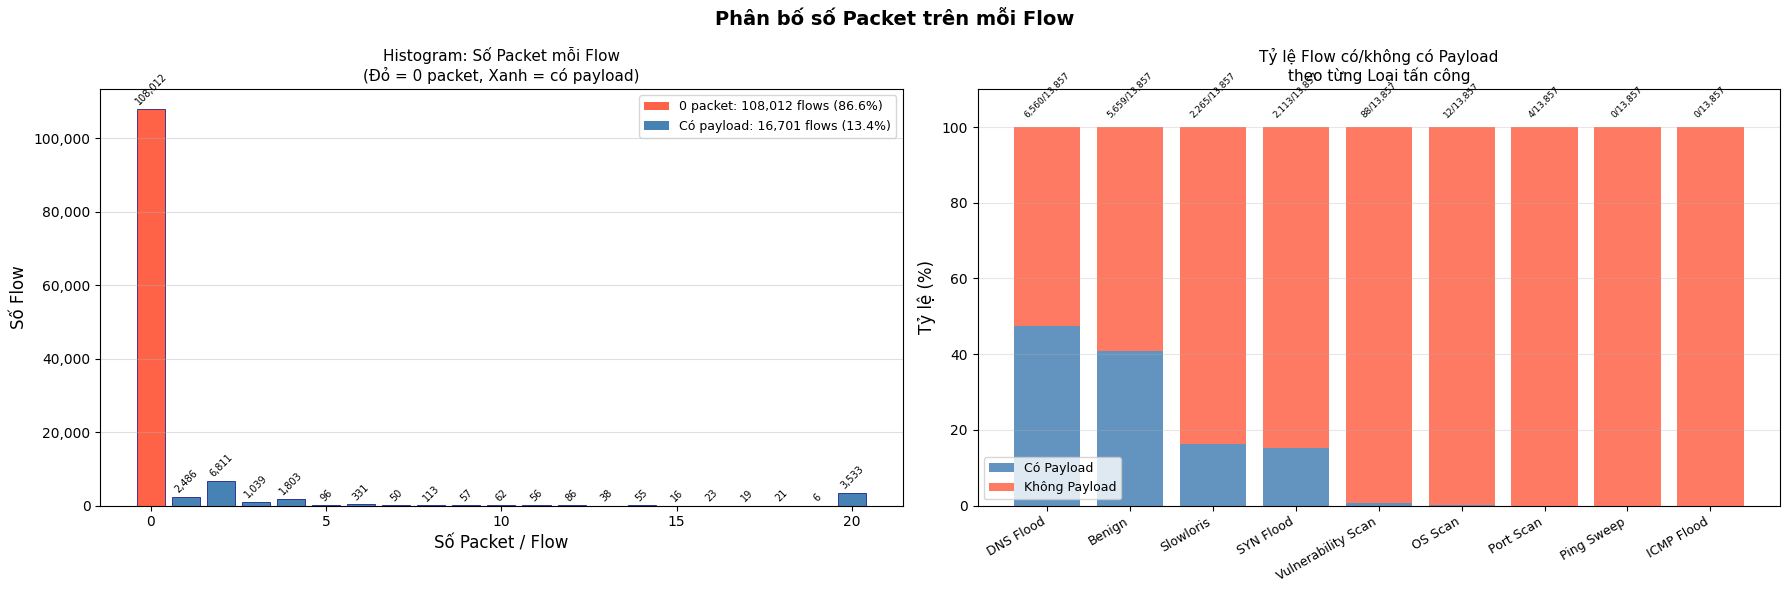

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

MERGED_FILE = '/content/drive/MyDrive/network-attack/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv'
df = pd.read_csv(MERGED_FILE)
def count_packets(x):
    try:
        return len(json.loads(x))
    except:
        return 0

df['n_packets'] = df['udps.payload_data'].apply(count_packets)
df_has  = df[df['n_packets'] > 0]
df_none = df[df['n_packets'] == 0]

print(f"\nFlow CÓ  payload: {len(df_has):>8,} ({len(df_has)/len(df)*100:.1f}%)")
print(f"Flow KHÔNG payload: {len(df_none):>8,} ({len(df_none)/len(df)*100:.1f}%)")
print(f"\nSố packet trung bình (flow có payload): {df_has['n_packets'].mean():.2f}")
print(f"Trung vị: {df_has['n_packets'].median():.0f} | Max: {df_has['n_packets'].max()}")

# ---- Vẽ biểu đồ ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Phân bố số Packet trên mỗi Flow', fontsize=14, fontweight='bold')

# [Biểu đồ 1] Histogram - gồm cả 0 packet
counts = Counter(df['n_packets'])
x = sorted(counts.keys())
y = [counts[k] for k in x]
colors = ['tomato' if xi == 0 else 'steelblue' for xi in x]
bars = axes[0].bar(x, y, color=colors, edgecolor='navy', linewidth=0.5, width=0.8)
axes[0].set_xlabel('Số Packet / Flow', fontsize=12)
axes[0].set_ylabel('Số Flow', fontsize=12)
axes[0].set_title('Histogram: Số Packet mỗi Flow\n(Đỏ = 0 packet, Xanh = có payload)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
axes[0].grid(axis='y', alpha=0.4)
for xi, yi in zip(x, y):
    axes[0].text(xi, yi + max(y)*0.005, f'{yi:,}', ha='center', va='bottom', fontsize=7, rotation=45)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor='tomato', label=f'0 packet: {counts[0]:,} flows ({counts[0]/len(df)*100:.1f}%)'),
    Patch(facecolor='steelblue', label=f'Có payload: {len(df_has):,} flows ({len(df_has)/len(df)*100:.1f}%)')
], fontsize=9)

# [Biểu đồ 2] Stacked bar: Tỷ lệ có/không có packet theo từng Label
label_stats = df.groupby('Label')['n_packets'].apply(
    lambda s: pd.Series({'có_packet': (s > 0).sum(), 'không_packet': (s == 0).sum()})
).unstack()
label_stats['total'] = label_stats.sum(axis=1)
label_stats = label_stats.sort_values('có_packet', ascending=False)
pct_co    = label_stats['có_packet']    / label_stats['total'] * 100
pct_khong = label_stats['không_packet'] / label_stats['total'] * 100
labels_x  = label_stats.index.tolist()
x_pos = range(len(labels_x))
axes[1].bar(x_pos, pct_co,    label='Có Payload',   color='steelblue', alpha=0.85)
axes[1].bar(x_pos, pct_khong, label='Không Payload', color='tomato',    alpha=0.85,
            bottom=pct_co)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels_x, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12)
axes[1].set_title('Tỷ lệ Flow có/không có Payload\ntheo từng Loại tấn công', fontsize=11)
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

for i, lbl in enumerate(labels_x):
    total = label_stats.loc[lbl, 'total']
    co    = label_stats.loc[lbl, 'có_packet']
    axes[1].text(i, 102, f'{co:,}/{total:,}', ha='center', va='bottom', fontsize=6.5, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import shutil, os
import torch
from torch_geometric.data import InMemoryDataset, HeteroData
import json as json_lib
import pandas as pd
import numpy as np

# Bước 0: XÓA CACHE CŨ
PROCESSED_DIR = '/content/dataset_aci_processed_v8_full/processed'
if os.path.exists(PROCESSED_DIR):
    shutil.rmtree(PROCESSED_DIR)
    print(f"[OK] Đã xóa cache cũ: {PROCESSED_DIR}")
else:
    print(f"[OK] Không có cache cũ.")

# Bước 1: Định nghĩa lại 9 Known Classes
KNOWN_CLASSES = ['Benign', 'Port Scan', 'ICMP Flood', 'Ping Sweep',
                 'DNS Flood', 'Vulnerability Scan', 'OS Scan', 'Slowloris', 'SYN Flood']
ACI_LABELS = {name: i for i, name in enumerate(KNOWN_CLASSES)}
CLASS_NAMES_ACI = list(ACI_LABELS.keys())

# Bước 2: Dataset class mới
class NIDSDataset_ACI_Payload(InMemoryDataset):
    def __init__(self, root, filename, label_dict, transform=None, pre_transform=None):
        self.filename = filename
        self.label_dict = label_dict
        super().__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def raw_file_names(self):
        return [self.filename]

    @property
    def processed_file_names(self):
        return ['data_aci_v8_FINAL_SUPER_CLEAN.pt']

    def process(self):
        print("Processing... (Tạo đồ thị MỚI có reverse edges)")
        df = pd.read_csv(self.raw_paths[0])
        print(f"  Đọc được {len(df)} dòng từ CSV")

        drop_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label',
                     'Connection Type', 'Flow_Key',
                     'udps.delta_time', 'udps.payload_size', 'udps.payload_data']
        numeric_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype in ['int64', 'float64']]
        print(f"  Số cột numeric (flow features): {len(numeric_cols)}")

        print("  [CLEAN] Đang làm sạch NaN và Infinity trong Dữ liệu Flow...")
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

        for col in numeric_cols:
            max_val = df[col].max()
            min_val = df[col].min()
            if max_val > min_val:
                df[col] = (df[col] - min_val) / (max_val - min_val)
            else:
                df[col] = 0.0

        data_list = []
        skipped = 0
        for index, row in df.iterrows():
            if index % 5000 == 0:
                print(f"  Đang xử lý dòng {index}/{len(df)}...")

            # Parse payload
            try:
                raw_payloads = json_lib.loads(row['udps.payload_data'])
                payload_data = []
                for p in raw_payloads:
                    if isinstance(p, str):
                        arr = [0] * 1500
                        p_str = p.strip()
                        try:
                            b = bytes.fromhex(p_str)
                        except:
                            b = p_str.encode('utf-8', errors='ignore')
                        for i in range(min(1500, len(b))):
                            arr[i] = b[i]
                        payload_data.append(arr)
                    elif isinstance(p, list):
                        payload_data.append(p)
                    else:
                        payload_data.append([0] * 1500)
            except:
                # NẾU KHÔNG CÓ PAYLOAD (Lỗi NaN do Left Join) -> TẠO 1 DUMMY PACKET TOÀN 0
                payload_data = [[0] * 1500]

            num_packets = len(payload_data)
            if num_packets == 0:
                payload_data = [[0] * 1500]
                num_packets = 1

            # Kiểm tra label hợp lệ
            label_name = row['Label']
            if label_name not in self.label_dict:
                skipped += 1
                continue

            data = HeteroData()

            # Flow node (1 node, N features)
            flow_feat = row[numeric_cols].values.astype(np.float32)
            data['flow'].x = torch.from_numpy(flow_feat.reshape(1, -1))

            # Packet nodes (M nodes, 1500 features each)
            data['packet'].x = torch.tensor(payload_data, dtype=torch.float) / 255.0

            # Edge attributes (Kèm lọc rác)
            def safe_list(lst):
                return [0.0 if np.isnan(v) or np.isinf(v) else v for v in lst]

            try:
                delta_times = safe_list(json_lib.loads(row['udps.delta_time']))
            except:
                delta_times = [0.0]

            try:
                payload_sizes = safe_list(json_lib.loads(row['udps.payload_size']))
            except:
                payload_sizes = [0.0]

            edge_src, edge_dst, edge_attr = [], [], []
            contain_src, contain_dst, contain_attr = [], [], []
            for i in range(num_packets):
                contain_src.append(0)
                contain_dst.append(i)
                p_size = payload_sizes[i] / 1500.0 if i < len(payload_sizes) else 0.0
                contain_attr.append([p_size])

            contain_edge_index = torch.tensor([contain_src, contain_dst], dtype=torch.long)
            contain_edge_attr = torch.tensor(contain_attr, dtype=torch.float)

            link_src, link_dst, link_attr = [], [], []
            for i in range(num_packets - 1):
                link_src.append(i)
                link_dst.append(i + 1)
                d_time = delta_times[i+1] / 100.0 if (i+1) < len(delta_times) else 0.0
                link_attr.append([d_time])

            if num_packets > 1:
                link_edge_index = torch.tensor([link_src, link_dst], dtype=torch.long)
                link_edge_attr = torch.tensor(link_attr, dtype=torch.float)
            else:
                link_edge_index = torch.empty((2, 0), dtype=torch.long)
                link_edge_attr = torch.empty((0, 1), dtype=torch.float)

            # === FORWARD EDGES: flow -> contain -> packet ===
            data['flow', 'contain', 'packet'].edge_index = contain_edge_index
            data['flow', 'contain', 'packet'].edge_attr = contain_edge_attr

            # === REVERSE EDGES: packet -> rev_contain -> flow ===
            data['packet', 'rev_contain', 'flow'].edge_index = torch.tensor([contain_dst, contain_src], dtype=torch.long)
            data['packet', 'rev_contain', 'flow'].edge_attr = contain_edge_attr.clone()

            # === LINK EDGES: packet -> link -> packet ===
            data['packet', 'link', 'packet'].edge_index = link_edge_index
            data['packet', 'link', 'packet'].edge_attr = link_edge_attr

            data.y = torch.tensor([self.label_dict[label_name]], dtype=torch.long)
            data_list.append(data)

        print(f"  Xong! Tạo được {len(data_list)} đồ thị (bỏ {skipped} dòng lỗi)")

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        print(f"  Đã lưu: {self.processed_paths[0]}")

# Bước 3: BUILD
OUT_FILE = '/content/drive/MyDrive/network-attack/dataset/new-dataset/Merged_ACI_IoT_Payload_Undersampled.csv'
dataset_aci_full = NIDSDataset_ACI_Payload(
    root='/content/dataset_aci_processed_v8_full',
    filename=OUT_FILE,
    label_dict=ACI_LABELS
)
print(f"\nTổng số đồ thị: {len(dataset_aci_full)}")

# Bước 4: CHẨN ĐOÁN
import collections
sample = dataset_aci_full[0]
print(f"Node types : {sample.node_types}")
print(f"Edge types : {sample.edge_types}")

label_counts = collections.Counter()
for i in range(len(dataset_aci_full)):
    label_counts[dataset_aci_full[i].y.item()] += 1

print(f"\nPhân bố label ({len(label_counts)} classes):")
for lid in sorted(label_counts.keys()):
    name = CLASS_NAMES_ACI[lid] if lid < len(CLASS_NAMES_ACI) else f"Unk_{lid}"
    print(f"Class {lid} ({name:18s}): {label_counts[lid]:>6,}")

missing = [i for i in range(len(KNOWN_CLASSES)) if i not in label_counts]
if missing:
    print(f"\nClasses thiếu: {[KNOWN_CLASSES[i] for i in missing]}")

[OK] Đã xóa cache cũ: /content/dataset_aci_processed_v8_full/processed
Processing... (Tạo đồ thị MỚI có reverse edges)


Processing...
/tmp/ipykernel_39641/1109607911.py:40: DtypeWarning: Columns (86,87,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(self.raw_paths[0])


  Đọc được 124713 dòng từ CSV
  Số cột numeric (flow features): 79
  [CLEAN] Đang làm sạch NaN và Infinity trong Dữ liệu Flow...
  Đang xử lý dòng 0/124713...
  Đang xử lý dòng 5000/124713...
  Đang xử lý dòng 10000/124713...
  Đang xử lý dòng 15000/124713...
  Đang xử lý dòng 20000/124713...
  Đang xử lý dòng 25000/124713...
  Đang xử lý dòng 30000/124713...
  Đang xử lý dòng 35000/124713...
  Đang xử lý dòng 40000/124713...
  Đang xử lý dòng 45000/124713...
  Đang xử lý dòng 50000/124713...
  Đang xử lý dòng 55000/124713...
  Đang xử lý dòng 60000/124713...
  Đang xử lý dòng 65000/124713...
  Đang xử lý dòng 70000/124713...
  Đang xử lý dòng 75000/124713...
  Đang xử lý dòng 80000/124713...
  Đang xử lý dòng 85000/124713...
  Đang xử lý dòng 90000/124713...
  Đang xử lý dòng 95000/124713...
  Đang xử lý dòng 100000/124713...
  Đang xử lý dòng 105000/124713...
  Đang xử lý dòng 110000/124713...
  Đang xử lý dòng 115000/124713...
  Đang xử lý dòng 120000/124713...
  Xong! Tạo được 1247

Done!



Tổng số đồ thị: 124713
Node types : ['flow', 'packet']
Edge types : [('flow', 'contain', 'packet'), ('packet', 'rev_contain', 'flow'), ('packet', 'link', 'packet')]

Phân bố label (9 classes):
Class 0 (Benign            ): 13,857
Class 1 (Port Scan         ): 13,857
Class 2 (ICMP Flood        ): 13,857
Class 3 (Ping Sweep        ): 13,857
Class 4 (DNS Flood         ): 13,857
Class 5 (Vulnerability Scan): 13,857
Class 6 (OS Scan           ): 13,857
Class 7 (Slowloris         ): 13,857
Class 8 (SYN Flood         ): 13,857


Device: cpu
Classes có dữ liệu: [0, 1, 2, 3, 4, 5, 6, 7, 8] (9 classes)
BẮT ĐẦU TRAIN LẦN 8 (GATConv NGUYÊN BẢN + DUMMY PACKET)
Epoch  1/50 | TrL:0.5250 TrF1:0.8083 | VaL:0.1764 VaF1:0.9402 --> [SAVE]
Epoch  2/50 | TrL:0.1888 TrF1:0.9378 | VaL:0.1448 VaF1:0.9605 --> [SAVE]
Epoch  3/50 | TrL:0.1372 TrF1:0.9578 | VaL:0.0804 VaF1:0.9806 --> [SAVE]
Epoch  4/50 | TrL:0.1055 TrF1:0.9689 | VaL:0.0600 VaF1:0.9847 --> [SAVE]
Epoch  5/50 | TrL:0.0950 TrF1:0.9714 | VaL:0.0658 VaF1:0.9855 --> [SAVE]
Epoch  6/50 | TrL:0.0822 TrF1:0.9758 | VaL:0.0519 VaF1:0.9860 --> [SAVE]
Epoch  7/50 | TrL:0.0808 TrF1:0.9769 | VaL:0.0522 VaF1:0.9882 --> [SAVE]
Epoch  8/50 | TrL:0.0738 TrF1:0.9787 | VaL:0.0508 VaF1:0.9868
Epoch  9/50 | TrL:0.0683 TrF1:0.9799 | VaL:0.0477 VaF1:0.9883 --> [SAVE]
Epoch 10/50 | TrL:0.0645 TrF1:0.9813 | VaL:0.0479 VaF1:0.9881
Epoch 11/50 | TrL:0.0617 TrF1:0.9826 | VaL:0.0451 VaF1:0.9891 --> [SAVE]
Epoch 12/50 | TrL:0.0665 TrF1:0.9812 | VaL:0.0460 VaF1:0.9872
Epoch 13/50 | TrL:0.0640 TrF1

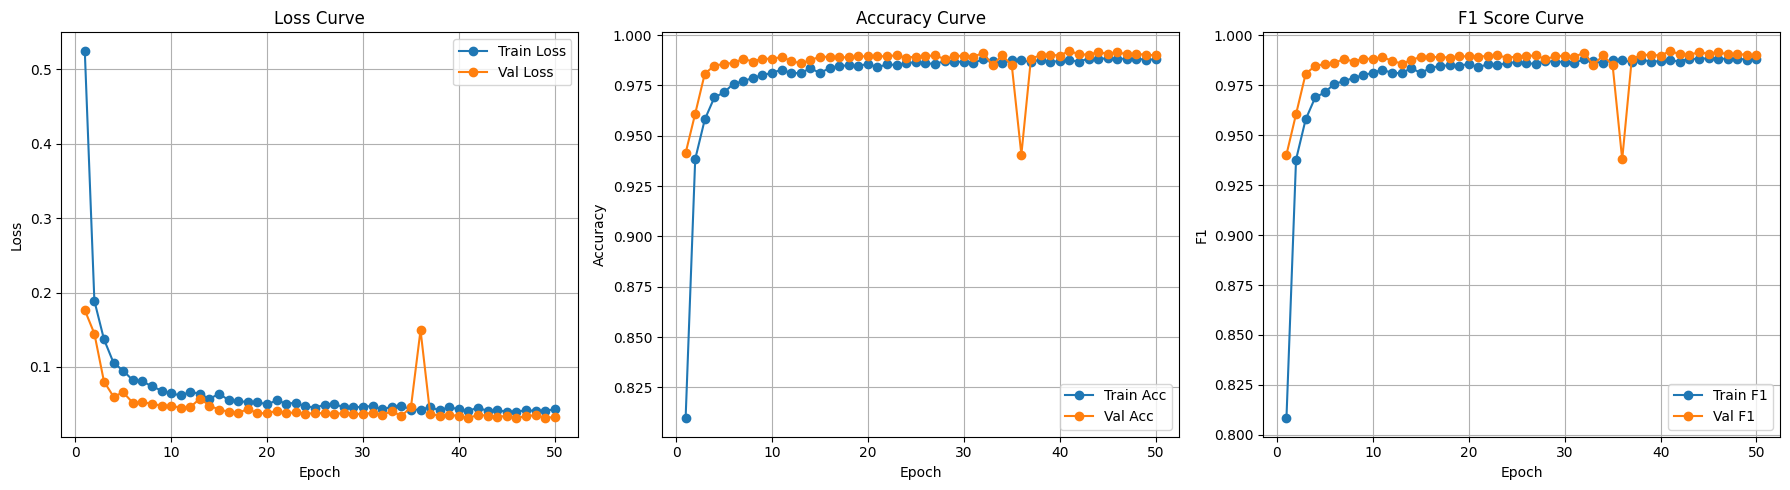

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- 1. Phân tích classes thực tế trong dataset ---
label_counts = collections.Counter()
for i in range(len(dataset_aci_full)):
    label_counts[dataset_aci_full[i].y.item()] += 1

ACTUAL_CLASSES = sorted(label_counts.keys())
NUM_CLASSES = max(ACTUAL_CLASSES) + 1  # = 9, giữ nguyên label gốc
print(f"Classes có dữ liệu: {ACTUAL_CLASSES} ({len(ACTUAL_CLASSES)} classes)")

# --- 2. Tính Class Weights ---
total_samples = sum(label_counts.values())
class_weights = torch.ones(NUM_CLASSES, device=device)
for cls_id, count in label_counts.items():
    class_weights[cls_id] = total_samples / (len(ACTUAL_CLASSES) * count)
for i in range(NUM_CLASSES):
    if i not in label_counts: class_weights[i] = 0.0
class_weights = torch.clamp(class_weights, max=50.0)

# --- 3. Model Definition (GATConv Nguyên Bản XG-NID) ---
class HeteroGNN_Edge_ACI(torch.nn.Module):
    def __init__(self, hetero_graph, args):
        super().__init__()
        self.hidden_size = args['hidden_size']
        self.node_types_sorted = sorted(hetero_graph.node_types)

        self.node_projections = nn.ModuleDict()
        for nt in hetero_graph.node_types:
            in_dim = hetero_graph[nt].x.size(-1)
            self.node_projections[nt] = nn.Linear(in_dim, self.hidden_size)

        self.convs1 = HeteroConv({
            et: GATConv((-1, -1), self.hidden_size, edge_dim=-1, add_self_loops=False) for et in hetero_graph.metadata()[1]
        })
        self.convs2 = HeteroConv({
            et: GATConv((-1, -1), self.hidden_size, edge_dim=-1, add_self_loops=False) for et in hetero_graph.metadata()[1]
        })

        self.bns1 = nn.ModuleDict()
        self.bns2 = nn.ModuleDict()
        for nt in hetero_graph.node_types:
            self.bns1[nt] = nn.BatchNorm1d(self.hidden_size, eps=1.0)
            self.bns2[nt] = nn.BatchNorm1d(self.hidden_size, eps=1.0)

        num_nt = len(hetero_graph.node_types)
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size * num_nt, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, args['num_classes'])
        )

    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = {k: self.node_projections[k](v) for k, v in node_feature.items()}

        x_out = self.convs1(x, edge_index, edge_attr)
        for k in x:
            if k not in x_out: x_out[k] = x[k]
            else: x_out[k] = x_out[k] + x[k]
        x = {k: F.leaky_relu(self.bns1[k](v)) for k, v in x_out.items()}

        x_res = x
        x_out = self.convs2(x, edge_index, edge_attr)
        for k in x_res:
            if k not in x_out: x_out[k] = x_res[k]
            else: x_out[k] = x_out[k] + x_res[k]
        x = {k: F.leaky_relu(self.bns2[k](v)) for k, v in x_out.items()}

        embs = []
        for k in self.node_types_sorted:
            bi = batch.batch_dict.get(k, None)
            if bi is not None and k in x and x[k].size(0) > 0:
                e = global_mean_pool(x[k], bi)
            else:
                e = torch.zeros(batch.num_graphs, self.hidden_size, device=next(self.parameters()).device)
            embs.append(e)

        graph_emb = torch.cat(embs, dim=1)
        return self.classifier(graph_emb)

# --- 4. DataLoader ---
train_idx, test_idx = train_test_split(
    list(range(len(dataset_aci_full))), test_size=0.2, random_state=42,
    stratify=[dataset_aci_full[i].y.item() for i in range(len(dataset_aci_full))]
)
train_loader_v8 = DataLoader(dataset_aci_full[train_idx], batch_size=128, shuffle=True)
test_loader_v8  = DataLoader(dataset_aci_full[test_idx],  batch_size=128, shuffle=False)

# --- 5. Training ---
ARGS_v8 = {'hidden_size': 64, 'epochs': 50, 'lr': 0.001, 'num_classes': NUM_CLASSES}
criterion = nn.CrossEntropyLoss(weight=class_weights)
model_v8 = HeteroGNN_Edge_ACI(dataset_aci_full[0].to(device), ARGS_v8).to(device)
optimizer_v8 = torch.optim.Adam(model_v8.parameters(), lr=ARGS_v8['lr'], weight_decay=1e-4)

def sanitize_tensor(t):
    if t is not None and t.is_floating_point():
        return torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
    return t

def run_epoch_v8(loader, train=True):
    model_v8.train() if train else model_v8.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        batch = batch.to(device)
        for k in batch.x_dict.keys():
            batch.x_dict[k] = sanitize_tensor(batch.x_dict[k])

        if train: optimizer_v8.zero_grad()
        with torch.set_grad_enabled(train):
            pred = model_v8(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            loss = criterion(pred, batch.y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_v8.parameters(), max_norm=1.0)
                optimizer_v8.step()
        total_loss += loss.item() * batch.num_graphs
        all_preds.append(pred.max(dim=1)[1].cpu().numpy())
        all_labels.append(batch.y.cpu().numpy())
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / len(loader.dataset), acc, f1, preds, labels

print("=" * 65)
print("BẮT ĐẦU TRAIN LẦN 8 (GATConv NGUYÊN BẢN + DUMMY PACKET)")
print("=" * 65)
best_f1_v8 = 0.0
history_v8 = []
MODEL_PATH = '/content/drive/MyDrive/network-attack/saved_models/xgnid_aci_payload_best_v8_GAT.pth'

for epoch in range(1, ARGS_v8['epochs'] + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch_v8(train_loader_v8, train=True)
    val_loss, val_acc, val_f1, preds_v8, labels_v8 = run_epoch_v8(test_loader_v8, train=False)

    history_v8.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
                       'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1})

    if val_f1 > best_f1_v8:
        best_f1_v8 = val_f1
        torch.save(model_v8.state_dict(), MODEL_PATH)
        print(f'Epoch {epoch:2d}/{ARGS_v8["epochs"]} | TrL:{tr_loss:.4f} TrF1:{tr_f1:.4f} | VaL:{val_loss:.4f} VaF1:{val_f1:.4f} --> [SAVE]')
    else:
        print(f'Epoch {epoch:2d}/{ARGS_v8["epochs"]} | TrL:{tr_loss:.4f} TrF1:{tr_f1:.4f} | VaL:{val_loss:.4f} VaF1:{val_f1:.4f}')

# --- 6. Vẽ Training Curve và Báo cáo ---
print("\nĐang load checkpoint tốt nhất...")
model_v8.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
_, _, _, preds_v8, labels_v8 = run_epoch_v8(test_loader_v8, train=False)

print('=' * 65)
print('KẾT QUẢ TEST - TRAIN LẦN 8')
print('=' * 65)
unique_labels = sorted(set(labels_v8) | set(preds_v8))
used_names = [CLASS_NAMES_ACI[i] for i in unique_labels if i < len(CLASS_NAMES_ACI)]
print(classification_report(labels_v8, preds_v8, labels=unique_labels,
                            target_names=used_names, digits=4, zero_division=0))

epochs_range = [h['epoch'] for h in history_v8]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(epochs_range, [h['tr_loss'] for h in history_v8], label='Train Loss', marker='o')
ax1.plot(epochs_range, [h['val_loss'] for h in history_v8], label='Val Loss', marker='o')
ax1.set_title('Loss Curve'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True); ax1.legend()

ax2.plot(epochs_range, [h['tr_acc'] for h in history_v8], label='Train Acc', marker='o')
ax2.plot(epochs_range, [h['val_acc'] for h in history_v8], label='Val Acc', marker='o')
ax2.set_title('Accuracy Curve'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(True); ax2.legend()

ax3.plot(epochs_range, [h['tr_f1'] for h in history_v8], label='Train F1', marker='o')
ax3.plot(epochs_range, [h['val_f1'] for h in history_v8], label='Val F1', marker='o')
ax3.set_title('F1 Score Curve'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('F1'); ax3.grid(True); ax3.legend()
plt.tight_layout(); plt.show()

# Detect ZERO-Day (OOD) trên tập dataset CIC


In [ ]:
# 1. TIỀN XỬ LÝ (CLEANING) DATASET CIC-IoT2023
import pandas as pd
import numpy as np
import os

DRIVE_DATA_PATH = '/content/drive/MyDrive/network-attack'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')

CLEANED_TRAIN = '/content/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/content/df_class_8_test_cleaned.csv'

def clean_author_dataset(input_csv, output_csv, samples_per_class=5000):
    print(f"Đang xử lý: {input_csv}")
    df = pd.read_csv(input_csv)
    orig_len = len(df)
    print(f"  - Số dòng ban đầu: {orig_len:,}")

    label_col = 'Label' if 'Label' in df.columns else ('label' if 'label' in df.columns else df.columns[-1])

    # 1. Khử Bias
    bias_keywords = ['ip', 'mac', 'port', 'timestamp', 'flow id']
    bias_cols = [c for c in df.columns if any(k in c.lower() for k in bias_keywords) and 'udps' not in c.lower()]
    for c in bias_cols:
        df[c] = 0.0
    print(f"  - Đã zero-out {len(bias_cols)} cột định danh: {bias_cols}")

    # 2. Lấy mẫu cân bằng (Balanced Undersampling)
    dfs = []
    for label, group in df.groupby(label_col):
        n_samples = min(samples_per_class, len(group))
        dfs.append(group.sample(n=n_samples, random_state=42))
    df_balanced = pd.concat(dfs, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)
    print(f"  - Số dòng sau khi cân bằng: {len(df_balanced):,}")

    df_balanced.to_csv(output_csv, index=False)
    print(f"  -> Đã lưu tại: {output_csv}\n")

if os.path.exists(TRAIN_CSV):
    clean_author_dataset(TRAIN_CSV, CLEANED_TRAIN, samples_per_class=20000)
    clean_author_dataset(TEST_CSV, CLEANED_TEST, samples_per_class=4000)
else:
    print("Không tìm thấy file gốc trên Drive. Vui lòng mount Google Drive trước.")

Đang xử lý: /content/drive/MyDrive/network-attack/df_class_8_train.csv
  - Số dòng ban đầu: 160,000
  - Đã zero-out 5 cột định danh: ['Unique_Ports_In_SourceDestinationIP', 'Rolling_http_port_SourceDestination', 'Rolling_http_port_Destination', 'Rolling_vulnerable_port', 'Rolling_bipackets_destination']
  - Số dòng sau khi cân bằng: 160,000
  -> Đã lưu tại: /content/df_class_8_train_cleaned.csv

Đang xử lý: /content/drive/MyDrive/network-attack/df_class_8_test.csv
  - Số dòng ban đầu: 25,557
  - Đã zero-out 5 cột định danh: ['Unique_Ports_In_SourceDestinationIP', 'Rolling_http_port_SourceDestination', 'Rolling_http_port_Destination', 'Rolling_vulnerable_port', 'Rolling_bipackets_destination']
  - Số dòng sau khi cân bằng: 25,557
  -> Đã lưu tại: /content/df_class_8_test_cleaned.csv



In [ ]:
# =========================================================================
# BƯỚC 2: KHỞI TẠO DATALOADER ĐỒ THỊ VÀ HỖ TRỢ GIẢI NÉN TỪ GOOGLE DRIVE
# =========================================================================
import os
import glob
import subprocess
import sys
import torch
import shutil

# Khắc phục lỗi PyTorch 2.6+ weights_only=True khi load đồ thị PyG
if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def patched_load(*args, **kwargs):
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return torch._orig_load(*args, **kwargs)
    torch.load = patched_load

if not os.path.exists('/content/GNN4ID'):
    print("Cloning GNN4ID...")
    subprocess.run(["git", "clone", "https://github.com/Yasir-ali-farrukh/GNN4ID.git", "/content/GNN4ID"])
if '/content/GNN4ID' not in sys.path:
    sys.path.insert(0, '/content/GNN4ID')

from Utility.Functions import NIDSDataset

DRIVE_DATA_PATH = '/content/drive/MyDrive/network-attack'
TRAIN_CSV = os.path.join(DRIVE_DATA_PATH, 'df_class_8_train.csv')
TEST_CSV  = os.path.join(DRIVE_DATA_PATH, 'df_class_8_test.csv')
GRAPH_ZIP_PATH = os.path.join(DRIVE_DATA_PATH, 'graph_objects_cleaned.zip')
GRAPH_STORE = '/content/graph_data'
CLEANED_TRAIN = '/content/df_class_8_train_cleaned.csv'
CLEANED_TEST = '/content/df_class_8_test_cleaned.csv'

os.makedirs(GRAPH_STORE + '/raw', exist_ok=True)
os.makedirs(GRAPH_STORE + '/processed', exist_ok=True)

# Bước 1: Kiểm tra xem đã có file đồ thị local chưa
already_built_train = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt')) > 1000
already_built_test  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt')) > 100

# Bước 2: Nếu chưa có local nhưng có zip của tập sạch trên Drive thì giải nén
if not (already_built_train and already_built_test):
    if os.path.exists(GRAPH_ZIP_PATH):
        print('Tìm thấy zip đồ thị SẠCH trên Drive, đang giải nén...')
        subprocess.run(['unzip', '-q', '-o', GRAPH_ZIP_PATH, '-d', '/'], check=True)
        print('Giải nén xong.')
        already_built_train = len(glob.glob(GRAPH_STORE + '/processed/data_[0-9]*.pt')) > 1000
        already_built_test  = len(glob.glob(GRAPH_STORE + '/processed/data_test_*.pt')) > 100
    else:
        print('Không tìm thấy file zip đồ thị sạch trên Drive. Sẽ xây dựng mới đồ thị sạch từ CSV cleaned.')

skip = already_built_train and already_built_test
print(f'Graph objects sẵn sàng: train={already_built_train}, test={already_built_test}')
print(f'→ {"Sử dụng đồ thị sạch có sẵn từ Google Drive (skip building)" if skip else "Xây dựng mới đồ thị sạch từ CSV (mất ~1-2 giờ)"}')

LABEL_DICT = {
    'Benign': 0,
    'WebBased': 1,
    'Spoofing': 2,
    'Recon': 3,
    'Mirai': 4,
    'Dos': 5,
    'DDos': 6,
    'BruteForce': 7,
}

print('Đang nạp tập train dataset đồ thị...')
train_dataset_full = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TRAIN], # Luôn đọc từ file đã làm sạch để đồng bộ nhãn
    skip_processing=skip,
    test=False,
    single_file=True,
)

print('Đang nạp tập test dataset đồ thị...')
test_dataset_full = NIDSDataset(
    root=GRAPH_STORE,
    label_dict=LABEL_DICT,
    filename=[CLEANED_TEST], # Luôn đọc từ file đã làm sạch để đồng bộ nhãn
    skip_processing=skip,
    test=True,
    single_file=True,
)

# Bước 3: Nếu vừa tự xây dựng mới đồ thị sạch thành công (không skip), tiến hành nén và lưu lên Drive để tái sử dụng
if not skip:
    print('Đang nén và lưu trữ bộ đồ thị sạch lên Google Drive...')
    shutil.make_archive('/content/graph_objects_cleaned', 'zip', root_dir='/', base_dir='content/graph_data')
    shutil.copy('/content/graph_objects_cleaned.zip', GRAPH_ZIP_PATH)
    print(f'[OK] Đã lưu trữ bộ đồ thị sạch tại: {GRAPH_ZIP_PATH}')

print(f"\n[OK] Đồ thị sẵn sàng! Train: {len(train_dataset_full):,}, Test: {len(test_dataset_full):,}\n")

Graph objects sẵn sàng: train=True, test=True
→ Sử dụng đồ thị sạch có sẵn từ Google Drive (skip building)
Đang nạp tập train dataset đồ thị...
Đang nạp tập test dataset đồ thị...

[OK] Đồ thị sẵn sàng! Train: 73,122, Test: 11,698



In [ ]:
# =========================================================================
# BƯỚC 3: XÂY DỰNG DATASET CLASS VÀ KHỞI TẠO KIẾN TRÚC GNN
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.nn import HeteroConv, GATConv, global_mean_pool
import glob
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Khắc phục lỗi PyTorch 2.6+ weights_only=True khi load đồ thị PyG
import torch
if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
    def patched_load(*args, **kwargs):
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return torch._orig_load(*args, **kwargs)
    torch.load = patched_load

# --- 1. Định nghĩa Wrapper Dataset để lọc và map nhãn động trong RAM ---
class LabelMappingDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, hidden_class):
        self.base_dataset = base_dataset
        self.indices = indices
        self.hidden_class = hidden_class

        self.old_to_new = {}
        new_label = 0
        for old_label in range(8):
            if old_label == hidden_class: continue
            self.old_to_new[old_label] = new_label
            new_label += 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        data = self.base_dataset[real_idx].clone()
        old_y = data.y.item()

        # Nếu nhãn cũ thuộc lớp ẩn (OOD), ta giữ nguyên (không map),
        # vì trong bài toán phân loại ID, mẫu này sẽ không được đưa vào.
        if old_y in self.old_to_new:
            data.y = torch.tensor([self.old_to_new[old_y]], dtype=torch.long)
        return data

# --- 2. Định nghĩa kiến trúc GNN (Trích xuất Embedding ở lớp classifier) ---
class HeteroGNN_Edge_CIC_OOD(torch.nn.Module):
    def __init__(self, sample_graph, hidden_size=64, num_classes=7):
        super().__init__()
        self.hidden_size = hidden_size
        self.node_types_sorted = sorted(sample_graph.node_types)

        self.node_projections = nn.ModuleDict({
            nt: nn.Linear(sample_graph[nt].x.size(1), hidden_size)
            for nt in self.node_types_sorted
        })

        conv_dict1 = {}
        for et in sample_graph.edge_types:
            ea = sample_graph[et].edge_attr
            ed = 1 if ea.dim() == 1 else ea.size(1)
            conv_dict1[et] = GATConv(
                (-1, -1),
                hidden_size,
                edge_dim=ed,
                add_self_loops=False
            )
        self.convs1 = HeteroConv(conv_dict1, aggr='sum')
        self.bns1 = nn.ModuleDict({nt: nn.BatchNorm1d(hidden_size) for nt in self.node_types_sorted})
        self.relus1 = nn.ModuleDict({nt: nn.ReLU() for nt in self.node_types_sorted})

        conv_dict2 = {}
        for et in sample_graph.edge_types:
            ea = sample_graph[et].edge_attr
            ed = 1 if ea.dim() == 1 else ea.size(1)
            conv_dict2[et] = GATConv(
                (-1, -1),
                hidden_size,
                edge_dim=ed,
                add_self_loops=False
            )
        self.convs2 = HeteroConv(conv_dict2, aggr='sum')
        self.bns2 = nn.ModuleDict({nt: nn.BatchNorm1d(hidden_size) for nt in self.node_types_sorted})
        self.relus2 = nn.ModuleDict({nt: nn.ReLU() for nt in self.node_types_sorted})

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * len(self.node_types_sorted), hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, node_feature, edge_index, edge_attr, batch):
        x = {k: self.node_projections[k](v.float()) for k, v in node_feature.items()}

        # Đảm bảo edge_attr luôn 2D để tránh lỗi kích thước của GATConv
        edge_attr_2d = {}
        for et, ea in edge_attr.items():
            if getattr(ea, 'dim', lambda: 0)() == 1:
                edge_attr_2d[et] = ea.unsqueeze(-1)
            else:
                edge_attr_2d[et] = ea

        x_out = self.convs1(x, edge_index, edge_attr_2d)
        for k in x:
            if k not in x_out: x_out[k] = x[k]
            else: x_out[k] = x_out[k] + x[k]
        x = {k: self.relus1[k](self.bns1[k](v)) for k, v in x_out.items()}

        x_res = x
        x_out = self.convs2(x, edge_index, edge_attr_2d)
        for k in x_res:
            if k not in x_out: x_out[k] = x_res[k]
            else: x_out[k] = x_out[k] + x_res[k]
        x = {k: self.relus2[k](self.bns2[k](v)) for k, v in x_out.items()}

        embs = []
        for k in self.node_types_sorted:
            bi = batch.batch_dict.get(k, None)
            if bi is not None and k in x and x[k].size(0) > 0:
                e = global_mean_pool(x[k], bi)
            else:
                e = torch.zeros(batch.num_graphs, self.hidden_size, device=next(self.parameters()).device)
            embs.append(e)

        graph_emb = torch.cat(embs, dim=1)
        pred = self.classifier(graph_emb)
        return F.log_softmax(pred, dim=1)

print("Đang quét nhãn toàn bộ dataset từ CSV để tối ưu hóa thời gian (tránh load từng đồ thị từ đĩa)...")
skip = len(glob.glob('/content/graph_data/processed/data_[0-9]*.pt')) > 1000
train_csv_path = CLEANED_TRAIN # Luôn đọc từ file đã làm sạch để đồng bộ nhãn
test_csv_path  = CLEANED_TEST # Luôn đọc từ file đã làm sạch để đồng bộ nhãn

train_df_labels = pd.read_csv(train_csv_path, usecols=['Label'])
test_df_labels  = pd.read_csv(test_csv_path, usecols=['Label'])

# Nhãn trong CSV có thể là số nguyên (0-7) hoặc chuỗi ('Benign', 'WebBased',...)
# Kiểm tra dtype để xử lý đúng cách
if train_df_labels['Label'].dtype == 'object':  # Chuỗi
    train_labels = train_df_labels['Label'].map(LABEL_DICT).astype(int).tolist()
    test_labels  = test_df_labels['Label'].map(LABEL_DICT).astype(int).tolist()
else:  # Đã là số nguyên
    train_labels = train_df_labels['Label'].astype(int).tolist()
    test_labels  = test_df_labels['Label'].astype(int).tolist()
print(f"Quét nhãn xong! Train labels: {len(train_labels):,}, Test labels: {len(test_labels):,}")
print(f"  Phân bố nhãn train: {dict(pd.Series(train_labels).value_counts().sort_index())}")

Device: cuda
Đang quét nhãn toàn bộ dataset từ CSV để tối ưu hóa thời gian (tránh load từng đồ thị từ đĩa)...
Quét nhãn xong! Train labels: 160,000, Test labels: 25,557
  Phân bố nhãn train: {0: np.int64(20000), 1: np.int64(20000), 2: np.int64(20000), 3: np.int64(20000), 4: np.int64(20000), 5: np.int64(20000), 6: np.int64(20000), 7: np.int64(20000)}


In [ ]:
# =========================================================================
# BƯỚC 4: VÒNG LẶP HUẤN LUYỆN LEAVE-ONE-OUT (LOO-CV) & ĐÁNH GIÁ MAHALANOBIS
# =========================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve
from torch.utils.data import Subset
import os

ATTACK_CLASSES = {
    1: 'WebBased',
    2: 'Spoofing',
    3: 'Recon',
    4: 'Mirai',
    5: 'Dos',
    6: 'DDos',
    7: 'BruteForce'
}

# Cấu hình lấy mẫu để tăng tốc huấn luyện (nếu dùng dataset full 140k mẫu train ID)
USE_SUBSET = True  # Đặt thành False để huấn luyện trên toàn bộ dữ liệu gốc (140k train ID)
SUBSET_SIZE_PER_CLASS = 5000  # Số mẫu huấn luyện tối đa cho mỗi lớp ID

loop_metrics = {}
EPOCHS_PER_FOLD = 15
BATCH_SIZE = 128

for hidden_class, name in ATTACK_CLASSES.items():
    print("=" * 75)
    print(f"VÒNG LẶP: Ẩn lớp Tấn công '{name}' (Label {hidden_class}) để làm Zero-Day")
    print("=" * 75)

    train_id_idx_all = [idx for idx, l in enumerate(train_labels) if l != hidden_class]
    test_id_idx_all  = [idx for idx, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx     = [idx for idx, l in enumerate(test_labels) if l == hidden_class]

    if USE_SUBSET:
        # Lấy mẫu cân bằng cho tập train
        np.random.seed(42)
        train_id_idx = []
        train_labels_np = np.array(train_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(train_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(SUBSET_SIZE_PER_CLASS, len(class_indices)), replace=False)
                train_id_idx.extend(sampled.tolist())

        # Lấy mẫu cân bằng cho tập test ID (để đo khoảng cách Mahalanobis nhanh hơn)
        test_id_idx = []
        test_labels_np = np.array(test_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(test_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(2000, len(class_indices)), replace=False)
                test_id_idx.extend(sampled.tolist())
    else:
        train_id_idx = train_id_idx_all
        test_id_idx  = test_id_idx_all

    print(f"  - Train ID  : {len(train_id_idx):,} mẫu" + (f" (đã lấy mẫu từ {len(train_id_idx_all):,} mẫu)" if USE_SUBSET else ""))
    print(f"  - Test ID   : {len(test_id_idx):,} mẫu" + (f" (đã lấy mẫu từ {len(test_id_idx_all):,} mẫu)" if USE_SUBSET else ""))
    print(f"  - Test OOD  : {len(test_ood_idx):,} mẫu (Zero-Day '{name}')")

    train_mapped = LabelMappingDataset(train_dataset_full, train_id_idx, hidden_class)
    test_id_mapped = LabelMappingDataset(test_dataset_full, test_id_idx, hidden_class)

    # Tối ưu hóa Dataloader: sử dụng num_workers=2 để tải song song và pin_memory=True để truyền GNN nhanh hơn
    train_loader = DataLoader(train_mapped, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_id_loader = DataLoader(test_id_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    def run_fold_epoch(loader, train=True):
        model.train() if train else model.eval()
        total_loss = 0.0
        for batch in loader:
            batch = batch.to(device)
            if train: optimizer.zero_grad()
            with torch.set_grad_enabled(train):
                pred = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
                loss = F.nll_loss(pred, batch.y)
                if train:
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        return total_loss / len(loader.dataset)

    print(f"  - Đang train GNN trên 7 lớp ID còn lại...")
    for epoch in range(1, EPOCHS_PER_FOLD + 1):
        loss_val = run_fold_epoch(train_loader, train=True)
        if epoch % 5 == 0 or epoch == EPOCHS_PER_FOLD:
            print(f"    Epoch {epoch:2d}/{EPOCHS_PER_FOLD} | Train Loss: {loss_val:.4f}")

    # Đánh giá độ chính xác phân loại các lớp đã biết (ID Accuracy)
    model.eval()
    correct_id = 0
    total_id = 0
    with torch.no_grad():
        for batch in test_id_loader:
            batch = batch.to(device)
            pred = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            preds = pred.max(dim=1)[1]
            correct_id += preds.eq(batch.y).sum().item()
            total_id += batch.num_graphs
    id_acc = correct_id / total_id if total_id > 0 else 0.0
    print(f"  -> Accuracy phân loại ID của GNN: {id_acc:.4f}")

    # Hook trích xuất embeddings
    graph_embs_dict = {}
    def get_activation(name_hook):
        def hook(model, input, output):
            graph_embs_dict[name_hook] = input[0].detach()
        return hook

    hook_handle = model.classifier.register_forward_hook(get_activation('emb'))
    model.eval()

    print("  - Đang phân cụm embeddings của 7 lớp ID...")
    class_embs = {c: [] for c in range(7)}
    with torch.no_grad():
        for batch in test_id_loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            batch_embs = graph_embs_dict['emb'].cpu().numpy()
            batch_ys = batch.y.cpu().numpy()
            for c in range(7):
                mask = (batch_ys == c)
                if mask.sum() > 0:
                    class_embs[c].append(batch_embs[mask])

    class_means = {}
    centered_embs = []
    for c in range(7):
        if len(class_embs[c]) > 0:
            stacked = np.vstack(class_embs[c])
            mu = np.mean(stacked, axis=0)
            class_means[c] = mu
            centered_embs.append(stacked - mu)

    all_centered = np.vstack(centered_embs)
    cov = np.cov(all_centered, rowvar=False)
    cov += np.eye(cov.shape[0]) * 1e-4
    inv_cov = np.linalg.inv(cov)

    def compute_min_mahalanobis(embs, means, inv_cov_mat):
        scores = []
        for emb in embs:
            dists = []
            for c, mu in means.items():
                diff = emb - mu
                d = np.sqrt(np.dot(np.dot(diff, inv_cov_mat), diff))
                dists.append(d)
            scores.append(np.min(dists))
        return np.array(scores)

    id_embs = []
    with torch.no_grad():
        for batch in test_id_loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            id_embs.append(graph_embs_dict['emb'].cpu().numpy())
    id_embs = np.vstack(id_embs)
    id_scores = compute_min_mahalanobis(id_embs, class_means, inv_cov)

    print("  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...")
    ood_subset = Subset(test_dataset_full, test_ood_idx)
    ood_loader = DataLoader(ood_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    ood_embs = []
    with torch.no_grad():
        for batch in ood_loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            ood_embs.append(graph_embs_dict['emb'].cpu().numpy())
    ood_embs = np.vstack(ood_embs)
    ood_scores = compute_min_mahalanobis(ood_embs, class_means, inv_cov)

    hook_handle.remove()

    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])

    auroc = roc_auc_score(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auprc = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]

    print(f"  -> KẾT QUẢ FOLD: AUROC = {auroc:.4f} | AUPRC = {auprc:.4f} | FPR95 = {fpr95:.4f}")
    loop_metrics[name] = {'auroc': auroc, 'auprc': auprc, 'fpr95': fpr95, 'id_acc': id_acc}

    # Tự động lưu mô hình và bộ tâm về Google Drive
    save_dir = '/content/drive/MyDrive/network-attack/saved_models_loo'
    os.makedirs(save_dir, exist_ok=True)

    model_save_path = os.path.join(save_dir, f'model_loo_fold_{name}.pth')
    torch.save(model.state_dict(), model_save_path)

    centroids_save_path = os.path.join(save_dir, f'centroids_loo_fold_{name}.pth')
    torch.save({
        'class_means': class_means,
        'inv_cov': inv_cov
    }, centroids_save_path)

    print(f"  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold '{name}' về Google Drive.\n")

print("[OK] Huấn luyện xong 7 folds!")

VÒNG LẶP: Ẩn lớp Tấn công 'WebBased' (Label 1) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 12,467 mẫu (đã lấy mẫu từ 24,467 mẫu)
  - Test OOD  : 1,090 mẫu (Zero-Day 'WebBased')
  - Đang train GNN trên 7 lớp ID còn lại...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


    Epoch  5/15 | Train Loss: 0.0856
    Epoch 10/15 | Train Loss: 0.0627
    Epoch 15/15 | Train Loss: 0.0576
  -> Accuracy phân loại ID của GNN: 0.9726
  - Đang phân cụm embeddings của 7 lớp ID...
  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...
  -> KẾT QUẢ FOLD: AUROC = 0.8365 | AUPRC = 0.2485 | FPR95 = 0.3420
  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold 'WebBased' về Google Drive.

VÒNG LẶP: Ẩn lớp Tấn công 'Spoofing' (Label 2) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 11,557 mẫu (đã lấy mẫu từ 21,557 mẫu)
  - Test OOD  : 4,000 mẫu (Zero-Day 'Spoofing')
  - Đang train GNN trên 7 lớp ID còn lại...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


    Epoch  5/15 | Train Loss: 0.1206
    Epoch 10/15 | Train Loss: 0.1014
    Epoch 15/15 | Train Loss: 0.0873
  -> Accuracy phân loại ID của GNN: 0.9574
  - Đang phân cụm embeddings của 7 lớp ID...
  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...
  -> KẾT QUẢ FOLD: AUROC = 0.8895 | AUPRC = 0.6592 | FPR95 = 0.2279
  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold 'Spoofing' về Google Drive.

VÒNG LẶP: Ẩn lớp Tấn công 'Recon' (Label 3) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 11,557 mẫu (đã lấy mẫu từ 21,557 mẫu)
  - Test OOD  : 4,000 mẫu (Zero-Day 'Recon')
  - Đang train GNN trên 7 lớp ID còn lại...


...

    Epoch  5/15 | Train Loss: 0.1801
    Epoch 10/15 | Train Loss: 0.1441
    Epoch 15/15 | Train Loss: 0.1279
  -> Accuracy phân loại ID của GNN: 0.9343
  - Đang phân cụm embeddings của 7 lớp ID...
  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...
  -> KẾT QUẢ FOLD: AUROC = 0.5843 | AUPRC = 0.2832 | FPR95 = 0.5314
  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold 'Dos' về Google Drive.

VÒNG LẶP: Ẩn lớp Tấn công 'DDos' (Label 6) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 11,557 mẫu (đã lấy mẫu từ 21,557 mẫu)
  - Test OOD  : 4,000 mẫu (Zero-Day 'DDos')
  - Đang train GNN trên 7 lớp ID còn lại...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


    Epoch  5/15 | Train Loss: 0.2033
    Epoch 10/15 | Train Loss: 0.1549
    Epoch 15/15 | Train Loss: 0.1474
  -> Accuracy phân loại ID của GNN: 0.9337
  - Đang phân cụm embeddings của 7 lớp ID...
  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...
  -> KẾT QUẢ FOLD: AUROC = 0.9967 | AUPRC = 0.9626 | FPR95 = 0.0026
  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold 'DDos' về Google Drive.

VÒNG LẶP: Ẩn lớp Tấn công 'BruteForce' (Label 7) để làm Zero-Day
  - Train ID  : 35,000 mẫu (đã lấy mẫu từ 140,000 mẫu)
  - Test ID   : 13,090 mẫu (đã lấy mẫu từ 25,090 mẫu)
  - Test OOD  : 467 mẫu (Zero-Day 'BruteForce')
  - Đang train GNN trên 7 lớp ID còn lại...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


    Epoch  5/15 | Train Loss: 0.1786
    Epoch 10/15 | Train Loss: 0.1602
    Epoch 15/15 | Train Loss: 0.1302
  -> Accuracy phân loại ID của GNN: 0.9455
  - Đang phân cụm embeddings của 7 lớp ID...
  - Đang đo đạc khoảng cách bất thường cho tập OOD (Zero-day)...
  -> KẾT QUẢ FOLD: AUROC = 0.9290 | AUPRC = 0.3322 | FPR95 = 0.2499
  -> [ĐÃ LƯU] Đã lưu model và centroids cho fold 'BruteForce' về Google Drive.

[OK] Huấn luyện xong 7 folds!


KẾT QUẢ TỔNG HỢP LEAVE-ONE-OUT ZERO-DAY (OOD) DETECTION
-------------------------------------------------------------------------------------
Attack Class (Zero-Day)   |  GNN ID Acc  |   AUROC    |   AUPRC    | FPR@95TPR 
--------------------------------------------------------------------------------
WebBased                  |    0.9726    |   0.8365   |   0.2485   |   0.3420  
Spoofing                  |    0.9574    |   0.8895   |   0.6592   |   0.2279  
Recon                     |    0.9720    |   0.7323   |   0.3743   |   0.6300  
Mirai                     |    0.9454    |   0.9908   |   0.9224   |   0.0114  
Dos                       |    0.9343    |   0.5843   |   0.2832   |   0.5314  
DDos                      |    0.9337    |   0.9967   |   0.9626   |   0.0026  
BruteForce                |    0.9455    |   0.9290   |   0.3322   |   0.2499  
--------------------------------------------------------------------------------
TRUNG BÌNH CỘNG (AVERAGE) |    0.9516    |   0.8513   | 

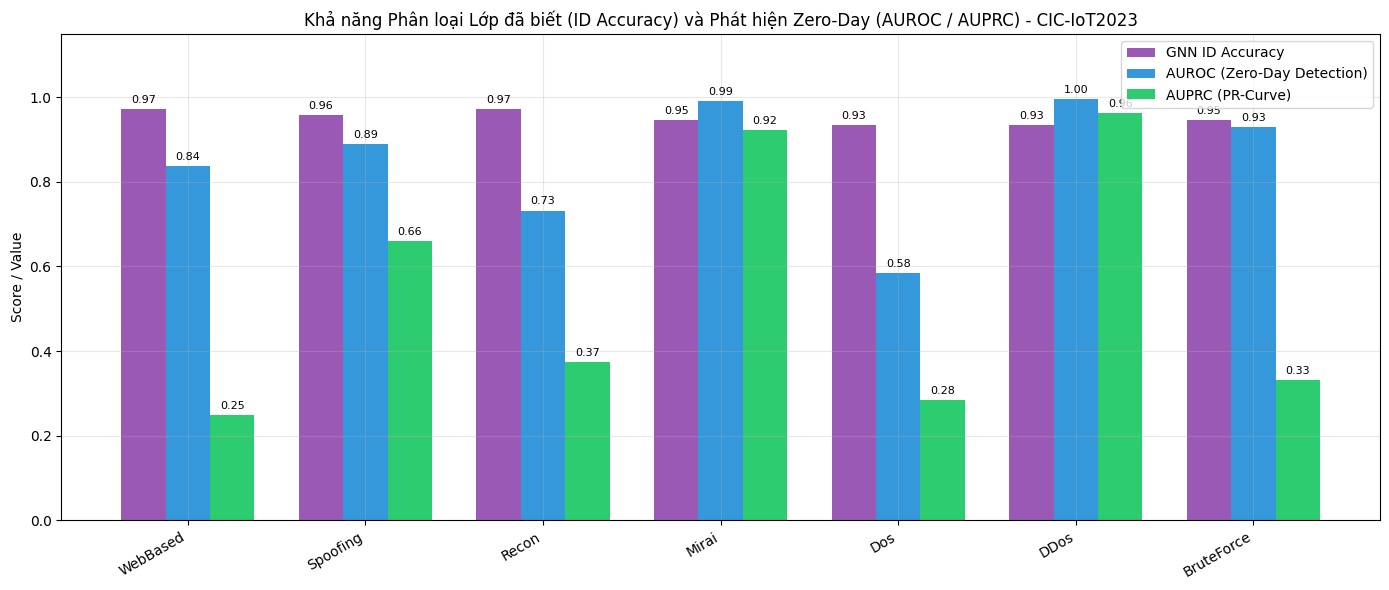

In [ ]:
# BƯỚC 5: BÁO CÁO CHI TIẾT VÀ VẼ BIỂU ĐỒ SO SÁNH CÁC FOLDS (LƯU DRIVE)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("KẾT QUẢ TỔNG HỢP LEAVE-ONE-OUT ZERO-DAY (OOD) DETECTION")
print("-" * 85)
print(f"{'Attack Class (Zero-Day)':<25} | {'GNN ID Acc':^12} | {'AUROC':^10} | {'AUPRC':^10} | {'FPR@95TPR':^10}")
print("-" * 80)

id_accs, aurocs, auprcs, fpr95s = [], [], [], []
for name, metrics in loop_metrics.items():
    print(f"{name:<25} | {metrics['id_acc']:^12.4f} | {metrics['auroc']:^10.4f} | {metrics['auprc']:^10.4f} | {metrics['fpr95']:^10.4f}")
    id_accs.append(metrics['id_acc'])
    aurocs.append(metrics['auroc'])
    auprcs.append(metrics['auprc'])
    fpr95s.append(metrics['fpr95'])

print("-" * 80)
print(f"{'TRUNG BÌNH CỘNG (AVERAGE)':<25} | {np.mean(id_accs):^12.4f} | {np.mean(aurocs):^10.4f} | {np.mean(auprcs):^10.4f} | {np.mean(fpr95s):^10.4f}")
print("=" * 85)

# Xuất file báo cáo số liệu CSV về Google Drive
df_report = pd.DataFrame.from_dict(loop_metrics, orient='index')
df_report.loc['AVERAGE'] = [np.mean(aurocs), np.mean(auprcs), np.mean(fpr95s), np.mean(id_accs)]
report_path = '/content/drive/MyDrive/network-attack/loo_metrics_report.csv'
df_report.to_csv(report_path)
print(f"\n[OK] Đã xuất file báo cáo số liệu CSV về Google Drive thành công tại:\n  {report_path}")

# Vẽ biểu đồ so sánh
classes = list(loop_metrics.keys())
x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width, [loop_metrics[c]['id_acc'] for c in classes], width, label='GNN ID Accuracy', color='#9b59b6')
rects2 = ax.bar(x, [loop_metrics[c]['auroc'] for c in classes], width, label='AUROC (Zero-Day Detection)', color='#3498db')
rects3 = ax.bar(x + width, [loop_metrics[c]['auprc'] for c in classes], width, label='AUPRC (PR-Curve)', color='#2ecc71')

ax.set_ylabel('Score / Value')
ax.set_title('Khả năng Phân loại Lớp đã biết (ID Accuracy) và Phát hiện Zero-Day (AUROC / AUPRC) - CIC-IoT2023')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


  Đang vẽ t-SNE cho Fold: Ẩn 'WebBased' (Label 1)
  Đang chạy t-SNE trên 1500 mẫu ID + 1000 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


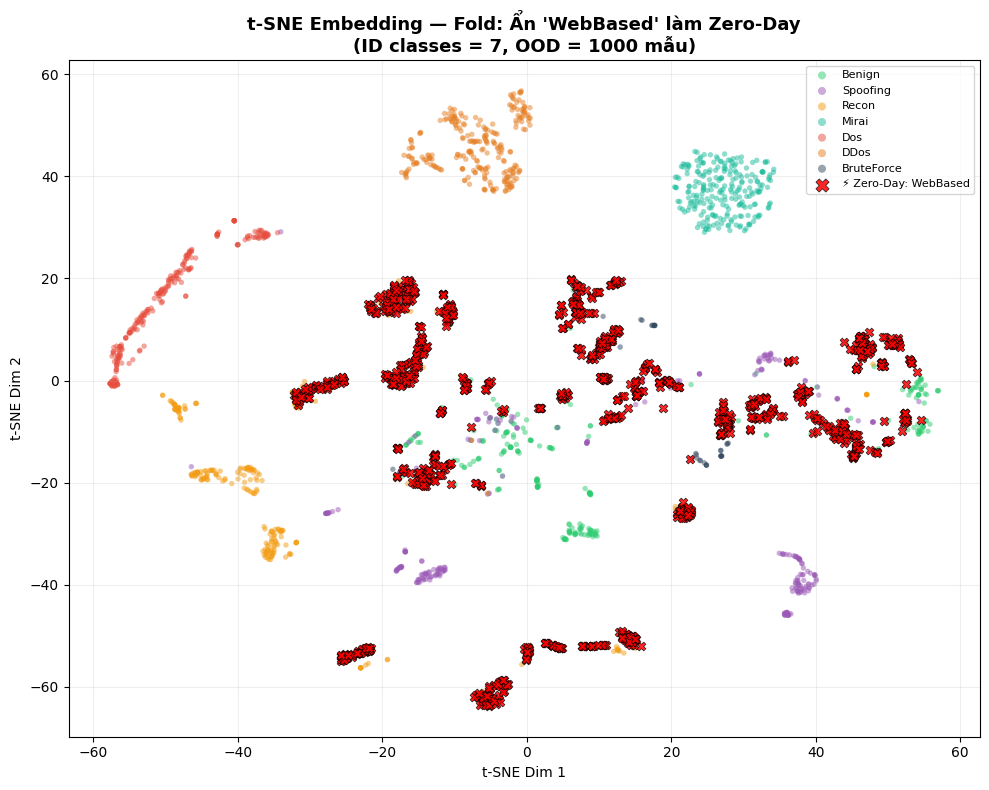

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_WebBased.png

  Đang vẽ t-SNE cho Fold: Ẩn 'Spoofing' (Label 2)
  Đang chạy t-SNE trên 1500 mẫu ID + 1000 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


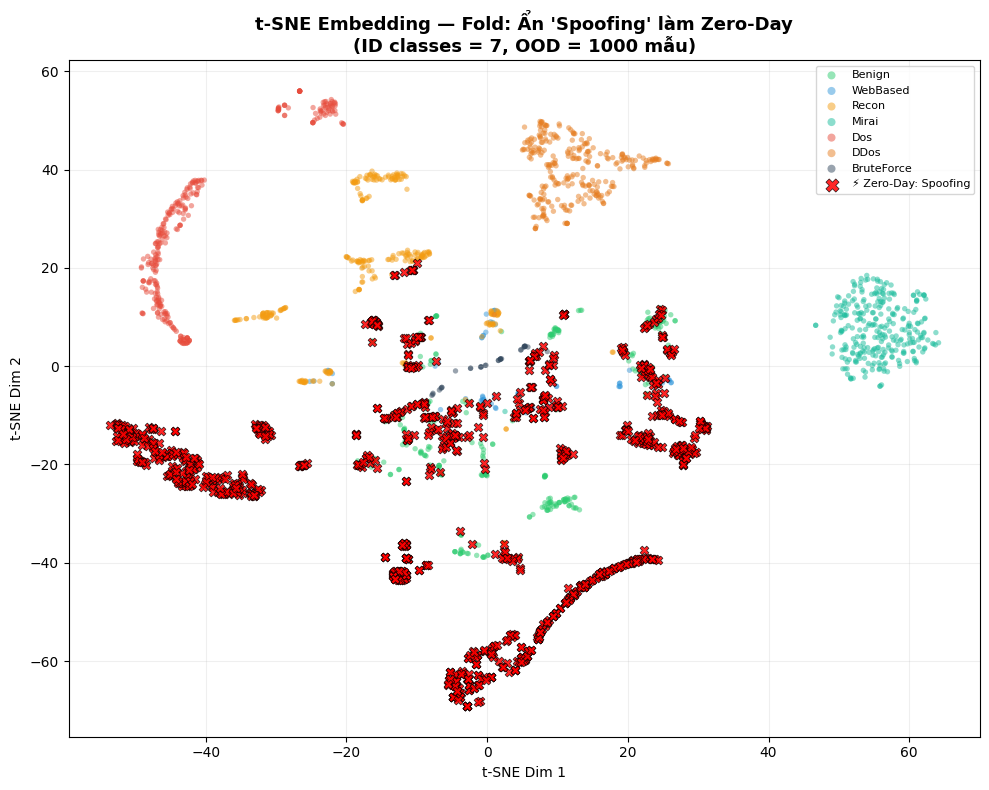

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_Spoofing.png

  Đang vẽ t-SNE cho Fold: Ẩn 'Recon' (Label 3)
  Đang chạy t-SNE trên 1500 mẫu ID + 1000 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


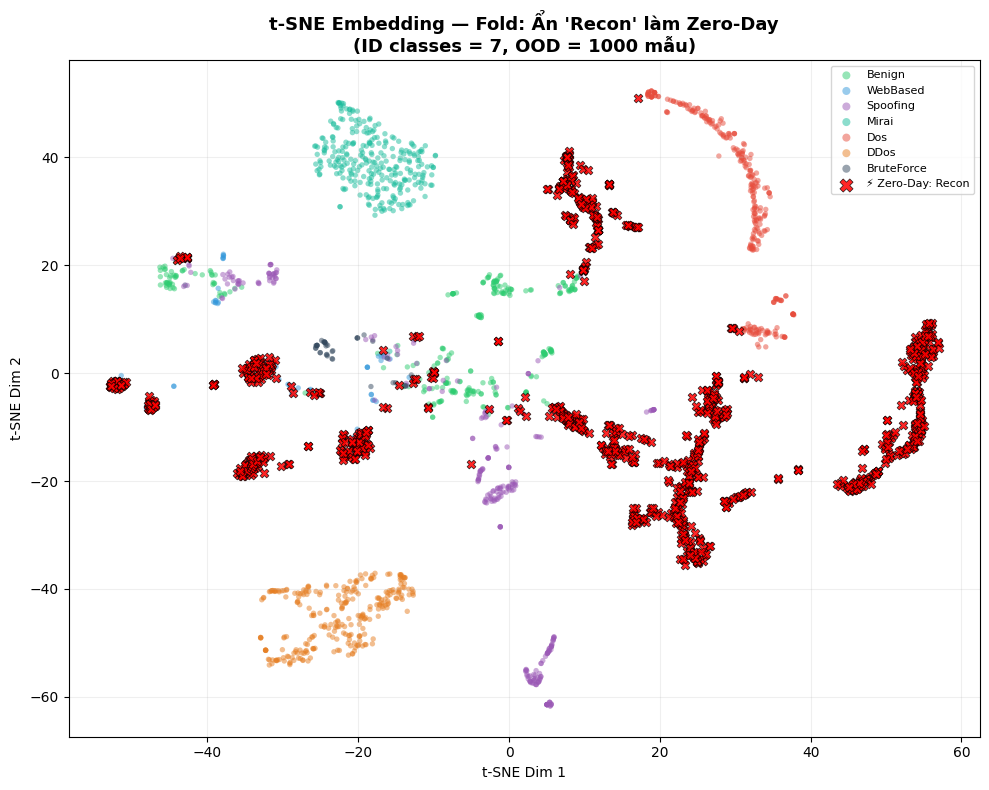

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_Recon.png

  Đang vẽ t-SNE cho Fold: Ẩn 'Mirai' (Label 4)
  Đang chạy t-SNE trên 1500 mẫu ID + 1000 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


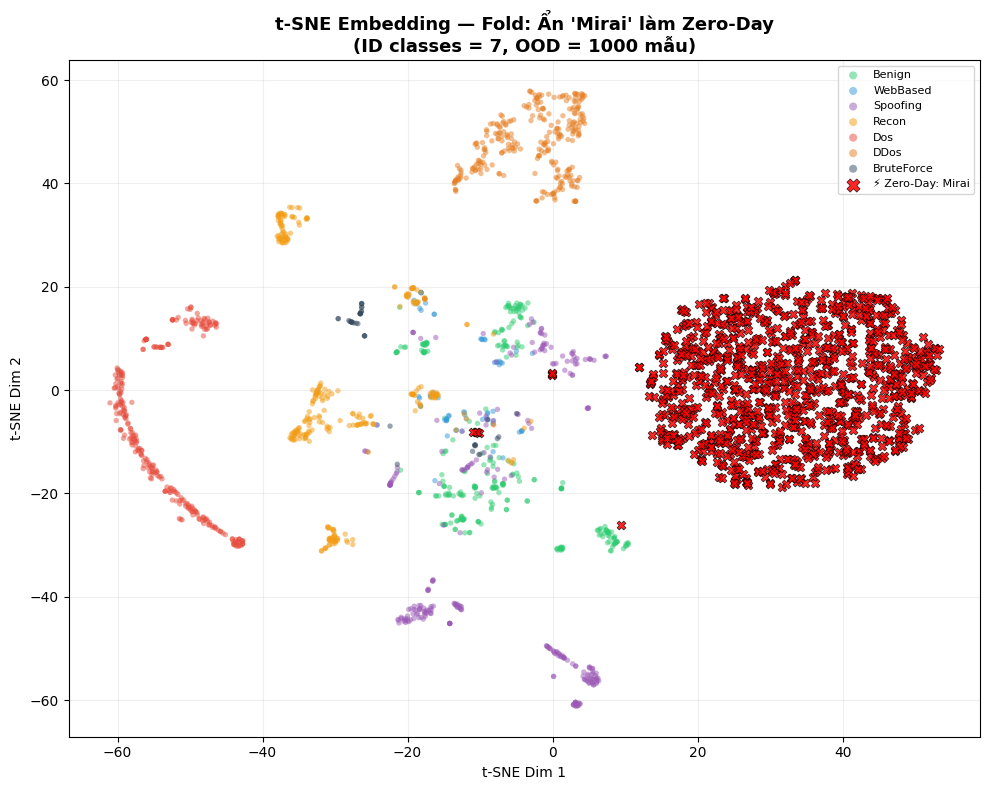

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_Mirai.png

  Đang vẽ t-SNE cho Fold: Ẩn 'Dos' (Label 5)
  Đang chạy t-SNE trên 1500 mẫu ID + 1000 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


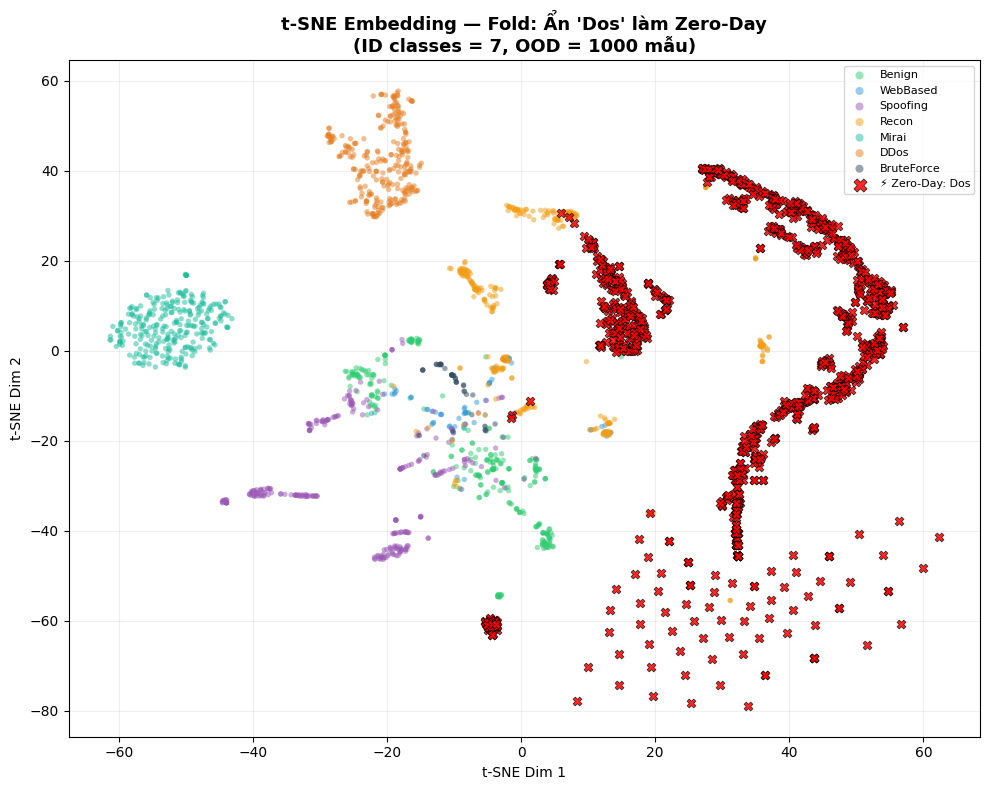

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_Dos.png

  Đang vẽ t-SNE cho Fold: Ẩn 'DDos' (Label 6)
  Đang chạy t-SNE trên 1500 mẫu ID + 1000 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


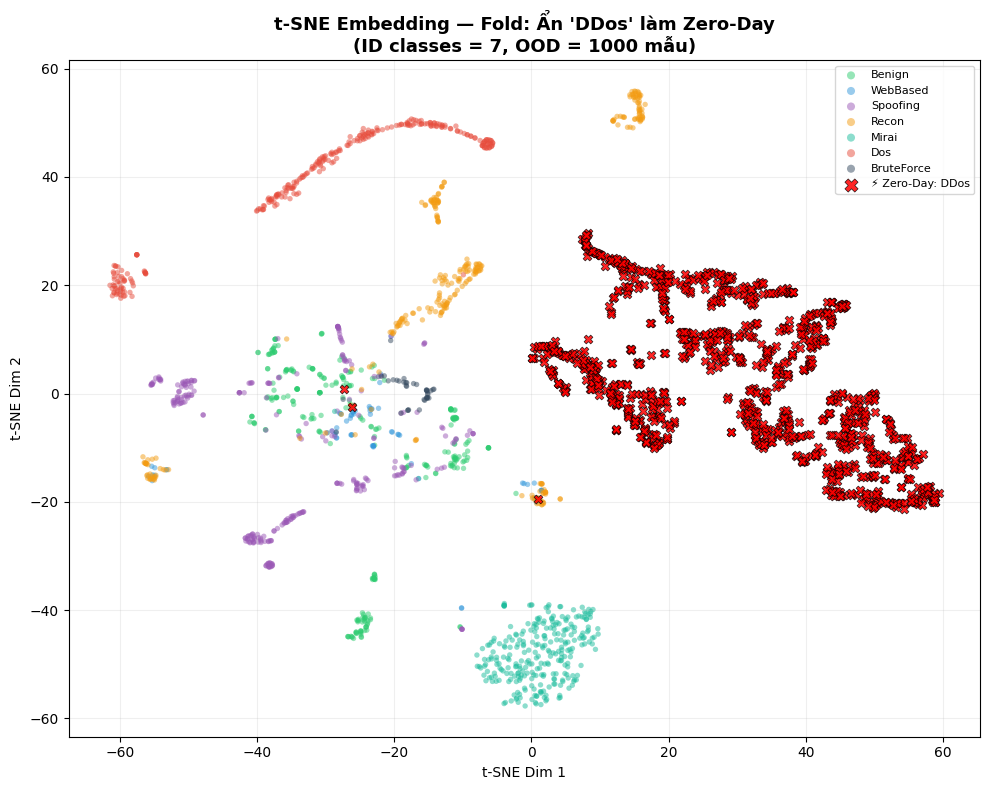

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_DDos.png

  Đang vẽ t-SNE cho Fold: Ẩn 'BruteForce' (Label 7)
  Đang chạy t-SNE trên 1500 mẫu ID + 467 mẫu OOD...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


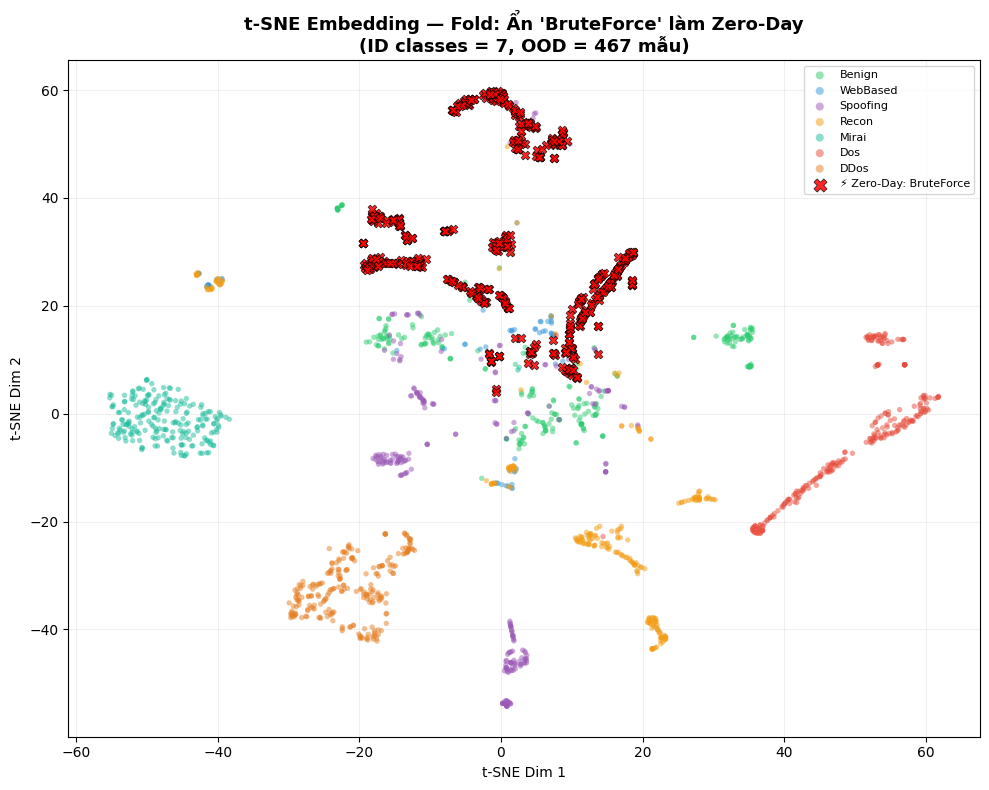

  [OK] Đã lưu hình tại: /content/drive/MyDrive/network-attack/viz_tsne/tsne_fold_BruteForce.png

------------------------------------------------------------
  ĐÃ VẼ XONG 7 HÌNH t-SNE! Lưu tại: /content/drive/MyDrive/network-attack/viz_tsne


In [ ]:
# =========================================================================
# BƯỚC 6: TRỰC QUAN HÓA KHÔNG GIAN EMBEDDING (t-SNE) CHO 7 FOLDS
# =========================================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Subset

SAVE_DIR = '/content/drive/MyDrive/network-attack/saved_models_loo'
VIZ_DIR  = '/content/drive/MyDrive/network-attack/viz_tsne'
os.makedirs(VIZ_DIR, exist_ok=True)

# Bảng màu cho 8 lớp (0=Benign, 1-7=Attacks)
CLASS_NAMES = {0:'Benign', 1:'WebBased', 2:'Spoofing', 3:'Recon',
               4:'Mirai',  5:'Dos',      6:'DDos',     7:'BruteForce'}
CLASS_COLORS = {
    0: '#2ecc71',  # Xanh lá - Benign
    1: '#3498db',  # Xanh dương - WebBased
    2: '#9b59b6',  # Tím - Spoofing
    3: '#f39c12',  # Cam - Recon
    4: '#1abc9c',  # Ngọc lam - Mirai
    5: '#e74c3c',  # Đỏ - Dos
    6: '#e67e22',  # Cam đậm - DDos
    7: '#34495e',  # Xám đen - BruteForce
}
OOD_COLOR = '#ff0000'  # Đỏ tươi cho Zero-Day

ATTACK_CLASSES = {1:'WebBased', 2:'Spoofing', 3:'Recon',
                  4:'Mirai',    5:'Dos',      6:'DDos', 7:'BruteForce'}

for hidden_class, name in ATTACK_CLASSES.items():
    print(f"\n{'='*60}")
    print(f"  Đang vẽ t-SNE cho Fold: Ẩn '{name}' (Label {hidden_class})")
    print(f"{'='*60}")

    # --- 1. Load model đã lưu ---
    model_path = os.path.join(SAVE_DIR, f'model_loo_fold_{name}.pth')
    if not os.path.exists(model_path):
        print(f"  [SKIP] Không tìm thấy model tại {model_path}")
        continue

    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)
    model.load_state_dict(torch.load(model_path, weights_only=False))
    model.eval()

    # --- 2. Đăng ký hook trích xuất embedding ---
    emb_store = {}
    def get_act(n):
        def hook(mod, inp, out):
            emb_store[n] = inp[0].detach()
        return hook
    hook_h = model.classifier.register_forward_hook(get_act('emb'))

    # --- 3. Trích xuất embedding cho tập Test ID (giữ nhãn GỐC 0-7) ---
    test_id_idx = [i for i, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx = [i for i, l in enumerate(test_labels) if l == hidden_class]

    # Lấy mẫu tối đa 1500 mẫu ID và toàn bộ OOD để t-SNE chạy nhanh
    np.random.seed(42)
    if len(test_id_idx) > 1500:
        test_id_idx_sampled = np.random.choice(test_id_idx, 1500, replace=False).tolist()
    else:
        test_id_idx_sampled = test_id_idx

    if len(test_ood_idx) > 1000:
        test_ood_idx_sampled = np.random.choice(test_ood_idx, 1000, replace=False).tolist()
    else:
        test_ood_idx_sampled = test_ood_idx

    # Trích embedding cho ID (dùng Subset, không remap nhãn)
    id_subset = Subset(test_dataset_full, test_id_idx_sampled)
    id_loader_viz = DataLoader(id_subset, batch_size=128, shuffle=False, num_workers=2)

    all_embs_id = []
    all_labels_id = []
    with torch.no_grad():
        for batch in id_loader_viz:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            all_embs_id.append(emb_store['emb'].cpu().numpy())
            all_labels_id.append(batch.y.cpu().numpy())
    all_embs_id = np.vstack(all_embs_id)
    all_labels_id = np.concatenate(all_labels_id)

    # Trích embedding cho OOD
    ood_subset = Subset(test_dataset_full, test_ood_idx_sampled)
    ood_loader_viz = DataLoader(ood_subset, batch_size=128, shuffle=False, num_workers=2)

    all_embs_ood = []
    with torch.no_grad():
        for batch in ood_loader_viz:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            all_embs_ood.append(emb_store['emb'].cpu().numpy())
    all_embs_ood = np.vstack(all_embs_ood)

    hook_h.remove()

    # --- 4. Chạy t-SNE trên toàn bộ (ID + OOD) ---
    print(f"  Đang chạy t-SNE trên {len(all_embs_id)} mẫu ID + {len(all_embs_ood)} mẫu OOD...")
    combined_embs = np.vstack([all_embs_id, all_embs_ood])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, learning_rate='auto', init='pca')
    coords_2d = tsne.fit_transform(combined_embs)

    id_coords = coords_2d[:len(all_embs_id)]
    ood_coords = coords_2d[len(all_embs_id):]

    # --- 5. Vẽ biểu đồ ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Vẽ các cụm ID (mỗi lớp một màu)
    id_classes_present = sorted(set(all_labels_id.tolist()))
    for c in id_classes_present:
        mask = (all_labels_id == c)
        ax.scatter(id_coords[mask, 0], id_coords[mask, 1],
                   c=CLASS_COLORS.get(c, '#cccccc'), label=CLASS_NAMES.get(c, f'Class {c}'),
                   s=15, alpha=0.5, edgecolors='none')

    # Vẽ cụm OOD (Zero-Day) nổi bật nhất
    ax.scatter(ood_coords[:, 0], ood_coords[:, 1],
               c=OOD_COLOR, label=f'⚡ Zero-Day: {name}',
               s=40, alpha=0.85, edgecolors='black', linewidths=0.5, marker='X', zorder=10)

    ax.set_title(f"t-SNE Embedding — Fold: Ẩn '{name}' làm Zero-Day\n"
                 f"(ID classes = {len(id_classes_present)}, OOD = {len(all_embs_ood)} mẫu)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.legend(loc='best', fontsize=8, markerscale=1.5, framealpha=0.8)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    save_path = os.path.join(VIZ_DIR, f'tsne_fold_{name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  [OK] Đã lưu hình tại: {save_path}")

print(f"\n{'-'*60}")
print(f"  ĐÃ VẼ XONG 7 HÌNH t-SNE! Lưu tại: {VIZ_DIR}")

# TRAIN LẦN 10: PHÁT HIỆN ZERO-DAY (OOD) & ĐỐI NGHỊCH BẰNG GELD (Graph Embedding Latent Diffusion)

Ý tưởng cốt lõi (từ bài báo **NI-Diff**):
1. Các mô hình GNN (`HeteroGNN_Edge_CIC_OOD`) đã huấn luyện ở Train 9 được đóng băng trọng số (frozen).
2. Trích xuất **Graph Embedding 128 chiều** (phần đầu vào của lớp classifier) cho các mẫu sạch (In-distribution).
3. Huấn luyện **VAE tiềm ẩn (128 -> 16)** và **DDPM** khuếch tán trong không gian tiềm ẩn 16 chiều trên các vector nhúng sạch này.
4. Đánh giá phát hiện OOD bằng khoảng cách **KL-Divergence** giữa xác suất softmax của GNN gốc và GNN sau khi tái cấu trúc bằng **1-step Denoising**. Nếu $D_{KL} \ge T$, mẫu được phân loại là OOD.

In [ ]:
# =========================================================================
# BƯỚC 1: ĐỊNH NGHĨA KIẾN TRÚC GELD VAE VÀ LATENT DDPM (1D RESMLP NOISE PREDICTOR)
# =========================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
class GELD_VAE(nn.Module):
    def __init__(self, input_dim=128, latent_dim=16, hidden_dim=64):
        super(GELD_VAE, self).__init__()
        # Encoder
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_bn1 = nn.BatchNorm1d(hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.enc_bn2 = nn.BatchNorm1d(hidden_dim // 2)

        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim // 2)
        self.dec_bn1 = nn.BatchNorm1d(hidden_dim // 2)
        self.dec_fc2 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.dec_bn2 = nn.BatchNorm1d(hidden_dim)
        self.dec_fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.leaky_relu(self.enc_bn1(self.enc_fc1(x)), 0.2)
        h = F.leaky_relu(self.enc_bn2(self.enc_fc2(h)), 0.2)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.leaky_relu(self.dec_bn1(self.dec_fc1(z)), 0.2)
        h = F.leaky_relu(self.dec_bn2(self.dec_fc2(h)), 0.2)
        return self.dec_fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar
class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim=32):
        super(TimeEmbedding, self).__init__()
        self.emb_dim = emb_dim
        self.fc1 = nn.Linear(emb_dim, emb_dim)
        self.fc2 = nn.Linear(emb_dim, emb_dim)

    def forward(self, t):
        if t.ndim == 1:
            t = t.unsqueeze(-1)
        half_dim = self.emb_dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        emb = F.silu(self.fc1(emb))
        emb = self.fc2(emb)
        return emb
class ResBlock1D(nn.Module):
    def __init__(self, channels, time_dim, groups=4):
        super(ResBlock1D, self).__init__()
        self.fc1 = nn.Linear(channels, channels)
        self.gn1 = nn.GroupNorm(groups, channels)
        self.time_proj = nn.Linear(time_dim, channels)
        self.fc2 = nn.Linear(channels, channels)
        self.gn2 = nn.GroupNorm(groups, channels)

    def forward(self, x, t_emb):
        h = F.silu(self.gn1(self.fc1(x)))
        t_proj = self.time_proj(t_emb)
        h = h + t_proj
        h = F.silu(self.gn2(self.fc2(h)))
        return x + h
class DenoisingMLP(nn.Module):
    def __init__(self, latent_dim=16, hidden_dim=64, time_dim=32):
        super(DenoisingMLP, self).__init__()
        self.time_embed = TimeEmbedding(time_dim)
        self.in_proj = nn.Linear(latent_dim, hidden_dim)
        self.res1 = ResBlock1D(hidden_dim, time_dim, groups=4)
        self.res2 = ResBlock1D(hidden_dim, time_dim, groups=4)
        self.out_proj = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z, t):
        t_emb = self.time_embed(t)
        h = self.in_proj(z)
        h = self.res1(h, t_emb)
        h = self.res2(h, t_emb)
        return self.out_proj(h)
class LatentDDPM(nn.Module):
    def __init__(self, model, latent_dim=16, beta_start=1e-4, beta_end=0.02, num_steps=1000):
        super(LatentDDPM, self).__init__()
        self.model = model
        self.latent_dim = latent_dim
        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev)

        self.register_buffer("sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - alphas_cumprod))

        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.register_buffer("posterior_variance", posterior_variance)

        posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)
        self.register_buffer("posterior_mean_coef1", posterior_mean_coef1)
        self.register_buffer("posterior_mean_coef2", posterior_mean_coef2)

    def q_sample(self, z_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(z_0)
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return sqrt_alphas_cumprod_t * z_0 + sqrt_one_minus_alphas_cumprod_t * noise

    def p_losses(self, z_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(z_0)
        z_t = self.q_sample(z_0=z_0, t=t, noise=noise)
        predicted_noise = self.model(z_t, t)
        return F.mse_loss(noise, predicted_noise)

    @torch.no_grad()
    def reconstruct_one_step(self, z_t, t):
        predicted_noise = self.model(z_t, t)
        sqrt_recip_alphas_cumprod_t = (1.0 / self.sqrt_alphas_cumprod[t]).unsqueeze(-1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        z_0_est = sqrt_recip_alphas_cumprod_t * (z_t - sqrt_one_minus_alphas_cumprod_t * predicted_noise)
        z_0_est = torch.clamp(z_0_est, min=-5.0, max=5.0)

        coef1 = self.posterior_mean_coef1[t].unsqueeze(-1)
        coef2 = self.posterior_mean_coef2[t].unsqueeze(-1)
        posterior_mean = coef1 * z_0_est + coef2 * z_t

        posterior_variance_t = self.posterior_variance[t].unsqueeze(-1)
        nonzero_mask = (t > 0).float().unsqueeze(-1)
        noise = torch.randn_like(z_t)
        return posterior_mean + nonzero_mask * torch.sqrt(posterior_variance_t) * noise
print("[OK] Đã khai báo thành công kiến trúc VAE và DDPM trong không gian tiềm ẩn!")

[OK] Đã khai báo thành công kiến trúc VAE và DDPM trong không gian tiềm ẩn!


In [ ]:
# =========================================================================
# BƯỚC 2: HÀM TRÍCH XUẤT EMBEDDINGS VÀ HUẤN LUYỆN VAE + DDPM
# =========================================================================

def extract_embeddings_and_labels(loader, model, device):
    graph_embs_dict = {}
    def get_activation(name_hook):
        def hook(model, input, output):
            graph_embs_dict[name_hook] = input[0].detach()
        return hook

    hook_handle = model.classifier.register_forward_hook(get_activation('emb'))
    model.eval()

    all_embs = []
    all_ys = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _ = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            batch_embs = graph_embs_dict['emb'].clone()
            all_embs.append(batch_embs)
            all_ys.append(batch.y.clone())

    hook_handle.remove()
    return torch.cat(all_embs, dim=0), torch.cat(all_ys, dim=0)

def train_vae(vae, embeddings, epochs=80, lr=1e-3, batch_size=128, device='cpu'):
    vae.to(device)
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(embeddings)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs + 1):
        vae.train()
        total_loss = 0
        total_mse = 0
        total_kld = 0
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = vae(batch_x)

            mse = F.mse_loss(x_recon, batch_x)
            kld = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
            loss = mse + 1e-5 * kld

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_x)
            total_mse += mse.item() * len(batch_x)
            total_kld += kld.item() * len(batch_x)

        if epoch % 20 == 0 or epoch == epochs:
            avg_loss = total_loss / len(embeddings)
            avg_mse = total_mse / len(embeddings)
            avg_kld = total_kld / len(embeddings)
            print(f"    VAE Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.6f} (MSE: {avg_mse:.6f}, KLD: {avg_kld:.6f})")

def train_ddpm(ddpm, latent_zs, epochs=120, lr=1e-4, batch_size=128, device='cpu'):
    ddpm.to(device)
    optimizer = torch.optim.Adam(ddpm.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(latent_zs)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs + 1):
        ddpm.train()
        total_loss = 0
        for (batch_z,) in loader:
            batch_z = batch_z.to(device)
            optimizer.zero_grad()
            t = torch.randint(0, ddpm.num_steps, (len(batch_z),), device=device)
            loss = ddpm.p_losses(batch_z, t)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_z)

        if epoch % 30 == 0 or epoch == epochs:
            avg_loss = total_loss / len(latent_zs)
            print(f"    DDPM Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.6f}")

In [ ]:
# =========================================================================
# BƯỚC 3: HÀM TÍNH KHOẢNG CÁCH KLD OOD Dựa Tên TÁI CẤU TRÚC KHUẾCH TÁN
# =========================================================================

def compute_kld_scores(loader, model, vae, ddpm, device, t_step=50):
    vae.eval()
    ddpm.eval()
    model.eval()

    graph_embs_dict = {}
    def get_activation(name_hook):
        def hook(model, input, output):
            graph_embs_dict[name_hook] = input[0].detach()
        return hook

    hook_handle = model.classifier.register_forward_hook(get_activation('emb'))

    scores = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch.x_dict, batch.edge_index_dict, batch.edge_attr_dict, batch)
            y_prob = torch.exp(pred) # Shape: [Batch, num_classes]

            h = graph_embs_dict['emb'] # Shape: [Batch, 128]
            mu, logvar = vae.encode(h)
            z_0 = mu

            t_tensor = torch.full((len(h),), t_step, dtype=torch.long, device=device)
            z_t = ddpm.q_sample(z_0, t_tensor)
            z_prev = ddpm.reconstruct_one_step(z_t, t_tensor)
            h_recon = vae.decode(z_prev)

            pred_recon = model.classifier(h_recon)
            y_recon_prob = F.softmax(pred_recon, dim=1)

            eps = 1e-10
            kl_div = torch.sum(y_prob * (torch.log(y_prob + eps) - torch.log(y_recon_prob + eps)), dim=1)
            scores.extend(kl_div.cpu().numpy().tolist())

    hook_handle.remove()
    return np.array(scores)

print("[OK] Khởi tạo hàm tính toán độ chênh lệch phân phối KLD thành công!")

[OK] Khởi tạo hàm tính toán độ chênh lệch phân phối KLD thành công!


In [ ]:
# =========================================================================
# BƯỚC 4: CHẠY KIỂM THỬ GELD-OOD TRÊN 7 FOLDS VÀ SO SÁNH VỚI MAHALANOBIS
# =========================================================================
import os
import numpy as np
import torch
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve

# Cấu hình fallback nếu chạy trực tiếp Train 10 (bỏ qua Train 9)
if 'ATTACK_CLASSES' not in globals():
    ATTACK_CLASSES = {
        1: 'WebBased',
        2: 'Spoofing',
        3: 'Recon',
        4: 'Mirai',
        5: 'Dos',
        6: 'DDos',
        7: 'BruteForce'
    }
if 'USE_SUBSET' not in globals():
    USE_SUBSET = True
if 'SUBSET_SIZE_PER_CLASS' not in globals():
    SUBSET_SIZE_PER_CLASS = 5000
if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = 128
if 'loop_metrics' not in globals():
    loop_metrics = {}
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loop_metrics_geld = {}
T_STEP_EVAL = 50 # Số bước nhiễu sử dụng để ngụy trang/khử nhiễu

for hidden_class, name in ATTACK_CLASSES.items():
    print("=" * 75)
    print(f"GELD-OOD EVALUATION: Ẩn lớp Tấn công '{name}' (Label {hidden_class})")
    print("=" * 75)

    # 1. Khôi phục dataset phân chia giống hệt Train 9
    train_id_idx_all = [idx for idx, l in enumerate(train_labels) if l != hidden_class]
    test_id_idx_all  = [idx for idx, l in enumerate(test_labels) if l != hidden_class]
    test_ood_idx     = [idx for idx, l in enumerate(test_labels) if l == hidden_class]

    if USE_SUBSET:
        np.random.seed(42)
        train_id_idx = []
        train_labels_np = np.array(train_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(train_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(SUBSET_SIZE_PER_CLASS, len(class_indices)), replace=False)
                train_id_idx.extend(sampled.tolist())

        test_id_idx = []
        test_labels_np = np.array(test_labels)
        for c in range(8):
            if c == hidden_class: continue
            class_indices = np.where(test_labels_np == c)[0]
            if len(class_indices) > 0:
                sampled = np.random.choice(class_indices, size=min(2000, len(class_indices)), replace=False)
                test_id_idx.extend(sampled.tolist())
    else:
        train_id_idx = train_id_idx_all
        test_id_idx  = test_id_idx_all

    train_mapped = LabelMappingDataset(train_dataset_full, train_id_idx, hidden_class)
    test_id_mapped = LabelMappingDataset(test_dataset_full, test_id_idx, hidden_class)
    ood_subset = Subset(test_dataset_full, test_ood_idx)

    train_loader = DataLoader(train_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_id_loader = DataLoader(test_id_mapped, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ood_loader = DataLoader(ood_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # 2. Khởi tạo và load GNN đã huấn luyện từ Train 9
    sample_graph = train_dataset_full[0].to(device)
    model = HeteroGNN_Edge_CIC_OOD(sample_graph, hidden_size=64, num_classes=7).to(device)

    save_dir = '/content/drive/MyDrive/network-attack/saved_models_loo'
    model_save_path = os.path.join(save_dir, f'model_loo_fold_{name}.pth')
    if os.path.exists(model_save_path):
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        print(f"  - [LOAD GNN] Đã load thành công checkpoint GNN cho fold '{name}'")
    else:
        print(f"  - [ERROR] Không tìm thấy checkpoint GNN tại {model_save_path}. Hãy chạy Train 9 trước.")
        continue

    # 3. Trích xuất embeddings sạch của tập train để huấn luyện VAE + DDPM
    print("  - Đang trích xuất vector nhúng Graph Embeddings sạch của tập Train...")
    train_embs, _ = extract_embeddings_and_labels(train_loader, model, device)
    print(f"    Trích xuất xong! Kích thước embeddings: {train_embs.shape}")

    # 4. Huấn luyện VAE tiềm ẩn
    print("  - Đang huấn luyện VAE trên vector nhúng sạch...")
    vae = GELD_VAE(input_dim=128, latent_dim=16, hidden_dim=64)
    train_vae(vae, train_embs, epochs=80, lr=1e-3, device=device)

    # 5. Huấn luyện DDPM tiềm ẩn
    print("  - Đang chiếu embeddings sang không gian latent z và train DDPM...")
    vae.eval()
    with torch.no_grad():
        mu, _ = vae.encode(train_embs.to(device))
        latent_zs = mu.detach().cpu()

    mlp_denoise = DenoisingMLP(latent_dim=16, hidden_dim=64, time_dim=32)
    ddpm = LatentDDPM(mlp_denoise, latent_dim=16)
    train_ddpm(ddpm, latent_zs, epochs=120, lr=1e-4, device=device)

    # 6. Suy luận phát hiện OOD bằng KLD
    print(f"  - Đang chạy suy luận phát hiện OOD với KLD (t={T_STEP_EVAL})...")
    id_kld_scores = compute_kld_scores(test_id_loader, model, vae, ddpm, device, t_step=T_STEP_EVAL)
    ood_kld_scores = compute_kld_scores(ood_loader, model, vae, ddpm, device, t_step=T_STEP_EVAL)

    # 7. Tính toán các metric chất lượng
    y_true = np.concatenate([np.zeros(len(id_kld_scores)), np.ones(len(ood_kld_scores))])
    y_scores = np.concatenate([id_kld_scores, ood_kld_scores])

    auroc = roc_auc_score(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auprc = auc(recall, precision)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]

    # Lấy thông số đối chiếu Mahalanobis hiện tại của Train 9
    baseline_metrics = loop_metrics.get(name, {'auroc': 0.0, 'fpr95': 1.0})

    print(f"  -> KẾT QUẢ GELD-OOD FOLD '{name}':")
    print(f"     [GELD-OOD (Diffusion)]   AUROC = {auroc:.4f} | FPR95 = {fpr95:.4f}")
    print(f"     [Mahalanobis (Baseline)]  AUROC = {baseline_metrics['auroc']:.4f} | FPR95 = {baseline_metrics['fpr95']:.4f}")

    loop_metrics_geld[name] = {
        'auroc': auroc,
        'auprc': auprc,
        'fpr95': fpr95,
        'baseline_auroc': baseline_metrics['auroc'],
        'baseline_fpr95': baseline_metrics['fpr95']
    }

# 8. Báo cáo bảng đối chiếu tổng kết
print("\n" + "="*90)
print(f" BẢNG ĐỐI CHIẾU HIỆU NĂNG PHÁT HIỆN ZERO-DAY: MAHALANOBIS VS GELD (DIFFUSION) ")
print("="*90)
print(f"{'Fold (OOD Class)':<20} | {'Maha AUROC':<12} | {'GELD AUROC':<12} | {'Maha FPR95':<12} | {'GELD FPR95':<12}")
print("-"*90)
for name, m in loop_metrics_geld.items():
    print(f"{name:<20} | {m['baseline_auroc']:<12.4f} | {m['auroc']:<12.4f} | {m['baseline_fpr95']:<12.4f} | {m['fpr95']:<12.4f}")
print("="*90)

GELD-OOD EVALUATION: Ẩn lớp Tấn công 'WebBased' (Label 1)


FileNotFoundError: [Errno 2] No such file or directory: '/content/graph_data/processed/data_0.pt'